In [1]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap

# --- Configuration ---
path_to_scenarios   = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_save_images = '/home/abhis/india_power/images'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list

tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv')

# Load and processing system load timepoints

In [2]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
    timepoint          load_zone   static_load  net_imports  overgeneration  \
0  2040040101     Andhra_Pradesh  20069.969633 -7885.524559             0.0   
1  2040040101  Arunachal_Pradesh    159.9

In [3]:
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_load_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_load_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_load_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_load_ = df_load_[cols]

# State-level metrics for all interations

In [4]:
metrics = []
all_zones = df_load_['load_zone'].unique()

for zone in all_zones:
    dfz = df_load_[df_load_['load_zone'] == zone].copy()
    dfz['is_lol']     = dfz['unserved_energy'] > 0
    dfz['date']       = dfz['timestamp'].dt.date
    dfz['hrs_in_tmp'] = 1

    # 1) how many distinct W/H/A runs?
    num_iters = dfz[['W','H','A']].drop_duplicates().shape[0]

    # 2) hours in one run (should be 8760)
    first_run = dfz[
        (dfz['W'] == dfz['W'].iloc[0]) &
        (dfz['H'] == dfz['H'].iloc[0]) &
        (dfz['A'] == dfz['A'].iloc[0])
    ]
    hrs_per_combo = first_run['hrs_in_tmp'].sum()

    # 3) total “years” simulated
    n_years = (num_iters * hrs_per_combo) / 8760
    # print(n_years)
    # print(num_iters)
    # print(hrs_per_combo)
    # raw counts across all runs
    total_lol_hours  = dfz['is_lol'].sum()
    total_unserved   = (
        dfz.loc[dfz['is_lol'], 'unserved_energy'] 
        * dfz.loc[dfz['is_lol'], 'hrs_in_tmp']
    ).sum()
    days_with_lol    = dfz.groupby('date')['is_lol'].max().sum()
    total_system_energy = (dfz['static_load'] * dfz['hrs_in_tmp']).sum()
    
    # annualized metrics
    LOLH = total_lol_hours / n_years                # hrs/year
    EUE  = total_unserved  / n_years                # MWh/year
    LOLP_day= (days_with_lol / 365) *100               # days/year
    LOLE = LOLP_day*365*10/100             # days per 10 yr
    # corrected LOLP:
    LOLP = total_lol_hours / (8760 * num_iters) *100     # fraction of hours
    # NENS as % of annual load
    annual_energy = total_system_energy / n_years
    NENS = (EUE / annual_energy * 100) if annual_energy>0 else np.nan

    metrics.append({
        'load_zone':        zone,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (MWh/yr)':     EUE,
        'LOLE (days/10yr)': LOLE,
        'LOLP':             LOLP,
        'NENS (%)':         NENS,
        'LOLP_day (days/yr)': LOLP_day,
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

             load_zone  LOLH (hrs/yr)  EUE (MWh/yr)  LOLE (days/10yr)  \
0       Andhra_Pradesh       0.277778    378.950284              30.0   
1    Arunachal_Pradesh       0.000000      0.000000               0.0   
2                Assam       0.000000      0.000000               0.0   
3               Bhutan       0.000000      0.000000               0.0   
4                Bihar       0.000000      0.000000               0.0   
5           Chandigarh       1.055556     43.303542             140.0   
6         Chhattisgarh       0.000000      0.000000               0.0   
7   Dadra_Nagar_Haveli      20.777778   5188.052604             870.0   
8            Daman_Diu       0.611111    176.184541              60.0   
9                Delhi       0.333333    256.916081              60.0   
10                 Goa       5.055556   3127.172001             370.0   
11             Gujarat       0.388889   2768.723803              50.0   
12             Haryana       0.055556    327.919033

# Reliability Assesment

## Processing state-level metrics for every interation (W, H, and A combinations)

In [5]:
df = df_load_.copy()
df['is_lol']     = df['unserved_energy'] > 0
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

metrics = []
events_stats = []
group_cols = ['load_zone','W','H','A']

for (zone, w, h, a), sub in df.groupby(group_cols):
    # --- annualized metrics ---
    hrs_run = sub['hrs_in_tmp'].sum()
    n_years = hrs_run / 8760

    total_lol_hours = sub['is_lol'].sum()
    total_unserved  = (
        sub.loc[sub['is_lol'], 'unserved_energy'] 
        * sub.loc[sub['is_lol'], 'hrs_in_tmp']
    ).sum()
    days_with_lol = sub.groupby('date')['is_lol'].max().sum()
    total_energy  = (sub['static_load'] * sub['hrs_in_tmp']).sum()

    LOLH = total_lol_hours / n_years
    EUE  = total_unserved  / n_years
    EUE=EUE/1000
    LOLE = days_with_lol / n_years * 10
    LOLP = total_lol_hours / 8760
    annual_energy = total_energy / n_years
    NENS =100*( EUE / annual_energy ) if annual_energy>0 else np.nan

    metrics.append({
        'load_zone':        zone,
        'W':                w,
        'H':                h,
        'A':                a,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (GWh/yr)':     EUE,
        'LOLE (days/10yr)': LOLE,
        'LOLP':             LOLP,
        'NENS (%)':         NENS
    })

    # --- event‐level stats ---
    run = sub.sort_values('timestamp')
    run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
    run['event_id']    = run['event_start'].cumsum()

    durations = run[run['is_lol']].groupby('event_id').size()
    num_events       = int(durations.count())
    total_duration   = int(durations.sum())  # in hours

    events_stats.append({
        'load_zone':             zone,
        'W':                     w,
        'H':                     h,
        'A':                     a,
        'num_LOL_events':        num_events,
        'total_LOL_duration_hrs': total_duration
    })

# build DataFrames
metrics_per_zone_df = pd.DataFrame(metrics)
lol_events_df       = pd.DataFrame(events_stats)

# print("=== Annual metrics ===")
# print(metrics_per_zone_df)

#print("\n=== LOL events & total duration ===")
print(lol_events_df)

          load_zone   W   H   A  num_LOL_events  total_LOL_duration_hrs
0    Andhra_Pradesh   1   1   1               0                       0
1    Andhra_Pradesh  10  10  10               0                       0
2    Andhra_Pradesh  11  11  11               0                       0
3    Andhra_Pradesh  12  12  12               0                       0
4    Andhra_Pradesh  13  13  13               0                       0
..              ...  ..  ..  ..             ...                     ...
625     West_Bengal   5   5   5               0                       0
626     West_Bengal   6   6   6               0                       0
627     West_Bengal   7   7   7               0                       0
628     West_Bengal   8   8   8               0                       0
629     West_Bengal   9   9   9               0                       0

[630 rows x 6 columns]


## State-level metric scatter plots

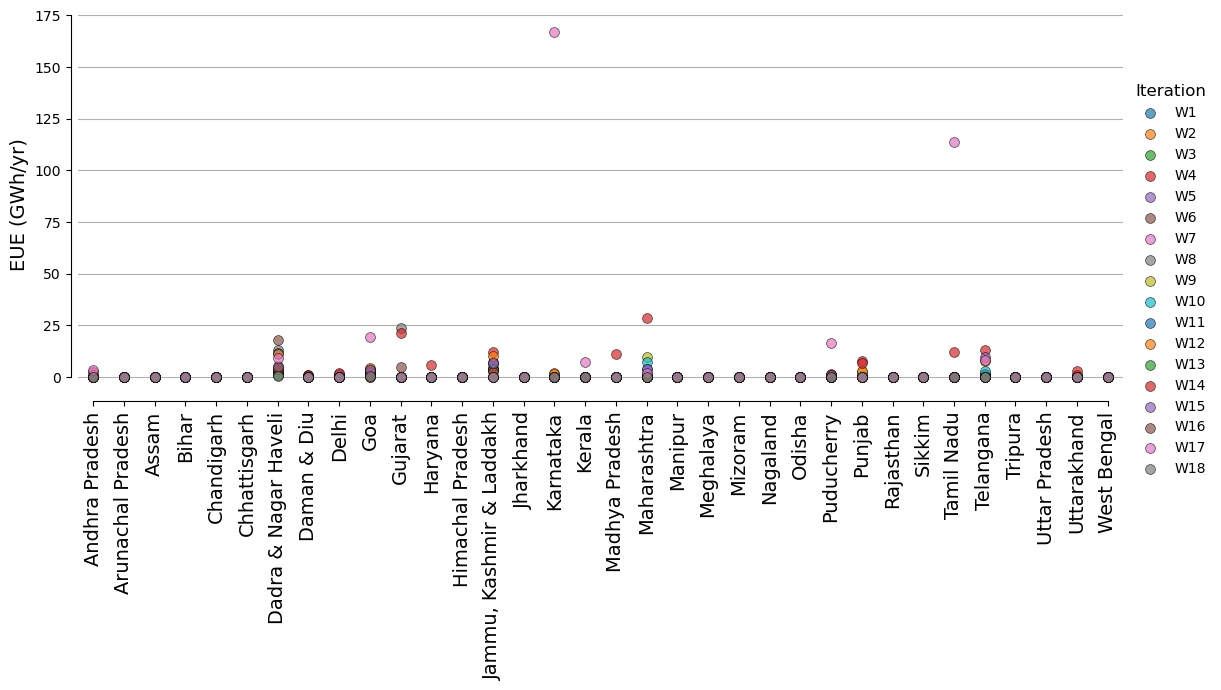

In [6]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    grouped_data_iterable = df.groupby(list(group_cols))
    
    # Define a key for sorting the groups to ensure W1, W2, ..., W10 sequence
    def sort_key_for_groups(group_item):
        group_key = group_item[0]  # This is 'vals' from groupby
        
        if not group_cols: # Should not happen if group_cols has a default
            return group_key

        # Handle single grouping column (vals is scalar)
        if not isinstance(group_key, tuple):
            if group_cols[0] == 'W':  # Sort numerically if 'W'
                try:
                    return int(group_key)
                except ValueError:
                    return group_key  # Fallback to string sort
            return group_key
        # Handle multiple grouping columns (vals is a tuple)
        else:
            if group_cols[0] == 'W': # Sort by 'W' numerically first
                try:
                    # Create a sort key: (int(W_val), other_vals...)
                    return (int(group_key[0]),) + group_key[1:]
                except (ValueError, TypeError):
                    return group_key  # Fallback
            return group_key # Default tuple sort

    sorted_groups = []
    if group_cols:
        try:
            sorted_groups = sorted(list(grouped_data_iterable), key=sort_key_for_groups)
        except Exception: # Fallback in case of unexpected error during sorting
            sorted_groups = list(grouped_data_iterable)
    else:
        sorted_groups = list(grouped_data_iterable)


    for vals, grp in sorted_groups:  # Iterate over sorted groups
        # Corrected label generation
        current_label = ""
        if isinstance(vals, tuple):  # Multiple grouping columns
            label_parts = []
            for i, col_name in enumerate(group_cols):
                label_parts.append(f"{col_name}{vals[i]}")
            current_label = "-".join(label_parts)
        else:  # Single grouping column
            current_label = f"{group_cols[0]}{vals}"
        
        x = grp['load_zone'].map(zone_pos)
        y = grp[metric]
        
        ax.scatter(x, y, 
                   label      = current_label, 
                   s          = 50, 
                   alpha      = 0.7, 
                   edgecolors = 'black', 
                   lw         = .5, 
                   zorder     = 10)

    # set the custom ticks & labels
    ax.set_xticks(list(zone_pos.values()))

    ax.set_ylabel(metric, fontsize = 14)

    # Add a legend
    ax.legend(
        title='Iteration',
        bbox_to_anchor=(1., .85), # Position legend outside
        loc='upper left',
        fontsize=10,
        title_fontsize=12, frameon=False,
    )
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=5, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)

    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=14) 
      

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'LOLH (hrs/yr)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

fig, ax = plt.subplots(figsize = (14, 7))
plot_metrics(ax, metrics_per_zone_df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend
plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'NENS (%)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, lol_events_df, metric = 'num_LOL_events')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()


### Alternative version with non-zero sample only

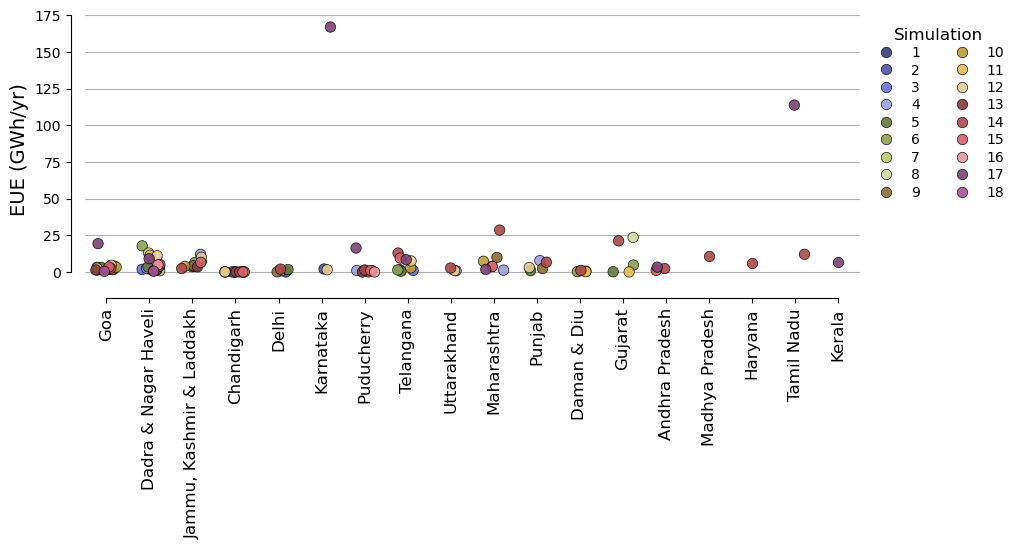

In [7]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.] 

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones    = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    
    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    x_ = np.arange(zones.shape[0])

    # for x, zone in zip(x_, zones):
    #     y = df.loc[df['load_zone'] == zone, metric].to_numpy()
    #     print(y.shape)


    ax.set_xticks(x_, list(zone_pos.values()))

    sns.stripplot(data      = df,
                  x         = "load_zone",
                  y         = metric, 
                  size      = "s", 
                  hue       = "iteration",
                  s         = 7.5,
                  alpha     = 0.9, 
                  edgecolor = 'k',
                  linewidth        = .5,
                  zorder    = 9, 
                  jitter    = .25,
                  palette   = "tab20b")

    # set the custom ticks & labels

    ax.set_ylabel(metric, fontsize = 14)
    ax.set_xlabel('', fontsize = 14)

    # Add a legend
    ax.legend(
        title = 'Simulation',
        bbox_to_anchor = (1., 1), # Position legend outside
        #loc='upper right',
        fontsize=10, 
        labelspacing = .25,
        title_fontsize=12, 
        frameon=False, ncol = 2)
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)
    
    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=12) 

df = metrics_per_zone_df.copy()
df['iteration'] = df['W']
df['iteration'] = df['iteration'].astype(int)
df              = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

fig, ax = plt.subplots(figsize = (10., 3.5))
plot_metrics(ax, df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
#plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend

plt.savefig(path_to_save_images + '/zone-level_EUE.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_EUE.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()



# Loss-of-load probability heatmap

In [8]:
df = df_load_.copy()

tau = 1.
df['lol'] = df['unserved_energy'] > tau

df = df[['timepoint', 'load_zone', 'lol']]

df = df.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop = False)
df = df.groupby(['timepoint']).agg({'lol': 'sum'}).reset_index(drop = False)

df['interval'] = df['timepoint'].apply(lambda x: int(str(x)[-2:]))
df['month']    = df['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

df = df[['month', 'interval', 'lol']]
df = df.groupby(['month', 'interval']).agg({'lol': 'sum'}).reset_index(drop = False)
print(df)

months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])
intervals_ = df['interval'].unique()
LOLP_      = np.zeros((months_.shape[0], intervals_.shape[0]))

for m, month in zip(range(months_.shape[0]), months_):
    for interval in intervals_:
        print(df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0], calendar.monthrange(2001, month)[1])
        LOLP_[m, interval - 1] = df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0]/(18*calendar.monthrange(2001, month)[1])

print(LOLP_.max(), LOLP_.min())

     month  interval  lol
0        1         1    0
1        1         2    0
2        1         3    0
3        1         4    0
4        1         5    0
..     ...       ...  ...
283     12        20    2
284     12        21    0
285     12        22    0
286     12        23    0
287     12        24    0

[288 rows x 3 columns]
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
1 31
2 31
2 31
0 31
1 31
1 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30

0.0 0.0 0.34050179211469533


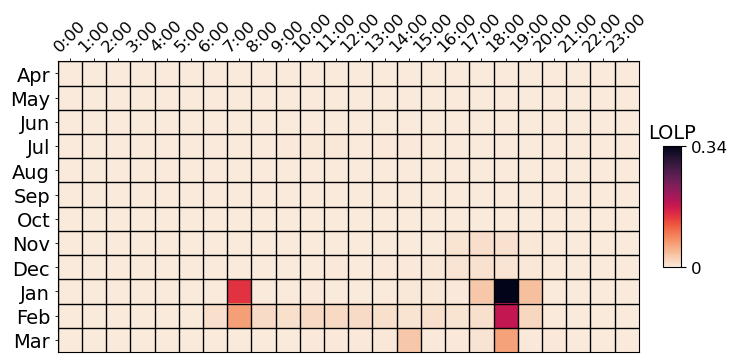

In [9]:
print(LOLP_[0, 18], LOLP_.min(), LOLP_.max())

fig, ax = plt.subplots(figsize = (7.5, 7.5))

month_    = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
interval_ = [ f'{interval}:00' for interval in np.arange(24, dtype = int)]

_cmap = sns.color_palette("rocket_r", as_cmap = True)

LOLP_p = LOLP_.copy()
LOLP_p[LOLP_ == 0.] = np.nan
ax.matshow(LOLP_, 
           cmap   = _cmap, 
           vmin   = 0., 
           extent = [0, 24, 12, 0])

ax.set_yticks(range(len(month_)), []*len(month_))
ax.set_xticks(range(len(interval_)), []*len(interval_))

ax.set_yticks(np.arange(len(month_), dtype = int) + 0.5, month_, 
              rotation = 0, 
              minor    = True, 
              size     = 14)

ax.set_xticks(np.arange(len(interval_), dtype = int) + 0.5, interval_,
              rotation = 45,
              minor    = True, 
              size     = 12)

ax.tick_params(which  = 'major', 
               bottom = False, 
               left   = False, 
               top    = False)

ax.tick_params(which  = 'minor', 
               bottom = False, 
               top    = True)

ax.grid(which     = 'major', 
        color     = 'k', 
        linestyle = '-', 
        linewidth = 1.)

cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                    cax = ax.inset_axes([25, 3.5, .75, 5], transform = ax.transData), 
                    orientation = 'vertical')

cbar.set_ticks([0, 1], labels = ['0', f'{np.round(LOLP_.max(), 2)}'], size = 12)
#cbar.ax.tick_params(length = 0)
cbar.ax.set_title('LOLP', rotation = 0, size = 14)

plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Loss-of-load events distribution

In [10]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'W', 'H', 'A', 'load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['iteration'] = df['W'] + df['H'] + df['A']
df = df[['iteration', 'timestamp', 'load_zone', 'unserved_energy']]

df = df.sort_values(by = ['iteration', 'timestamp', 'load_zone']).reset_index(drop = True)

# Load shedding greater than 1MW
tau = 1.

df_events_ = []
for load_zone in df['load_zone'].unique():
    print(load_zone)
    for iter in df['iteration'].unique():
        idx_ = (df['iteration'] == iter) & (df['load_zone'] == load_zone)
        if idx_.sum() > 0:
            run                = df.loc[idx_].copy()
            run['is_lol']      = run['unserved_energy'] > tau
            run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
            run['event_id']    = run['event_start'].cumsum()
            #print(load_zone, iter, (run['unserved_energy'] > 0).sum(), run['is_lol'].sum())

            df_event_              = pd.DataFrame(columns = ['hours', 'load_zone', 'iteration'])
            df_event_['hours']     = run[run['is_lol']].groupby('event_id').size().to_numpy()
            df_event_['load_zone'] = load_zone
            df_event_['iteration'] = iter

            df_events_.append(df_event_)

df_events_ = pd.concat(df_events_, axis = 0).reset_index(drop = True)
print(df_events_.head())

Andhra_Pradesh
Arunachal_Pradesh
Assam
Bhutan
Bihar
Chandigarh
Chhattisgarh
Dadra_Nagar_Haveli
Daman_Diu
Delhi
Goa
Gujarat
Haryana
Himachal_Pradesh
Jammu_Kashmir
Jharkhand
Karnataka
Kerala
Madhya_Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
Odisha
Puducherry
Punjab
Rajasthan
Sikkim
Tamil_Nadu
Telangana
Tripura
Uttar_Pradesh
Uttarakhand
West_Bengal
   hours       load_zone iteration
0      1  Andhra_Pradesh    141414
1      1  Andhra_Pradesh    151515
2      2  Andhra_Pradesh    171717
3      1  Andhra_Pradesh    171717
4      1      Chandigarh    101010


[ 1  2  3  4  5  7  8 14 13] 617
[433.  26.  17.   5.   1.   0.   1.   1.   0.   0.   0.   0.   1.   2.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
(14,) (15,)


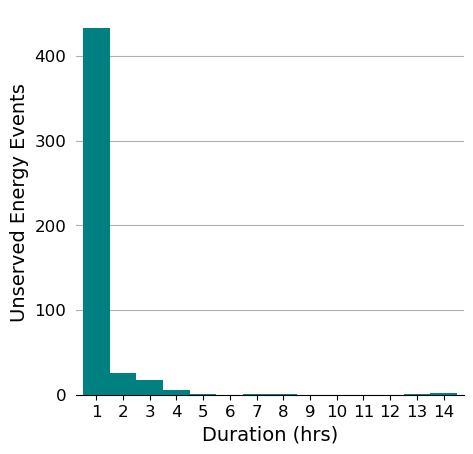

In [11]:
def _plot_LOLE_distribution(ax, df_events_):
    print(df_events_['hours'].unique(), df_events_['hours'].sum())

    (n, bins, patches) = ax.hist(df_events_['hours'], bins = 14, range = (1, 15), zorder = 5, color = 'teal')
    print(n)
    print(bins)
    print(n.shape, bins.shape)

    ax.set_xlabel('Duration (hrs)', fontsize = 14)
    ax.set_ylabel('Unserved Energy Events', fontsize = 14)
    ax.set_xticks(np.arange(0, 15, 1) + 1.5)
    ax.set_xticklabels(bins.astype(int))

    ax.set_xlim(bins.min() - .25, bins.max() + .25)
    ax.set_ylim(0, )

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)

    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.grid(axis = 'y', zorder = 0)

fig, ax = plt.subplots(figsize = (5, 5))

_plot_LOLE_distribution(ax, df_events_)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Unserved energy distribution

In [12]:
df_duration = df_load_.copy()
df_duration = df_duration[['timepoint','W','H','A','load_zone','unserved_energy','net_imports']]

df_unserved_energy = df_duration.copy()
df_unserved_energy= df_unserved_energy[['timepoint','W','H','A','load_zone','unserved_energy']]
# drop all the rows with unserved energy = 0
df_unserved_energy = df_unserved_energy[df_unserved_energy['unserved_energy'] > 0]
#sum unserved energy by timepoint for each load zone
df_unserved_energy = df_unserved_energy.groupby(['timepoint','W','H','A','load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# drop W,H,A columns
df_unserved_energy = df_unserved_energy.drop(columns=['W','H','A'])
#sum unserved energy for all load zones timepoint wise
df_unserved_energy = df_unserved_energy.groupby(['timepoint']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# arrane unserved energy in descending order
df_unserved_energy = df_unserved_energy.sort_values(by=['unserved_energy'], ascending=False).reset_index(drop = True)
print(df_unserved_energy.shape)

(203, 2)


In [13]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'load_zone', 'W', 'H', 'A']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['W'] = df['W'].astype(int)
df['H'] = df['H'].astype(int)
df['A'] = df['A'].astype(int)

df = df.sort_values(by = ['W', 'H', 'A', 'timestamp', 'load_zone'])

# Load shedding greater than 1MW
tau = 1

df = df.loc[df['unserved_energy'] > tau].reset_index(drop = True)
print(df.shape)


(617, 6)


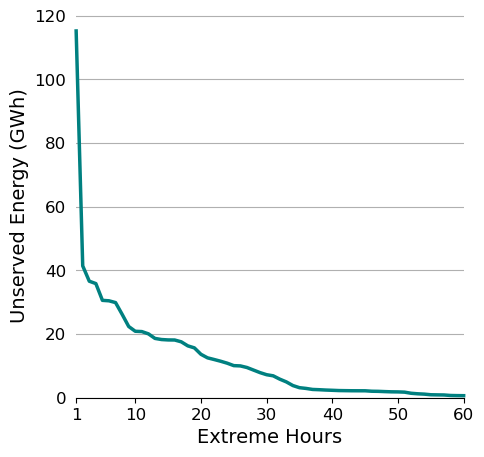

In [14]:
def _plot_unsrved_energy_dist(ax, df, cutoff = 50):
    x_ = range(1, len(df) + 1)
    y_ = df['unserved_energy']/1e3
    ax.plot(x_[:cutoff], y_[:cutoff], lw = 2.5, clip_on = False, color = 'teal')
    ax.set_xlabel('Extreme Hours', fontsize = 14)
    ax.set_ylabel('Unserved Energy (GWh)', fontsize = 14)
    # ax.title('Distribution of Unserved Energy')
    ax.set_xlim(1, cutoff)
    ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.set_xticks([1, 10, 20, 30, 40, 50, 60], [1, 10, 20, 30, 40, 50, 60])
    ax.grid(axis = 'y')

fig, ax = plt.subplots(figsize = (5, 5))

_plot_unsrved_energy_dist(ax, df_unserved_energy, cutoff = 60)

plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)
plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Net imports distribution

(3654,)


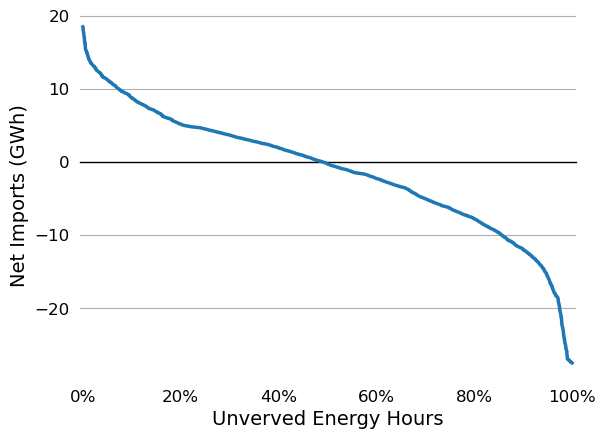

In [15]:
df = df_load_.copy()

# assume df_duration already has ['timepoint','load_zone','net_imports', …]
zone = 'Tamil_Nadu'  # ← replace with the zone you want

# Load shedding greater than 1MW
tau = 1

# This is at the national-level!
df = df.groupby(['timestamp', 'load_zone', 'W', 'H', 'A']).agg({'unserved_energy': 'sum', 'net_imports': 'sum'}).reset_index(drop = False)

df['W'] = df['W'].astype(int)
df['H'] = df['H'].astype(int)
df['A'] = df['A'].astype(int)

df = df.sort_values(by = ['W', 'H', 'A', 'timestamp', 'load_zone'])
df = df.loc[df['timestamp'].isin(df.loc[df['unserved_energy'] > tau, 'timestamp'].unique())].reset_index(drop = True)
df = df[df['load_zone'] == zone]

def plot_net_import_dist(ax, df):
    x_ = range(1, len(df) + 1)
    y_ = df['net_imports'].to_numpy()/1e3
    print(y_.shape)
    ax.plot(np.arange(y_.shape[0], dtype = int), np.sort(y_)[::-1], lw = 2.5, clip_on = True, zorder = 5)
    ax.set_xlabel('Unverved Energy Hours', fontsize = 14)
    ax.set_ylabel('Net Imports (GWh)', fontsize = 14)
    # ax.title('Distribution of Unserved Energy')
    ax.set_xlim(-25, y_.shape[0] + 25)
    ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left','bottom']].set_visible(False)
    ax.set_xticks(np.linspace(0, y_.shape[0], 6), [f'{i*20}%' for i in np.arange(6, dtype = int)])
    ax.axhline(0, linewidth = 1.,
                  linestyle = '-',
                  color     = 'k',
                  clip_on   = False, 
                  zorder    = 4)
    
    ax.grid(axis   = 'y', 
            zorder = 1)

fig = plt.figure()
ax  = fig.add_subplot(111)

plot_net_import_dist(ax, df)

In [16]:
# assume df_duration already has ['timepoint','load_zone','net_imports', …]
zone = 'Karnataka'  # ← replace with the zone you want

# 1. filter out zeros and unwanted columns
df_zone = (df_duration.loc[df_duration['net_imports'] != 0, ['timepoint','load_zone','net_imports']])

# 2. keep only your zone
df_zone = df_zone[df_zone['load_zone'] == zone]

# 3. group by timepoint and sum
df_zone_import = (df_zone.groupby('timepoint', as_index=False)['net_imports'].sum())

# 4. sort if you like
df_zone_import = df_zone_import.sort_values('net_imports', ascending=False)

print(df_zone_import.head())

       timepoint    net_imports
7630  2041021223  306267.232082
7582  2041021023  300180.531043
7750  2041021723  294933.909671
8062  2041030223  292925.035558
6766  2041010723  291851.189006


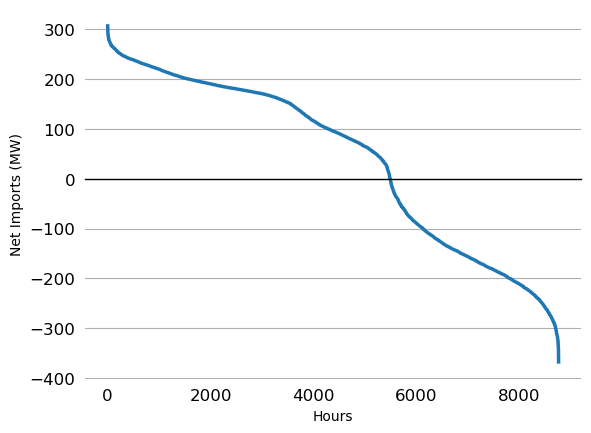

In [17]:
def plot_net_import_dist(ax, df):
    x_ = range(1, len(df) + 1)
    y_ = df['net_imports']/1e3

    ax.plot(x_, y_, lw = 2.5)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Net Imports (MW)')
    # ax.title('Distribution of Unserved Energy')
    # ax.set_xlim(0.9,50)
    # ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left','bottom']].set_visible(False)
    # ax.set_xticks([1, 10, 20, 30, 40, 50], [1, 10, 20, 30, 40, 50])
    ax.grid(axis = 'y')
    ax.axhline(0, linewidth = 1.,
                  linestyle = '-',
                  color     = 'k',
                  clip_on   = False)

fig = plt.figure()
ax = fig.add_subplot(111)

plot_net_import_dist(ax, df_zone_import)

# Load and processing project timepoints

In [18]:
# Load and processing project timepoints
def _processing_project_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)

                df_ = df_[['timepoint', 
                           'technology', 
                           'load_zone', 
                           'power_mw',
                           'capacity_mw',
                           'starting_energy_mwh', 
                           'charge_mw', 
                           'discharge_mw', 
                           'total_curtailment_mw',
                           'availability_derate']] # availability_derate

                df_ = df_.groupby(['timepoint',
                                   'technology', 
                                   'load_zone']).agg({'power_mw': 'sum',
                                                      'total_curtailment_mw': 'sum',
                                                      'starting_energy_mwh': 'sum',
                                                      'charge_mw': 'sum',
                                                      'discharge_mw': 'sum',
                                                      'capacity_mw' : 'sum',
                                                      'availability_derate': 'mean'}).reset_index(drop = False)

                df_ = df_.rename(columns = {'total_curtailment_mw': 'curtailment_mw',
                                            'starting_energy_mwh': 'energy_mwh',
                                            'availability_derate': 'availability_factor'})

                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group project timepoints by technology
def _group_technology_in_project_timepoints(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['timepoint',
                        'technology', 
                        'load_zone',
                        'W','H','A']).agg({'power_mw': 'sum',
                                           'capacity_mw' : 'sum',
                                           'curtailment_mw': 'sum',
                                           'energy_mwh': 'sum',
                                           'charge_mw': 'sum',
                                           'discharge_mw': 'sum',
                                           'availability_factor': 'mean'}).reset_index(drop = False)

# Load, process and group project timepoints
df_dispatch_ = _processing_project_timepoints(scenarios_)
df_dispatch_ = _group_technology_in_project_timepoints(df_dispatch_, tech_labels_)
print(df_dispatch_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
    timepoint technology       load_zone   W   H   A     power_mw  \
0  2040040101    Battery  Andhra_Pradesh   1   1   1     0.000000   
1  2040040101    Battery  Andhra_Pradesh  10  10  10 -3136.53

#import transmission

In [19]:
# Load and process transmission_timepoint.csv
def _processing_transmission_timepoints(scenarios_):
    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_timepoint for {scenario}")

                df_ = pd.read_csv(os.path.join(dirpath, 'transmission_timepoint.csv'), low_memory=False)
                df_ = df_[[
                    'timepoint',
                    'load_zone_from',
                    'load_zone_to',
                    'transmission_flow_mw',
                    'transmission_losses_lz_from',
                    'transmission_losses_lz_to'
                ]]
                df_ = df_.groupby(
                    ['timepoint', 'load_zone_from', 'load_zone_to']
                ).agg({
                    'transmission_flow_mw': 'sum',
                    'transmission_losses_lz_from': 'sum',
                    'transmission_losses_lz_to': 'sum'
                }).reset_index()

                # Make flow non-negative (use absolute values)
                df_['transmission_flow_mw'] = df_['transmission_flow_mw'].abs()

                # Add iteration descriptors
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop=True)


# Load and process transmission_period.csv
def _processing_transmission_period(scenarios_):
    dfz_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_period for {scenario}")

                df_2 = pd.read_csv(os.path.join(dirpath, 'transmission_period.csv'), low_memory=False)
                df_2 = df_2[['load_zone_from', 'load_zone_to', 'max_mw']]
                df_2 = df_2.groupby(
                    ['load_zone_from', 'load_zone_to']
                ).agg({'max_mw': 'sum'}).reset_index()

                # Add iteration descriptors
                df_2['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_2['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_2['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfz_.append(df_2)

    return pd.concat(dfz_).reset_index(drop=True)


def add_max_mw_to_timepoints(df_timepoints, df_period):
    """
    Left-join max_mw onto transmission timepoints using
    (load_zone_from, load_zone_to, W, H, A) as keys.
    """
    keys = ['load_zone_from', 'load_zone_to', 'W', 'H', 'A']

    # Ensure period table is unique per key; if not, sum max_mw across duplicates
    df_period_u = (
        df_period
        .groupby(keys, as_index=False, dropna=False)['max_mw']
        .sum()
    )

    # Left-join to keep all timepoints
    merged = df_timepoints.merge(
        df_period_u, on=keys, how='left', validate='many_to_one'
    )

    # Optional: if any routes didn’t find a match, set max_mw to 0 (or keep NaN)
    merged['max_mw'] = merged['max_mw'].fillna(0)

    return merged


# --- Run pipeline ---
df_transmission_timepoints = _processing_transmission_timepoints(scenarios_)
df_transmission_period    = _processing_transmission_period(scenarios_)
df_transmission_timepoints = add_max_mw_to_timepoints(
    df_transmission_timepoints, df_transmission_period
)

# Build zone-level table: sum absolute flow and max_mw of every line incident to a zone
_cols_ = ['timepoint', 'W', 'H', 'A', 'transmission_flow_mw', 'max_mw']

df_from = (
    df_transmission_timepoints[_cols_ + ['load_zone_from']]
    .rename(columns={'load_zone_from': 'load_zone'})
)

df_to = (
    df_transmission_timepoints[_cols_ + ['load_zone_to']]
    .rename(columns={'load_zone_to': 'load_zone'})
)

df_transmission_timepoints_zone = (
    pd.concat([df_from, df_to], ignore_index=True)
      .groupby(['timepoint', 'W', 'H', 'A', 'load_zone'], as_index=False)
      .agg({
          'transmission_flow_mw': 'sum',
          'max_mw': 'sum'
      })
      .rename(columns={
          'transmission_flow_mw': 'zone_transmission_flow_mw',
          'max_mw': 'zone_max_mw'
      })
)

# Add tx_cap_factor
df_transmission_timepoints_zone['tx_cap_factor'] = (
    df_transmission_timepoints_zone['zone_transmission_flow_mw'] /
    df_transmission_timepoints_zone['zone_max_mw'].replace({0: pd.NA})
)

print(df_transmission_timepoints.head())
print(df_transmission_timepoints_zone.head())

Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_1
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_2
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_3
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_4
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_5
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_6
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_7
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_8
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_9
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_10
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_11
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_12
Processing tr

Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_14
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_15
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_16
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_17
Processing transmission_timepoint for capex_pier_prm_108_cc_90_hardovergen_2040_18
Processing transmission_period for capex_pier_prm_108_cc_90_hardovergen_2040_1
Processing transmission_period for capex_pier_prm_108_cc_90_hardovergen_2040_2
Processing transmission_period for capex_pier_prm_108_cc_90_hardovergen_2040_3
Processing transmission_period for capex_pier_prm_108_cc_90_hardovergen_2040_4
Processing transmission_period for capex_pier_prm_108_cc_90_hardovergen_2040_5
Processing transmission_period for capex_pier_prm_108_cc_90_hardovergen_2040_6
Processing transmission_period for capex_pier_prm_108_cc_90_hardovergen_2040_7
Processing transmission_period f

In [20]:
# Add timestamp to df_transmission_timepoints
tp = df_transmission_timepoints['timepoint'].astype(str)

# First 8 chars are YYYYMMDD, rest are hour index
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  # 1–24

df_transmission_timepoints['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)

# Reorder so timestamp is the first column
cols = df_transmission_timepoints.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_transmission_timepoints = df_transmission_timepoints[cols]


In [21]:
# add tiemstamp to df_dispatch_
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_dispatch_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_dispatch_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_dispatch_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_dispatch_ = df_dispatch_[cols]

#Calculation of Renewable Energy Drought

In [22]:
# Filter for Wind and Solar technologies
df_wind = df_dispatch_[df_dispatch_['technology'] == 'Wind']
df_solar = df_dispatch_[df_dispatch_['technology'] == 'Solar']

# Group and sum Wind power and capacity by load_zone and timestamp
wind_grouped = df_wind.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Group and sum Solar power and capacity by load_zone and timestamp
solar_grouped = df_solar.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Merge the grouped Wind and Solar DataFrames
merged_df = pd.merge(
    wind_grouped, 
    solar_grouped, 
    on=['load_zone', 'timestamp','W','H','A'], 
    how='outer', 
    suffixes=('_wind', '_solar')
)

# Sum the Wind and Solar power and capacity into new columns
merged_df['total_renewable_mwh'] = merged_df['power_mw_wind'] + merged_df['power_mw_solar']
merged_df['total_renewable_capacity_mw'] = merged_df['capacity_mw_wind'] + merged_df['capacity_mw_solar']

# Select the final columns - no need for additional grouping
renewable_dispatch = merged_df[['load_zone', 'timestamp', 'W','H','A','total_renewable_mwh', 'total_renewable_capacity_mw']]

# net_cf=renewable_dispatch.copy()
# net_cf['capacity_factor'] = net_cf['total_renewable_mwh'] / net_cf['total_renewable_capacity_mw']

# # filter only the solar hours i.e. 9 AM to 5 PM
# net_cf = net_cf[(net_cf['timestamp'].dt.hour >= 9) & (net_cf['timestamp'].dt.hour < 17)]

# # keep the values whose capacity factor is below 0.025
# net_cf = net_cf[net_cf['capacity_factor'] < 0.025]


# calculation by average Plant load factor method

In [23]:

plf_df = renewable_dispatch.copy()

window_days = 2  

# Convert timestamp to plain date (YYYY-MM-DD)
plf_df['date'] = plf_df['timestamp'].dt.date  

# Aggregate to daily total generation and capacity
daily_df = (
    plf_df.groupby(['load_zone','W','H','A','date'], as_index=False)
          [['total_renewable_mwh','total_renewable_capacity_mw']].sum()
)

# Daily PLF
daily_df['daily_plf'] = (
    daily_df['total_renewable_mwh'] / daily_df['total_renewable_capacity_mw']
)

# Rolling PLF over 2 days
daily_df['plf'] = (
    daily_df.groupby(['load_zone','W','H','A'])['daily_plf']
            .transform(lambda x: x.rolling(window=window_days, min_periods=1).mean())
)

# Final dataframe (date-only, no hh:mm)
plf_df = daily_df.drop(columns=['daily_plf'])


In [24]:
# df_dispatch_ must have: timepoint, technology, load_zone, power_mw, capacity_mw, W, H, A

# 1) Correct timestamp (timepoints encoded as YYYYMMDDHH with HH=1..24)
tp = df_dispatch_['timepoint'].astype(str)
dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
hours = tp.str[8:].astype(int)  # 1..24
df_dispatch_ = df_dispatch_.copy()
df_dispatch_['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')  # <-- fix at source

# 2) Wind & Solar hourly (sum if multiples)
keys = ['load_zone','timestamp','W','H','A']
cols = keys + ['power_mw','capacity_mw','technology']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']), cols].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

# 3) Merge wind+solar, fill zeros BEFORE summing
merged = (pd.merge(wind, solar, on=keys, how='outer')
            .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                     'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))

merged['total_power_mw']    = merged['power_mw_wind']    + merged['power_mw_solar']
merged['total_capacity_mw'] = merged['capacity_mw_wind'] + merged['capacity_mw_solar']

# 4) Day assignment (NO extra 1h shift now that timestamp is fixed)
merged['date'] = merged['timestamp'].dt.normalize()

# 5) Daily PLF and 48h (2-day) rolling PLF
daily = (merged.groupby(['load_zone','W','H','A','date'], as_index=False)
         .agg(energy_mwh_day=('total_power_mw','sum'),
              cap_hour_sum_day=('total_capacity_mw','sum')))

daily['plf_day'] = np.where(
    daily['cap_hour_sum_day'] > 0,
    daily['energy_mwh_day'] / daily['cap_hour_sum_day'],
    np.nan
)

window_days = 2  # 48 hours
daily = daily.sort_values(['load_zone','W','H','A','date'])
daily['plf'] = (daily.groupby(['load_zone','W','H','A'])['plf_day']
                .transform(lambda s: s.rolling(window=window_days, min_periods=1).mean()))

# 6) Final day-wise PLF dataframe + flag
plf_df = daily[['load_zone','W','H','A','date','plf']].copy()
plf_threshold = 0.025
plf_df['low_plf_flag'] = np.where(plf_df['plf'].notna() & (plf_df['plf'] < plf_threshold), 1, 0).astype('int8')

# 7) Enforce fiscal year window: Apr 1 → Mar 31 (change fy as needed)
fy = 2040  # FY 2040–41
fy_start = pd.Timestamp(f"{fy}-04-01")
fy_end   = pd.Timestamp(f"{fy+1}-03-31")

plf_df = plf_df[(plf_df['date'] >= fy_start) & (plf_df['date'] <= fy_end)].copy()
plf_df = plf_df.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)


#Calculation of top net demand days 

In [25]:
TOP_K = 5
FY = None           # e.g., 2040 for FY 2040–41 (Apr 1 → Mar 31), or None to skip

# Helper: correct timestamp from timepoint with hours 1..24
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

# 1) Ensure aligned timestamps on load & dispatch
df_load_ = df_load_.copy()
if 'timestamp' not in df_load_.columns:
    df_load_['timestamp'] = _timestamp_from_timepoint(df_load_)
df_load_['date'] = df_load_['timestamp'].dt.normalize()

df_dispatch_ = df_dispatch_.copy()
if 'timestamp' not in df_dispatch_.columns:
    df_dispatch_['timestamp'] = _timestamp_from_timepoint(df_dispatch_)

# 2) Build hourly RE total (Wind + Solar) per zone/W/H/A/timestamp
keys = ['load_zone','timestamp','W','H','A']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']),
                      keys + ['power_mw','capacity_mw','technology']].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

re_merged = (pd.merge(wind, solar, on=keys, how='outer')
               .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                        'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))
re_merged['total_re_mw'] = re_merged['power_mw_wind'] + re_merged['power_mw_solar']

# 3) Build netload_df = static_load − total_re_mw (hourly, PER ZONE)
netload_df = pd.merge(
    df_load_[keys + ['static_load']],
    re_merged[keys + ['total_re_mw']],
    on=keys, how='left'
).fillna({'total_re_mw': 0.0})

netload_df['net_load_mw'] = netload_df['static_load'] - netload_df['total_re_mw']
netload_df['date'] = netload_df['timestamp'].dt.normalize()

# (optional) restrict to fiscal year Apr 1 → Mar 31
if FY is not None:
    fy_start = pd.Timestamp(f"{FY}-04-01")
    fy_end   = pd.Timestamp(f"{FY+1}-03-31")
    netload_df = netload_df[(netload_df['date'] >= fy_start) & (netload_df['date'] <= fy_end)].copy()

# 4) Per-zone hourly net load (sum only in case of duplicates)
zone_hourly = (netload_df.groupby(['load_zone','W','H','A','timestamp'], as_index=False)['net_load_mw'].sum())
zone_hourly['date'] = zone_hourly['timestamp'].dt.normalize()

# 5) Per-zone DAILY PEAK net load (MW)
daily_peak_zone = (
    zone_hourly.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
               .max()
               .rename(columns={'net_load_mw':'daily_peak_net_load_mw'})
)

# 6) Top 5 days per (load_zone, W, H, A)
top5_zone_netload_days = (
    daily_peak_zone.sort_values(['load_zone','W','H','A','daily_peak_net_load_mw'],
                                ascending=[True, True, True, True, False])
                    .groupby(['load_zone','W','H','A'])
                    .head(TOP_K)
                    .reset_index(drop=True)
)

# (nice to have) rank within each zone+iteration
top5_zone_netload_days['rank'] = (
    top5_zone_netload_days.groupby(['load_zone','W','H','A'])['daily_peak_net_load_mw']
                          .rank(ascending=False, method='first').astype(int)
)

# make date a pure date object (no hh:mm:ss)
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# - netload_df: hourly net load by zone/W/H/A
# - top5_zone_netload_days: top 5 daily-peak net-load days for each (load_zone, W, H, A)


In [26]:
# Merging netyload with plf
# Make dates comparable (no hh:mm)
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# Align dtypes on join keys
for c in ['load_zone','W','H','A']:
    plf_df[c] = plf_df[c].astype(str)
    top5_zone_netload_days[c] = top5_zone_netload_days[c].astype(str)

# Keys
keys = ['load_zone','W','H','A','date']

# Build the flag from the top-5 table
top5_keys = top5_zone_netload_days[keys].drop_duplicates().assign(net_load=1)

# Merge into plf_df; fill others as 0
plf_df = (
    plf_df.drop(columns=['net_load'], errors='ignore')
          .merge(top5_keys, on=keys, how='left')
)
plf_df['net_load'] = plf_df['net_load'].fillna(0).astype('int8')

In [27]:
# Adding unserved energy to plf
# --- make dates comparable (no hh:mm) ---
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date

df_ls = df_load_.copy()

# If df_load_ doesn't already have the fixed timestamp (1..24 → hours-1), build it:
if 'timestamp' not in df_ls.columns:
    tp = df_ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    df_ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

df_ls['date'] = df_ls['timestamp'].dt.date

# --- build daily presence flag for load shedding (>0) per zone & W,H,A ---
keys = ['load_zone','W','H','A','date']
ls_presence = (
    df_ls.loc[df_ls['unserved_energy'] > 0, keys]
         .drop_duplicates()
         .assign(load_shedding=1)
)

# align dtypes on join keys (avoid int/str mismatches)
for k in ['load_zone','W','H','A']:
    plf_df[k]      = plf_df[k].astype(str)
    ls_presence[k] = ls_presence[k].astype(str)

# --- merge into plf_df; fill others as 0 ---
plf_df = (
    plf_df.drop(columns=['load_shedding'], errors='ignore')
          .merge(ls_presence, on=keys, how='left')
)
plf_df['load_shedding'] = plf_df['load_shedding'].fillna(0).astype('int8')


# Dataframe with weather indices and impact on LOL

In [28]:

# ---- keys we’ll reuse ----
keys4 = ['load_zone','W','H','A']

# start from plf_df
final_df = plf_df.copy()
final_df['date'] = pd.to_datetime(final_df['date']).dt.normalize()

# =========================
# 1) Expected EUE per (zone, W, H, A) and daily load shedding
# =========================
ls = df_load_.copy()

# ensure a correct hourly timestamp (1..24 encoded hours → hours-1)
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

ls['date'] = ls['timestamp'].dt.normalize()

# (optional but helps keep “one year” aligned with plf_df’s span)
ls = ls.merge(final_df[keys4].drop_duplicates(), on=keys4, how='inner')
ls = ls[(ls['date'] >= final_df['date'].min()) & (ls['date'] <= final_df['date'].max())]

# daily unserved energy per zone & iteration (assumes hourly steps → sum(MW)=MWh)
ls_daily = (
    ls.groupby(keys4 + ['date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy': 'load_shedding_mwh'})
)

# expected EUE over the year window (per zone & iteration)
expected_eue = (
    ls_daily.groupby(keys4, as_index=False)['load_shedding_mwh']
            .sum()
            .rename(columns={'load_shedding_mwh':'expected_eue_mwh'})
)

# merge into final_df
final_df = final_df.merge(ls_daily, on=keys4 + ['date'], how='left')
final_df['load_shedding_mwh'] = final_df['load_shedding_mwh'].fillna(0)

final_df = final_df.merge(expected_eue, on=keys4, how='left')
final_df['expected_eue_mwh'] = final_df['expected_eue_mwh'].fillna(0)

# ratio: daily load shedding as a share of expected EUE
final_df['load_shedding_eue'] = np.where(
    final_df['expected_eue_mwh'] > 0,
    final_df['load_shedding_mwh'] / final_df['expected_eue_mwh'],
    np.nan
)

# =========================
# 2) Ratio to maximum of top net load
# =========================
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()

# daily PEAK net load (MW)
nl_daily_peak = (
    nl.groupby(keys4 + ['date'], as_index=False)['net_load_mw']
      .max()
      .rename(columns={'net_load_mw':'daily_peak_netload_mw'})
)

# max of the top-5 daily peaks per (zone, W, H, A)
top5_max = (
    nl_daily_peak.sort_values(keys4 + ['daily_peak_netload_mw'],
                              ascending=[True, True, True, True, False])
                 .groupby(keys4, as_index=False).head(5)
                 .groupby(keys4, as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'})
)

# merge denom and compute ratio
final_df = final_df.merge(top5_max, on=keys4, how='left')
final_df['load_shedding_top_net_load'] = np.where(
    final_df['top_netload_max_mw'] > 0,
    final_df['load_shedding_mwh'] / final_df['top_netload_max_mw'],
    np.nan
)

# date as plain date (no time)
final_df['date'] = final_df['date'].dt.date


# Heatmap of Renewable Energy Drought days

/tmp/ipykernel_4143588/1768223499.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: 

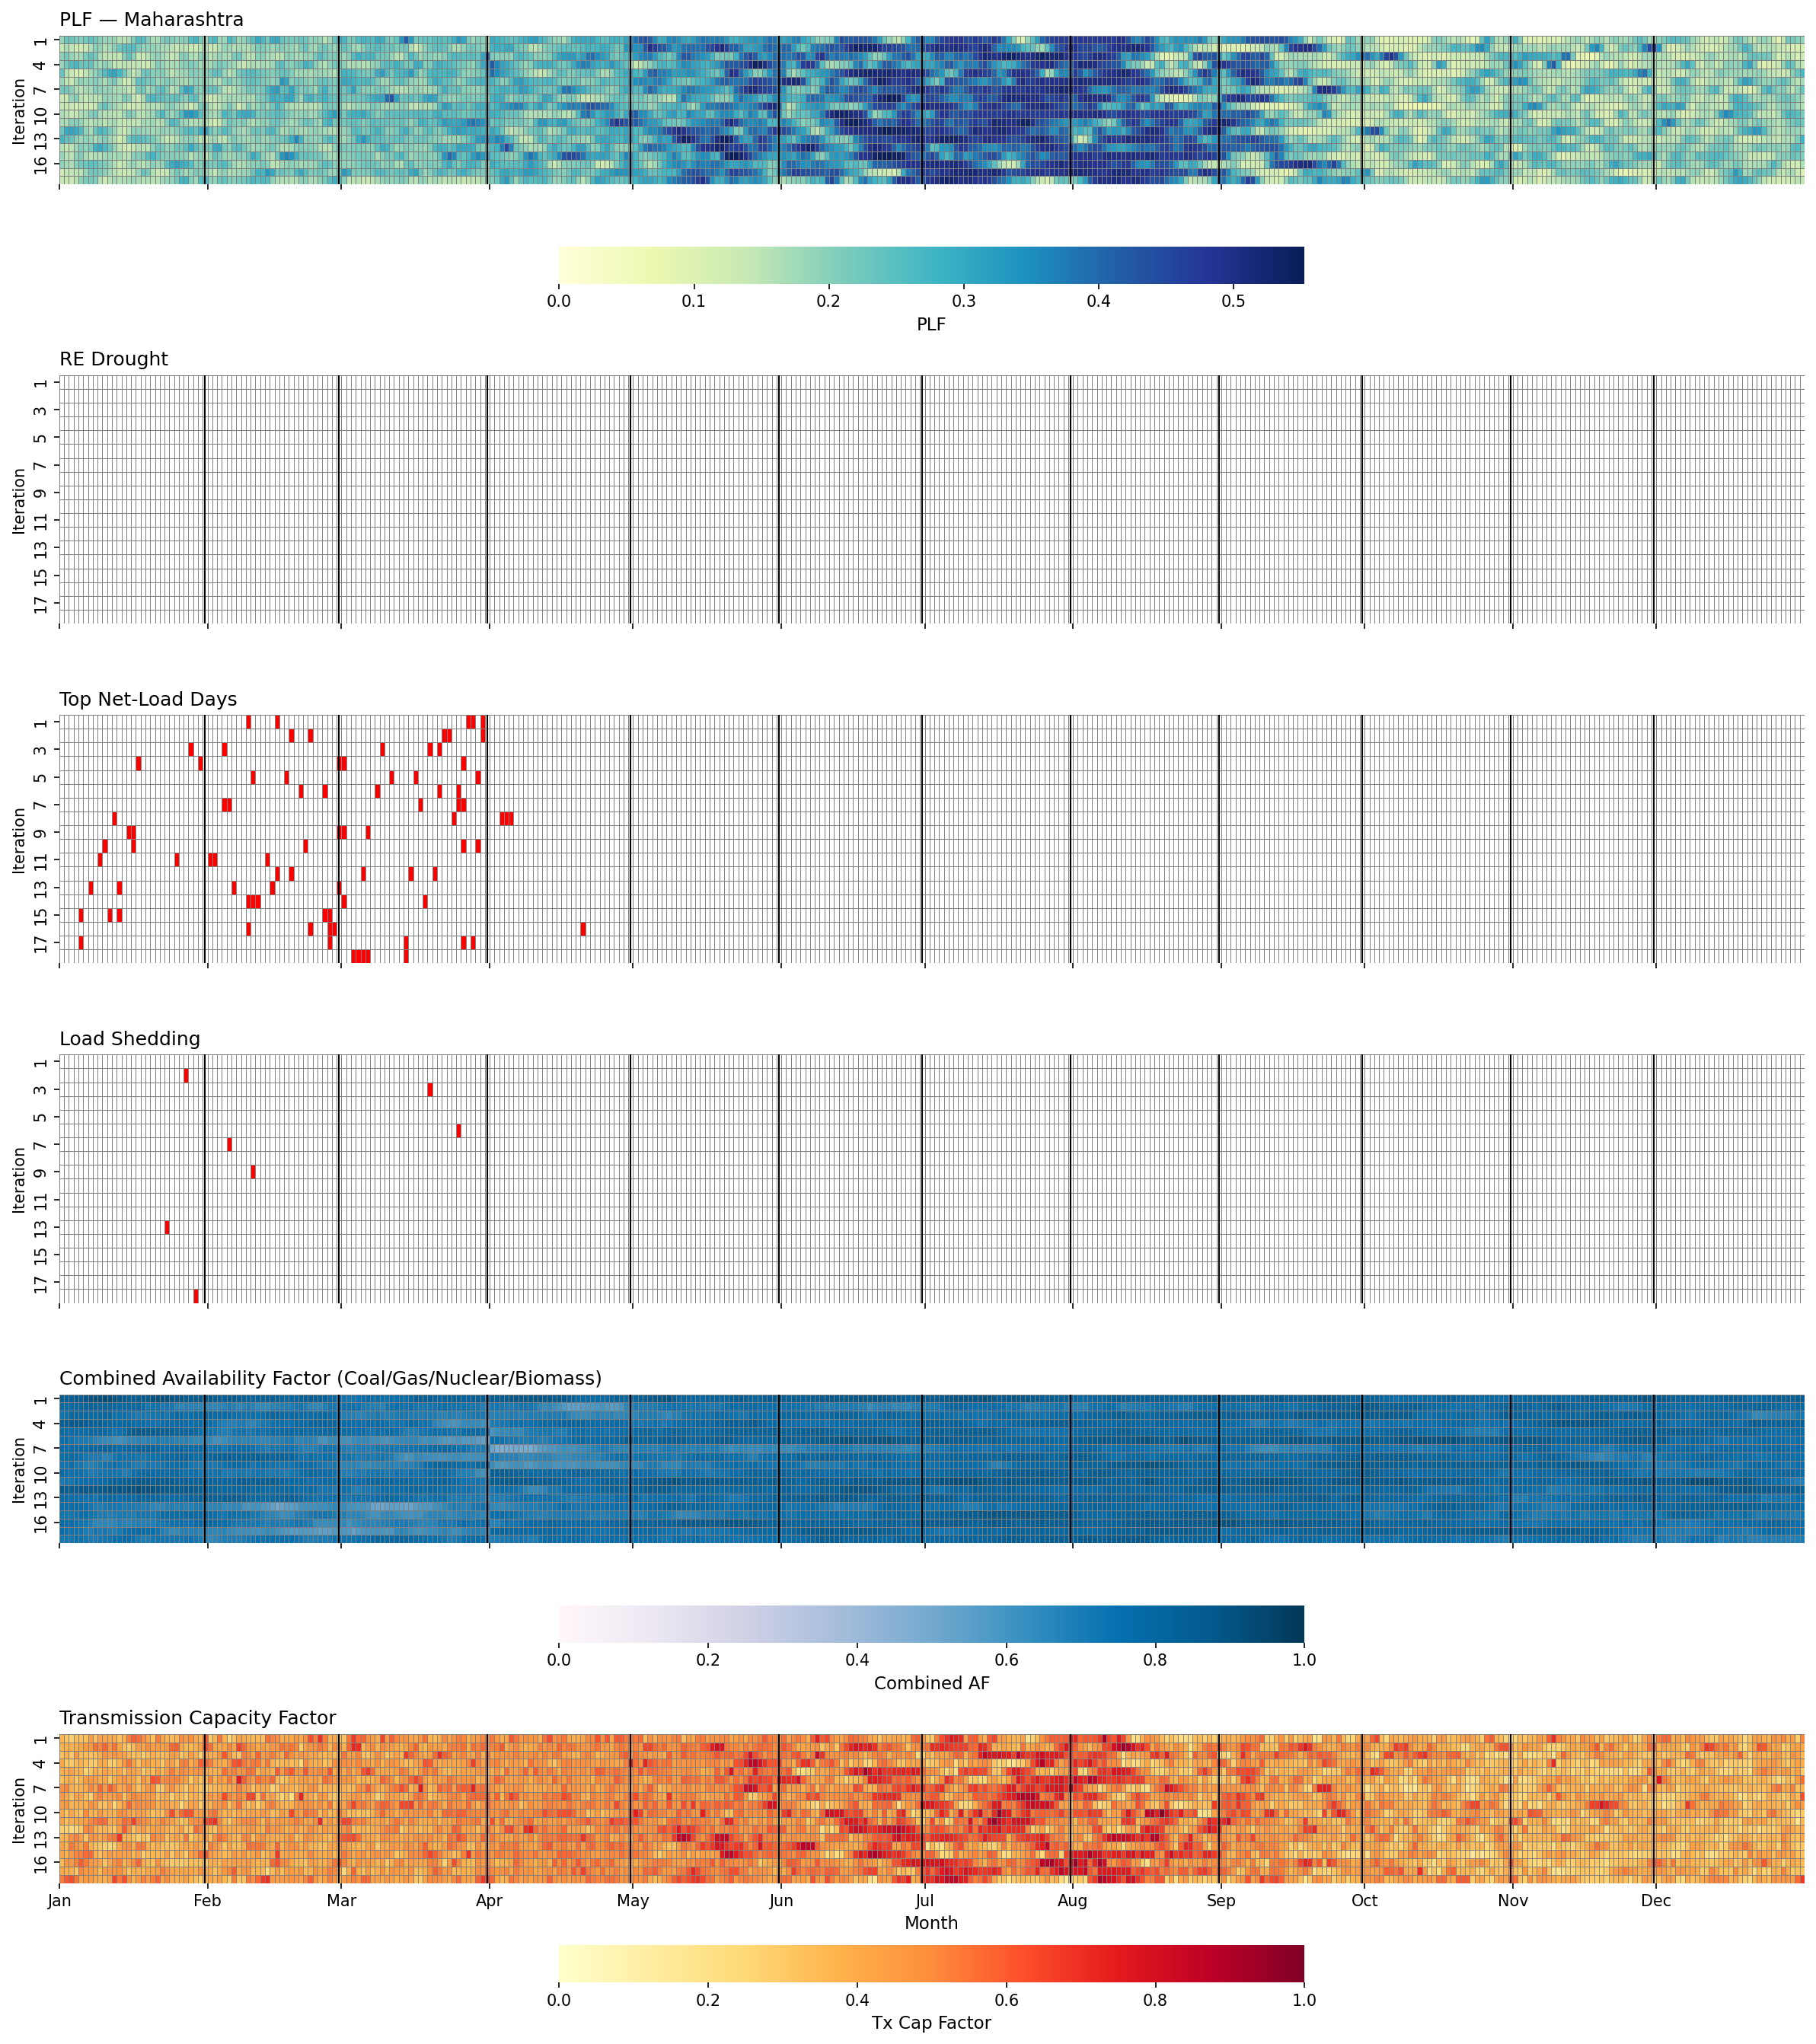

In [29]:


selected_zone = "Maharashtra"  # ← change here to switch zones
freq = "D"               # "D" daily; e.g., "W-MON" for weekly display
plt.rcParams.update({"font.family": "Arial", "font.size": 10})


def build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq="D"):
    # ---- Ensure df_dispatch_ has correct timestamp (1..24 → hours-1) ----
    if 'timestamp' not in df_dispatch_.columns:
        tp    = df_dispatch_['timepoint'].astype(str)
        dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
        hours = tp.str[8:].astype(int)
        df_dispatch_ = df_dispatch_.copy()
        df_dispatch_['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')

    # ---- PLF-side (zone slice) ----
    z = plf_df.loc[
        plf_df['load_zone'] == selected_zone,
        ['W','H','A','date','plf','low_plf_flag','net_load','load_shedding']
    ].copy()
    if z.empty:
        raise ValueError(f"No PLF rows for '{selected_zone}'. "
                         f"Available: {sorted(plf_df['load_zone'].unique())}")
    z['date'] = pd.to_datetime(z['date']).dt.normalize()
    z[['W','H','A']] = z[['W','H','A']].astype(str)
    it_plf = z[['W','H','A']].drop_duplicates()

    # ---- TX-side (zone slice) ----
    tx = df_transmission_timepoints_zone.loc[
        df_transmission_timepoints_zone['load_zone'] == selected_zone,
        ['timepoint','W','H','A','load_zone','tx_cap_factor']
    ].copy()
    if tx.empty:
        tx_daily = pd.DataFrame(columns=['W','H','A','date','tx_cap_factor'])
        it_tx = pd.DataFrame(columns=['W','H','A'])
    else:
        if 'timestamp' not in tx.columns:
            tp    = tx['timepoint'].astype(str)
            dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
            hours = tp.str[8:].astype(int)
            tx['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')
        tx['date'] = tx['timestamp'].dt.normalize()
        tx[['W','H','A']] = tx[['W','H','A']].astype(str)
        tx_daily = tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].mean()
        it_tx = tx_daily[['W','H','A']].drop_duplicates()

    # ---- Combined Availability Factor (Coal/Gas/CCGT/CT/Nuclear/Biomass) ----
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    disp = df_dispatch_.loc[
        (df_dispatch_['load_zone'] == selected_zone) &
        (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
        ['load_zone','timestamp','W','H','A','technology','power_mw','capacity_mw'] +
        ([c for c in ['availability_derate','availability_factor'] if c in df_dispatch_.columns])
    ].copy()
    disp['date'] = disp['timestamp'].dt.normalize()
    disp[['W','H','A']] = disp[['W','H','A']].astype(str)

    if 'availability_derate' in disp.columns:
        disp['af_src'] = disp['availability_derate']
    elif 'availability_factor' in disp.columns:
        disp['af_src'] = disp['availability_factor']
    else:
        disp['af_src'] = np.where(
            disp['capacity_mw'] > 0,
            (disp['power_mw'] / disp['capacity_mw']).clip(0, 1),
            np.nan
        )

    keys_ts = ['load_zone','timestamp','W','H','A']
    caf_ts = (disp.assign(weighted=disp['capacity_mw'] * disp['af_src'])
                    .groupby(keys_ts, as_index=False)
                    .agg(caf_num=('weighted','sum'),
                         caf_den=('capacity_mw','sum')))
    caf_ts['caf'] = np.where(caf_ts['caf_den'] > 0, caf_ts['caf_num'] / caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    caf_daily = caf_ts.groupby(['W','H','A','date'], as_index=False)['caf'].mean()
    it_caf = caf_daily[['W','H','A']].drop_duplicates()

    # ---- Master iteration list = union(PLF, TX, CAF) ----
    it_master = (pd.concat([it_plf, it_tx, it_caf], ignore_index=True)
                   .drop_duplicates()
                   .sort_values(['W','H','A'])
                   .reset_index(drop=True))
    it_master['iteration'] = np.arange(1, len(it_master) + 1)

    # Attach iteration ids
    z = z.merge(it_master, on=['W','H','A'], how='left')
    caf_daily = caf_daily.merge(it_master, on=['W','H','A'], how='left')

    # ---- Pivot PLF matrices and resample ----
    heat = (z.pivot_table(index='iteration', columns='date', values='plf',          aggfunc='mean')
              .T.resample(freq).mean().T)
    flag = (z.pivot_table(index='iteration', columns='date', values='low_plf_flag', aggfunc='max' )
              .T.resample(freq).max().T)
    net  = (z.pivot_table(index='iteration', columns='date', values='net_load',     aggfunc='max' )
              .T.resample(freq).max().T)
    shed = (z.pivot_table(index='iteration', columns='date', values='load_shedding',aggfunc='max' )
              .T.resample(freq).max().T)

    # Full date axis across PLF, TX, CAF
    plf_cols = heat.columns if heat.shape[1] else pd.Index([])
    tx_cols  = pd.to_datetime(tx_daily['date']).sort_values().unique() if len(tx_daily) else pd.Index([])
    caf_cols = pd.to_datetime(caf_daily['date']).sort_values().unique() if len(caf_daily) else pd.Index([])
    cols_all = [c for c in [plf_cols, tx_cols, caf_cols] if len(c)]
    if cols_all:
        full_start = min(c.min() for c in cols_all)
        full_end   = max(c.max() for c in cols_all)
    else:
        raise ValueError(f"No dates found for '{selected_zone}'.")

    full_cols = pd.date_range(pd.to_datetime(full_start), pd.to_datetime(full_end), freq=freq)

    # Reindex PLF mats to master iters & full date axis
    heat = heat.reindex(index=it_master['iteration'].to_numpy(), columns=full_cols)
    flag = flag.reindex(index=heat.index, columns=heat.columns, fill_value=0)
    net  = net .reindex(index=heat.index, columns=heat.columns, fill_value=0)
    shed = shed.reindex(index=heat.index, columns=heat.columns, fill_value=0)

    # TX & CAF to same grid
    if len(tx_daily):
        tx_daily = tx_daily.merge(it_master, on=['W','H','A'], how='left')
        tx_mat = (tx_daily.pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='mean')
                            .T.resample(freq).mean().T)
        tx_mat = tx_mat.reindex(index=heat.index, columns=heat.columns)
    else:
        tx_mat = pd.DataFrame(index=heat.index, columns=heat.columns, data=np.nan)
    if len(caf_daily):
        caf_mat = (caf_daily.pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                             .T.resample(freq).mean().T)
        caf_mat = caf_mat.reindex(index=heat.index, columns=heat.columns)
    else:
        caf_mat = pd.DataFrame(index=heat.index, columns=heat.columns, data=np.nan)

    # Rotate so x-axis starts at January
    cols_dt = pd.to_datetime(heat.columns)
    jan_idx = np.where(cols_dt.month == 1)[0]
    if len(jan_idx) > 0:
        start = jan_idx[0]
        order = np.r_[start:len(cols_dt), 0:start]
        heat   = heat.iloc[:, order]
        flag   = flag.iloc[:, order]
        net    = net .iloc[:, order]
        shed   = shed.iloc[:, order]
        caf_mat= caf_mat.iloc[:, order]
        tx_mat = tx_mat.iloc[:, order]
        cols_dt = cols_dt[order]

    # Month ticks & labels
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]
    month_labels = cols_dt[month_starts].strftime('%b')

    return it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels

# =========================
# PLOT — stacked panels, thin grids, inset colorbars (PLF, CAF, TX)
# =========================
def plot_zone_dashboard_big_legends(selected_zone,
                                    plf_df,
                                    df_transmission_timepoints_zone,
                                    df_dispatch_,
                                    freq="D"):
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

    # Make figure taller & wider
    fig, axes = plt.subplots(6, 1, figsize=(16, 18), dpi=150, sharex=True)
    ax_plf, ax_flag, ax_net, ax_shed, ax_caf, ax_tx = axes

    # Panel 1: PLF
    vmax = float(np.nanmax(heat.values)) if np.isfinite(np.nanmax(heat.values)) else 1.0
    hm_plf = sns.heatmap(
        heat, ax=ax_plf,
        cmap="YlGnBu", vmin=0, vmax=vmax,
        linewidths=0.4, linecolor="grey",
        cbar=True, cbar_kws={"orientation":"horizontal", "pad":0.25, "shrink":0.6}
    )
    ax_plf.set_title(f"PLF — {selected_zone}", loc="left")
    ax_plf.set_ylabel("Iteration")
    hm_plf.figure.axes[-1].set_xlabel("PLF", fontsize=11)

    # Panel 2: RE drought
    sns.heatmap(
        flag, ax=ax_flag,
        cmap=ListedColormap(['white','red']), vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=False
    )
    ax_flag.set_title("RE Drought", loc="left")
    ax_flag.set_ylabel("Iteration")

    # Panel 3: Top net-load
    sns.heatmap(
        net, ax=ax_net,
        cmap=ListedColormap(['white','red']), vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=False
    )
    ax_net.set_title("Top Net-Load Days ", loc="left")
    ax_net.set_ylabel("Iteration")

    # Panel 4: Load shedding
    sns.heatmap(
        shed, ax=ax_shed,
        cmap=ListedColormap(['white','red']), vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=False
    )
    ax_shed.set_title("Load Shedding", loc="left")
    ax_shed.set_ylabel("Iteration")

    # Panel 5: Combined AF
    hm_caf = sns.heatmap(
        caf_mat, ax=ax_caf,
        cmap="PuBu", vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=True, cbar_kws={"orientation":"horizontal", "pad":0.25, "shrink":0.6}
    )
    ax_caf.set_title("Combined Availability Factor (Coal/Gas/Nuclear/Biomass)", loc="left")
    ax_caf.set_ylabel("Iteration")
    hm_caf.figure.axes[-1].set_xlabel("Combined AF", fontsize=11)

    # Panel 6: Transmission factor
    hm_tx = sns.heatmap(
        tx_mat, ax=ax_tx,
        cmap="YlOrRd", vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=True, cbar_kws={"orientation":"horizontal", "pad":0.25, "shrink":0.6}
    )
    ax_tx.set_title("Transmission Capacity Factor", loc="left")
    ax_tx.set_ylabel("Iteration")
    hm_tx.figure.axes[-1].set_xlabel("Tx Cap Factor", fontsize=11)

    # X-axis months only at bottom
    ax_tx.set_xticks(month_starts)
    ax_tx.set_xticklabels(month_labels, rotation=0, fontsize=10)
    ax_tx.set_xlabel("Month", fontsize=11)

    # Month separators
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x-0.5, color="black", linewidth=1.0)

    plt.tight_layout()
    plt.show()

plot_zone_dashboard_big_legends(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

/tmp/ipykernel_4143588/2925745111.py:112: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

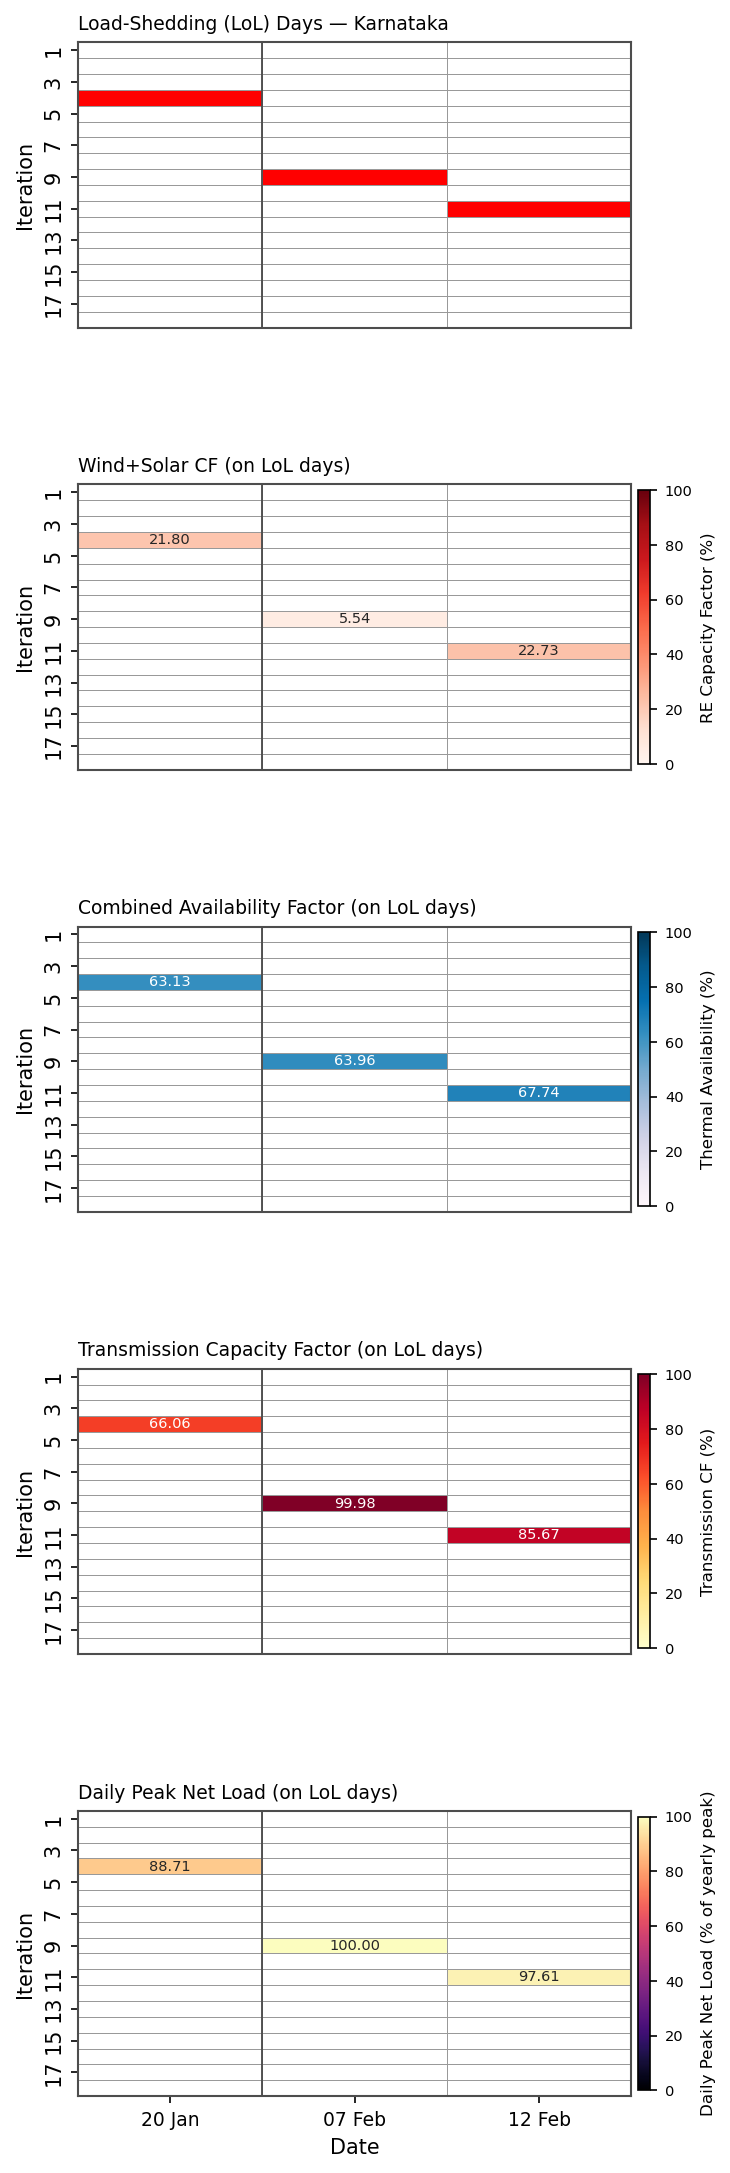

In [34]:
selected_zone = "Karnataka"   # ← change zone here
FY            = None            # e.g., 2040 for fiscal year Apr→Mar; or None to skip
plt.rcParams.update({"font.family": "Arial", "font.size": 10})

def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

def _iter_table(zone_df):
    it = (zone_df[['W','H','A']]
          .drop_duplicates()
          .sort_values(['W','H','A'])
          .reset_index(drop=True))
    it['iteration'] = np.arange(1, len(it)+1)
    return it

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1) WITHOUT using dispatch:
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')


def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No iterations found in plf_df for '{selected_zone}'.")

    # --- Daily LoL (zone) ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(columns=lol_dates)
                 .fillna(0).astype('int8'))

    # --- RE daily CF (Wind+Solar) on LoL days, as % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, as % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, as % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    # Hourly RE total for net-load
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]
    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']
    # Annual (iteration) peak
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']
    # Daily peak
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()  # (n_iter x 1)
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    # Keep a datetime index for x‑axis formatting & separators
    cols_dt = pd.to_datetime(lol_dates)
    return iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt


def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # Fonts
    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    # Annotation policy
    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    # Side colorbar helper (to RIGHT of each subplot)
    def _right_cbar(ax, mappable, label, width_pct=0.022, pad_pct=0.012):
        cax = ax.inset_axes([1.0 + pad_pct, 0.02, width_pct, 0.96])  # [x0,y0,w,h] in axes fraction
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    # Month boundaries (for separators)
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # Date tick labels (day + month) — bottom subplot only
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # Figure space (leave room on right for sidebars)
    n_iters = LoL.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(13, 2.8 + 0.75*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    # Grey gridlines for heatmaps
    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # 1) LoL (binary, no colorbar)
    sns.heatmap(LoL, ax=ax_lol, cmap=ListedColormap(['white','red']),
                vmin=0, vmax=1, cbar=False, **line_kwargs)
    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}",
                     loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # 2) Wind+Solar CF (%)
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # 3) Thermal CAF (%)
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Thermal Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # 4) Transmission CF (%)
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%)")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # 5) Daily Peak Net Load (% of yearly peak)
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net Load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net Load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # --- Keep day–month ticks only on the LAST subplot; label only there ---
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")  # ensure no x-label on upper panels

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")  # x-label only on the bottom panel

    # Month separators on all panels
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

    # Box outlines (spines) around every subplot
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    # Layout
    plt.subplots_adjust(left=0.08, right=0.90, top=0.96, bottom=0.12, hspace=0.55)
    plt.show()

plot_lol_story_sidebars(
    selected_zone=selected_zone,
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # set True to force numbers in every cell (can crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

/tmp/ipykernel_4143588/2565483272.py:128: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

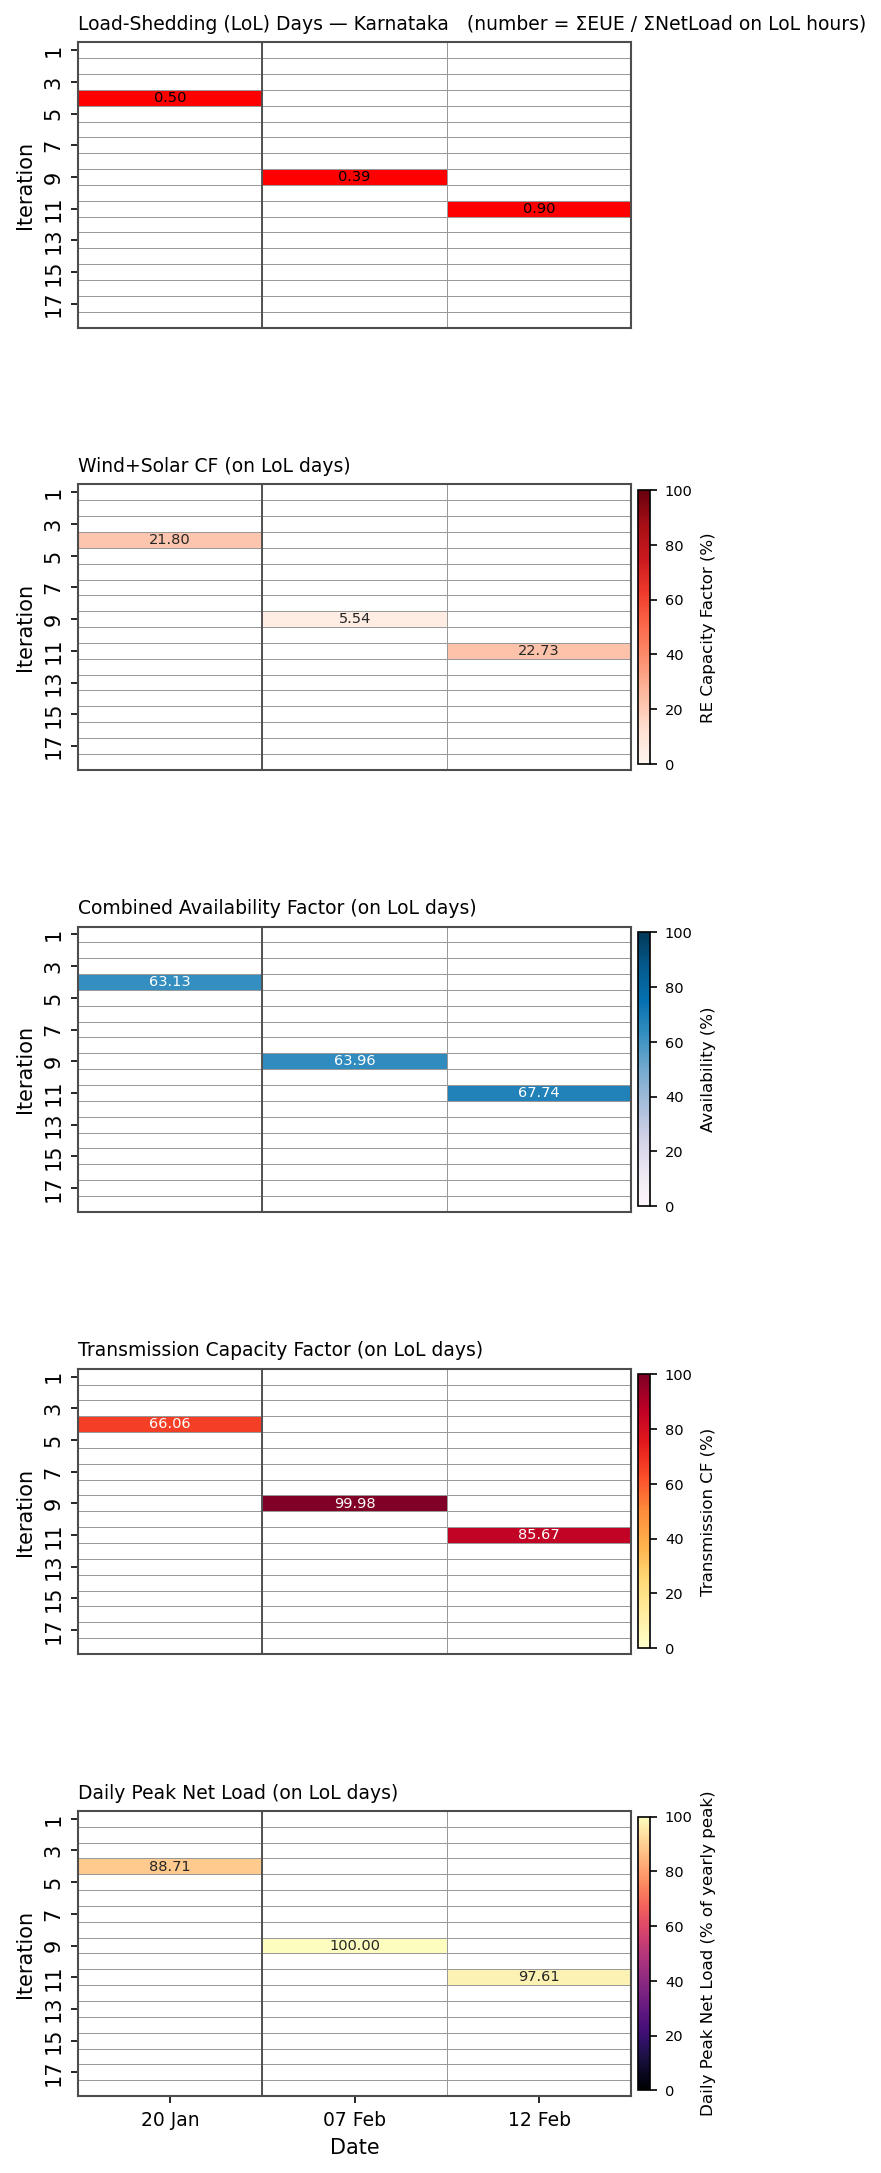

In [35]:
selected_zone = "Karnataka"   # ← change zone here
FY            = None          # e.g., 2040 for fiscal year Apr→Mar; or None to skip
plt.rcParams.update({"font.family": "Arial", "font.size": 10})


def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

def _iter_table(zone_df):
    it = (zone_df[['W','H','A']]
          .drop_duplicates()
          .sort_values(['W','H','A'])
          .reset_index(drop=True))
    it['iteration'] = np.arange(1, len(it)+1)
    return it

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1) WITHOUT using dispatch:
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')


def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No iterations found in plf_df for '{selected_zone}'.")

    # --- Load (hourly) & daily LoL ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)

    # daily LoL (presence)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(columns=lol_dates)
                 .fillna(0).astype('int8'))

    # --- RE daily CF (Wind+Solar) on LoL days, as % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, as % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, as % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    # Hourly RE total for net-load
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]

    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']

    # Annual (iteration) peak
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']

    # Daily peak
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    # --- NEW: Annotation value in LoL cell = sum(EUE) / sum(NetLoad) across LoL hours (per day & iteration) ---
    # Build hourly net-load again but include *hourly* unserved_energy to pick LoL hours
    load_hr_full = load.loc[load['load_zone']==selected_zone,
                            ['timestamp','date','W','H','A','static_load','unserved_energy']].copy()
    nl2 = (iters.merge(load_hr_full, on=['W','H','A'], how='left')
                .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl2['re_mw']        = nl2['re_mw'].fillna(0.0)
    nl2['net_load_mw']  = nl2['static_load'] - nl2['re_mw']
    nl2['is_lol_hour']  = nl2['unserved_energy'] > 0

    daily_ratio = (nl2.loc[nl2['is_lol_hour']]
                      .groupby(['W','H','A','date'], as_index=False)
                      .agg(eue_sum=('unserved_energy','sum'),
                           nl_sum =('net_load_mw',    'sum')))
    # ratio only if denominator positive
    daily_ratio['lol_ratio'] = np.where(daily_ratio['nl_sum'] > 0,
                                        daily_ratio['eue_sum'] / daily_ratio['nl_sum'],
                                        np.nan)

    LoL_ratio = (iters.merge(daily_ratio[['W','H','A','date','lol_ratio']], on=['W','H','A'], how='left')
                      .pivot_table(index='iteration', columns='date', values='lol_ratio', aggfunc='mean')
                      .reindex(columns=lol_dates))

    # Keep a datetime index for x‑axis formatting & separators
    cols_dt = pd.to_datetime(lol_dates)
    return iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt, LoL_ratio

def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt, LoL_ratio = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # Fonts
    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    # Annotation policy
    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    # Side colorbar helper (to RIGHT of each subplot)
    def _right_cbar(ax, mappable, label, width_pct=0.022, pad_pct=0.012):
        cax = ax.inset_axes([1.0 + pad_pct, 0.02, width_pct, 0.96])  # [x0,y0,w,h] in axes fraction
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    # Month boundaries (for separators)
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # Date tick labels (day + month) — bottom subplot only
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # Figure space (leave room on right for sidebars)
    n_iters = LoL.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(13, 2.8 + 0.75*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    # Grey gridlines for heatmaps
    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # ---- Build annotation array for LoL panel (strings, only where LoL==1) ----
    # Align to LoL shape
    LoL_ratio = LoL_ratio.reindex(index=LoL.index, columns=LoL.columns)
    annot_df  = LoL_ratio.where(LoL==1)
    annot_arr = np.where(np.isfinite(annot_df.values),
                         np.vectorize(lambda v: f"{v:.2f}")(annot_df.values),
                         "")

    # 1) LoL (binary) with requested number in cell
    sns.heatmap(LoL, ax=ax_lol, cmap=ListedColormap(['white','red']),
                vmin=0, vmax=1, cbar=False, **line_kwargs,
                annot=annot_arr, fmt="", annot_kws={'fontsize':7, 'color':'black'})
    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}   (number = ΣEUE / ΣNetLoad on LoL hours)",
                     loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # 2) Wind+Solar CF (%)
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # 3) Thermal CAF (%)
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # 4) Transmission CF (%)
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%)")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # 5) Daily Peak Net Load (% of yearly peak)
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net Load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net Load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # --- Keep day–month ticks only on the LAST subplot; label only there ---
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")  # ensure no x-label on upper panels

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")  # x-label only on the bottom panel

    # Month separators on all panels
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

    # Box outlines (spines) around every subplot
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    # Layout
    plt.subplots_adjust(left=0.08, right=0.90, top=0.96, bottom=0.12, hspace=0.55)
    plt.show()

plot_lol_story_sidebars(
    selected_zone=selected_zone,
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # True to force numbers in every cell (may crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

/tmp/ipykernel_4143588/3589008857.py:128: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

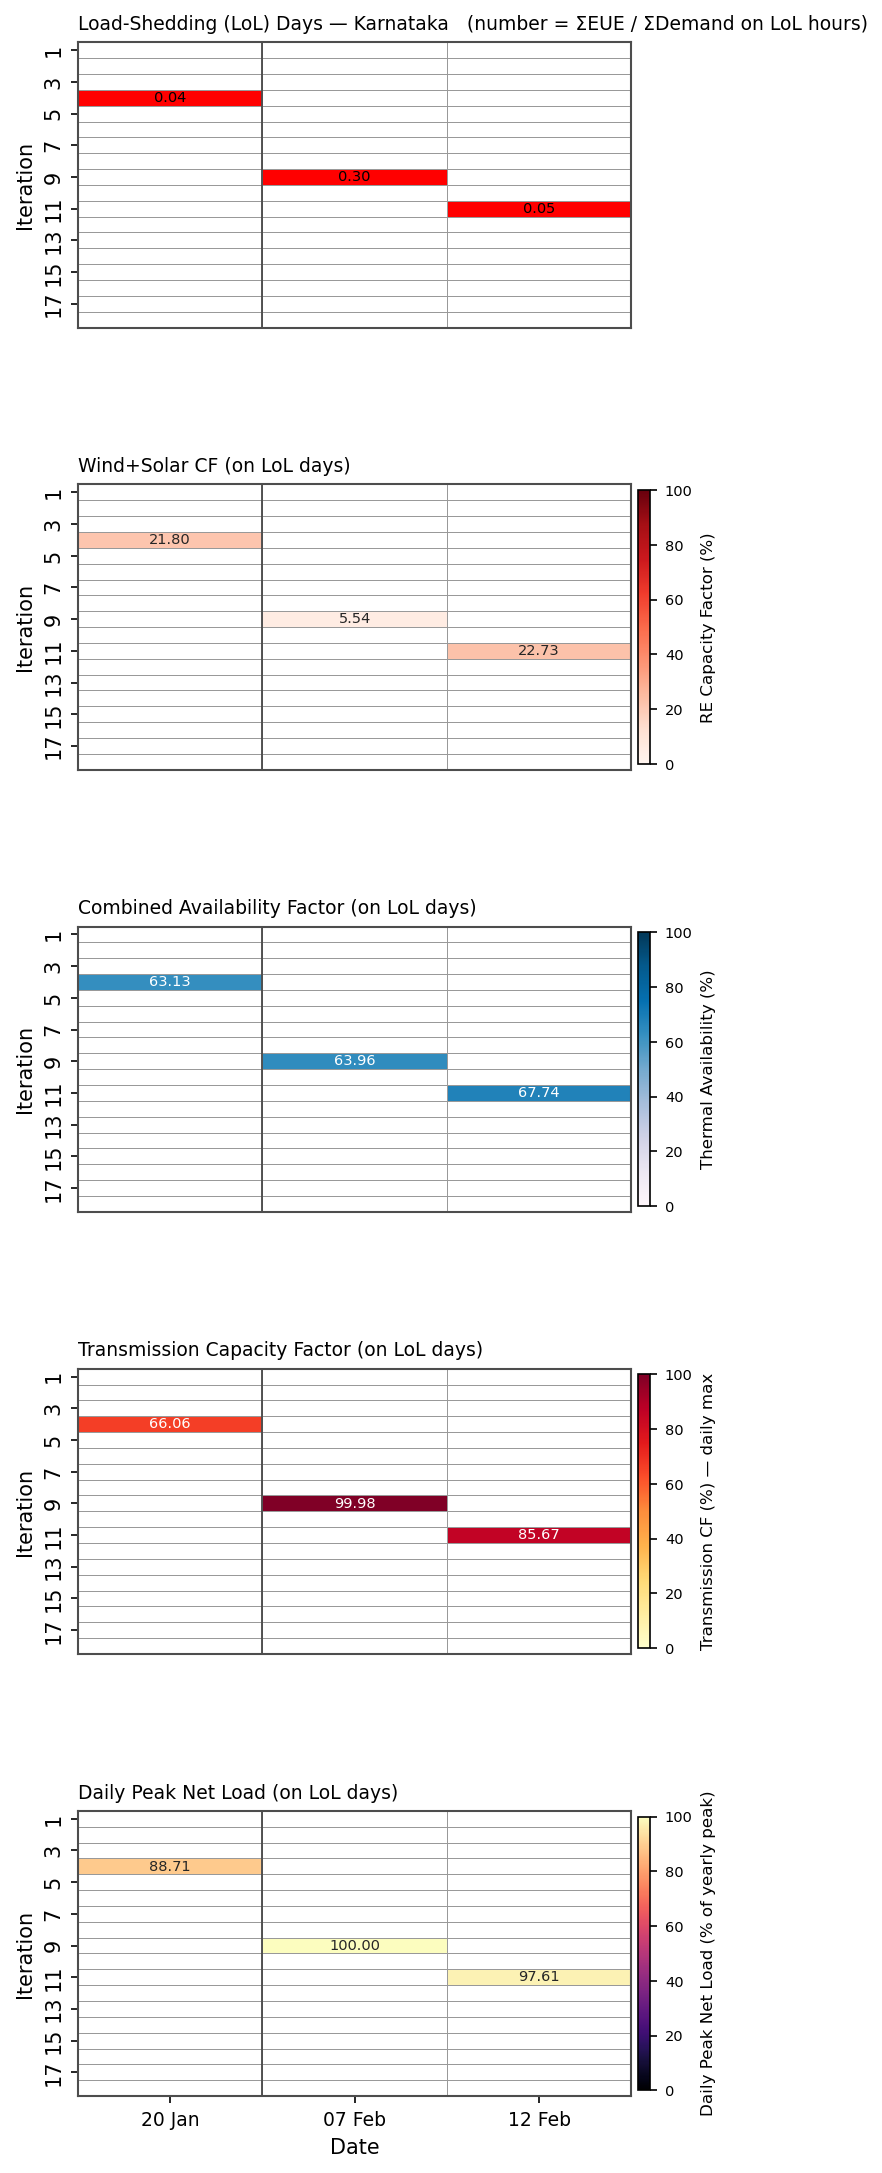

In [36]:
# === Imports (keep what you already have) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# === USER SETTINGS (same as before) ===
selected_zone = "Karnataka"   # ← change zone here
FY            = None          # e.g., 2040 for fiscal year Apr→Mar; or None to skip
plt.rcParams.update({"font.family": "Arial", "font.size": 10})

# ----------------------------------------------------------------------
# Helpers (unchanged)
# ----------------------------------------------------------------------
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

def _iter_table(zone_df):
    it = (zone_df[['W','H','A']]
          .drop_duplicates()
          .sort_values(['W','H','A'])
          .reset_index(drop=True))
    it['iteration'] = np.arange(1, len(it)+1)
    return it

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1) WITHOUT using dispatch:
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')

# ----------------------------------------------------------------------
# Build matrices for LoL days ONLY (zone-wise, W/H/A-wise)
# (Modified to annotate LoL cells with ΣEUE / ΣDemand over LoL hours)
# ----------------------------------------------------------------------
def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No iterations found in plf_df for '{selected_zone}'.")

    # --- Load (hourly) & daily LoL ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)

    # daily LoL (presence)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(columns=lol_dates)
                 .fillna(0).astype('int8'))

    # --- RE daily CF (Wind+Solar) on LoL days, as % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, as % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, as % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    # Hourly RE total for net-load
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]

    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']

    # Annual (iteration) peak
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']

    # Daily peak
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    # --- NEW: LoL cell annotation = ΣEUE / ΣDemand over LoL hours (per day & iteration) ---
    load_hr_full = load.loc[load['load_zone']==selected_zone,
                            ['timestamp','date','W','H','A','static_load','unserved_energy']].copy()
    # Mark LoL hours
    load_hr_full['is_lol_hour'] = load_hr_full['unserved_energy'] > 0

    # Aggregate ONLY those LoL hours → daily ΣEUE and ΣDemand
    daily_ratio = (load_hr_full.loc[load_hr_full['is_lol_hour']]
                                 .groupby(['W','H','A','date'], as_index=False)
                                 .agg(eue_sum=('unserved_energy','sum'),
                                      demand_sum=('static_load',    'sum')))
    # Ratio only if denominator positive
    daily_ratio['lol_ratio'] = np.where(daily_ratio['demand_sum'] > 0,
                                        daily_ratio['eue_sum'] / daily_ratio['demand_sum'],
                                        np.nan)

    LoL_ratio = (iters.merge(daily_ratio[['W','H','A','date','lol_ratio']], on=['W','H','A'], how='left')
                      .pivot_table(index='iteration', columns='date', values='lol_ratio', aggfunc='mean')
                      .reindex(columns=lol_dates))

    # Keep a datetime index for x‑axis formatting & separators
    cols_dt = pd.to_datetime(lol_dates)
    return iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt, LoL_ratio

# ----------------------------------------------------------------------
# Plot (unchanged except LoL title text)
# ----------------------------------------------------------------------
def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt, LoL_ratio = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # Fonts
    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    # Annotation policy
    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    # Side colorbar helper (to RIGHT of each subplot)
    def _right_cbar(ax, mappable, label, width_pct=0.022, pad_pct=0.012):
        cax = ax.inset_axes([1.0 + pad_pct, 0.02, width_pct, 0.96])  # [x0,y0,w,h] in axes fraction
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    # Month boundaries (for separators)
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # Date tick labels (day + month) — bottom subplot only
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # Figure space (leave room on right for sidebars)
    n_iters = LoL.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(13, 2.8 + 0.75*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    # Grey gridlines for heatmaps
    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # ---- Build annotation array for LoL panel (strings, only where LoL==1) ----
    LoL_ratio = LoL_ratio.reindex(index=LoL.index, columns=LoL.columns)
    annot_df  = LoL_ratio.where(LoL==1)
    annot_arr = np.where(np.isfinite(annot_df.values),
                         np.vectorize(lambda v: f"{v:.2f}")(annot_df.values),
                         "")

    # 1) LoL (binary) with ΣEUE/ΣDemand annotation
    sns.heatmap(LoL, ax=ax_lol, cmap=ListedColormap(['white','red']),
                vmin=0, vmax=1, cbar=False, **line_kwargs,
                annot=annot_arr, fmt="", annot_kws={'fontsize':7, 'color':'black'})
    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}   (number = ΣEUE / ΣDemand on LoL hours)",
                     loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # 2) Wind+Solar CF (%)
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # 3) Thermal CAF (%)
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Thermal Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # 4) Transmission CF (%)
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%) — daily max")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # 5) Daily Peak Net Load (% of yearly peak)
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net Load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net Load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # --- Keep day–month ticks only on the LAST subplot; label only there ---
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")  # ensure no x-label on upper panels

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")  # x-label only on the bottom panel

    # Month separators on all panels
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

    # Box outlines (spines) around every subplot
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    # Layout
    plt.subplots_adjust(left=0.08, right=0.90, top=0.96, bottom=0.12, hspace=0.55)
    plt.show()

# ----------------------------------------------------------------------
# RUN (assumes plf_df, df_load_, df_dispatch_, df_transmission_timepoints_zone exist)
# ----------------------------------------------------------------------
plot_lol_story_sidebars(
    selected_zone=selected_zone,
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # True to force numbers in every cell (may crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

/tmp/ipykernel_4143588/1034177182.py:114: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

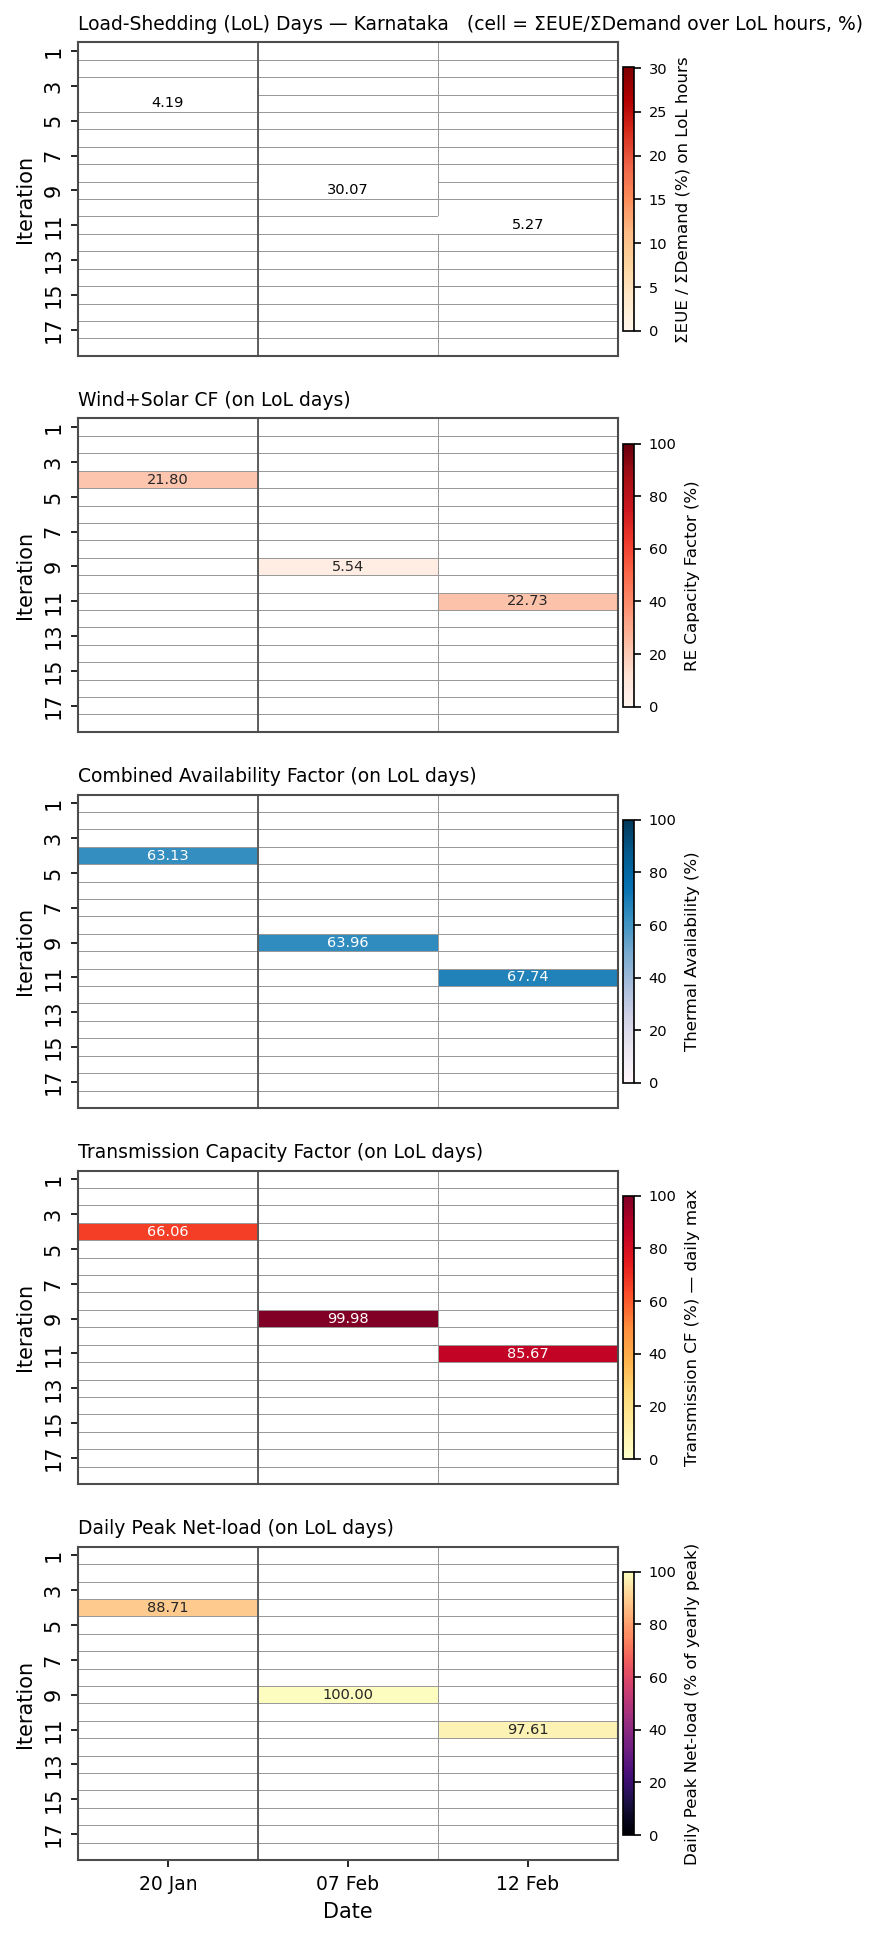

In [ ]:

selected_zone = "Karnataka"   # ← change zone here
FY            = None          # e.g., 2040 for fiscal year Apr→Mar; or None to skip
plt.rcParams.update({"font.family": "Arial", "font.size": 10})


def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

def _iter_table(zone_df):
    it = (zone_df[['W','H','A']]
          .drop_duplicates()
          .sort_values(['W','H','A'])
          .reset_index(drop=True))
    it['iteration'] = np.arange(1, len(it)+1)
    return it

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1) WITHOUT using dispatch:
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')

# ================== BUILD MATRICES (LoL days only) ==================
def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No iterations found in plf_df for '{selected_zone}'.")

    # --- Load (hourly) & daily LoL presence ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)

    lol_daily = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                      .max())
    lol_daily['LoL'] = (lol_daily['unserved_energy'] > 0).astype('int8')
    lol_daily = lol_daily.drop(columns=['unserved_energy'])
    lol_daily = lol_daily[lol_daily['load_zone'] == selected_zone].copy()

    it_lol    = iters.merge(lol_daily, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # Binary LoL matrix
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(columns=lol_dates)
                 .fillna(0).astype('int8'))

    # --- RE daily CF (Wind+Solar) on LoL days, in % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, in % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, in % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]
    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    # --- LoL cell value = ΣEUE / ΣDemand over LoL HOURS (per day & iteration), in % ---
    load_hr_full = load.loc[load['load_zone']==selected_zone,
                            ['timestamp','date','W','H','A','static_load','unserved_energy']].copy()
    load_hr_full['is_lol_hour'] = load_hr_full['unserved_energy'] > 0
    daily_ratio = (load_hr_full.loc[load_hr_full['is_lol_hour']]
                                 .groupby(['W','H','A','date'], as_index=False)
                                 .agg(eue_sum=('unserved_energy','sum'),
                                      demand_sum=('static_load',    'sum')))
    daily_ratio['lol_ratio_pct'] = np.where(daily_ratio['demand_sum'] > 0,
                                            100.0 * daily_ratio['eue_sum'] / daily_ratio['demand_sum'],
                                            np.nan)

    LoL_ratio_pct = (iters.merge(daily_ratio[['W','H','A','date','lol_ratio_pct']],
                                 on=['W','H','A'], how='left')
                          .pivot_table(index='iteration', columns='date', values='lol_ratio_pct', aggfunc='mean')
                          .reindex(columns=lol_dates))

    # --- make sure shapes/indices ALIGN with LoL to avoid broadcasting errors ---
    LoL_ratio_pct = LoL_ratio_pct.reindex(index=LoL.index, columns=LoL.columns)

    cols_dt = pd.to_datetime(lol_dates)
    return iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt, LoL_ratio_pct

# ================== PLOT (reduced gaps + LoL colorbar + % text) ==================
def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt, LoL_ratio_pct = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # Fonts
    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    # Annotation policy
    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    # Right‑side colorbar helper (tight insets to reduce vertical space)
    def _right_cbar(ax, mappable, label, width_pct=0.020, pad_pct=0.010):
        cax = ax.inset_axes([1.0 + pad_pct, 0.08, width_pct, 0.84])  # [x0,y0,w,h] in axes fraction
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    # Month boundaries (for separators)
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # Date tick labels (day + month) — bottom subplot only
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # Figure space (reduced vertical gaps; room on right for sidebars)
    n_iters = LoL.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(11, 2.0 + 0.70*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    # Thin grey gridlines
    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # ------- (1) LoL panel: show % and colorbar ----------
    # Mask non‑LoL cells; colorbar 0 → max across panel
    mask_lol = (LoL == 0) | ~np.isfinite(LoL_ratio_pct)
    vmax_lol = float(np.nanmax(LoL_ratio_pct.values)) if np.isfinite(np.nanmax(LoL_ratio_pct.values)) else 1.0

    hm_lol = sns.heatmap(
        LoL_ratio_pct, ax=ax_lol, cmap="OrRd", vmin=0, vmax=vmax_lol,
        mask=mask_lol, cbar=False, **line_kwargs
    )
    _right_cbar(ax_lol, hm_lol.collections[0], "ΣEUE / ΣDemand (%) on LoL hours")

    # Annotate percentages in LoL cells (two decimals); blank elsewhere
    show_annot = _should_annot(LoL_ratio_pct)
    if show_annot:
        annot_data = LoL_ratio_pct.round(2).astype(str)
        annot_data = annot_data.where(~mask_lol, "")  # blank masked cells
        sns.heatmap(
            LoL_ratio_pct*0, ax=ax_lol, cmap=ListedColormap(['white']), cbar=False,
            annot=annot_data, fmt="", annot_kws={'fontsize': 7, 'color': 'black'},
            linewidths=0, linecolor='white'
        )

    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}   (cell = ΣEUE/ΣDemand over LoL hours, %)",
                     loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # ------- (2) RE CF (% on LoL days) ----------
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # ------- (3) Thermal CAF (% on LoL days) ----------
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Thermal Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # ------- (4) Transmission CF (% on LoL days) ----------
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%) — daily max")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # ------- (5) Daily Peak Net‑load (% of yearly peak, on LoL days) ----------
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net‑load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net‑load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # --- Keep day–month ticks only on the LAST subplot; label only there ---
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")  # ensure no x-label on upper panels

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")  # x-label only on the bottom panel

    # Month separators on all panels
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.35', linewidth=0.9)

    # Box outlines (spines) around every subplot
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    # -------- Reduced vertical gaps without overlaps --------
    # a) slightly smaller hspace; b) snug right margin for sidebars
    plt.subplots_adjust(left=0.08, right=0.88, top=0.95, bottom=0.12, hspace=0.20)
    plt.show()

# ================== RUN ==================
plot_lol_story_sidebars(
    selected_zone=selected_zone,
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # True to force numbers in every cell (can crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

/tmp/ipykernel_4143588/2855541581.py:130: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

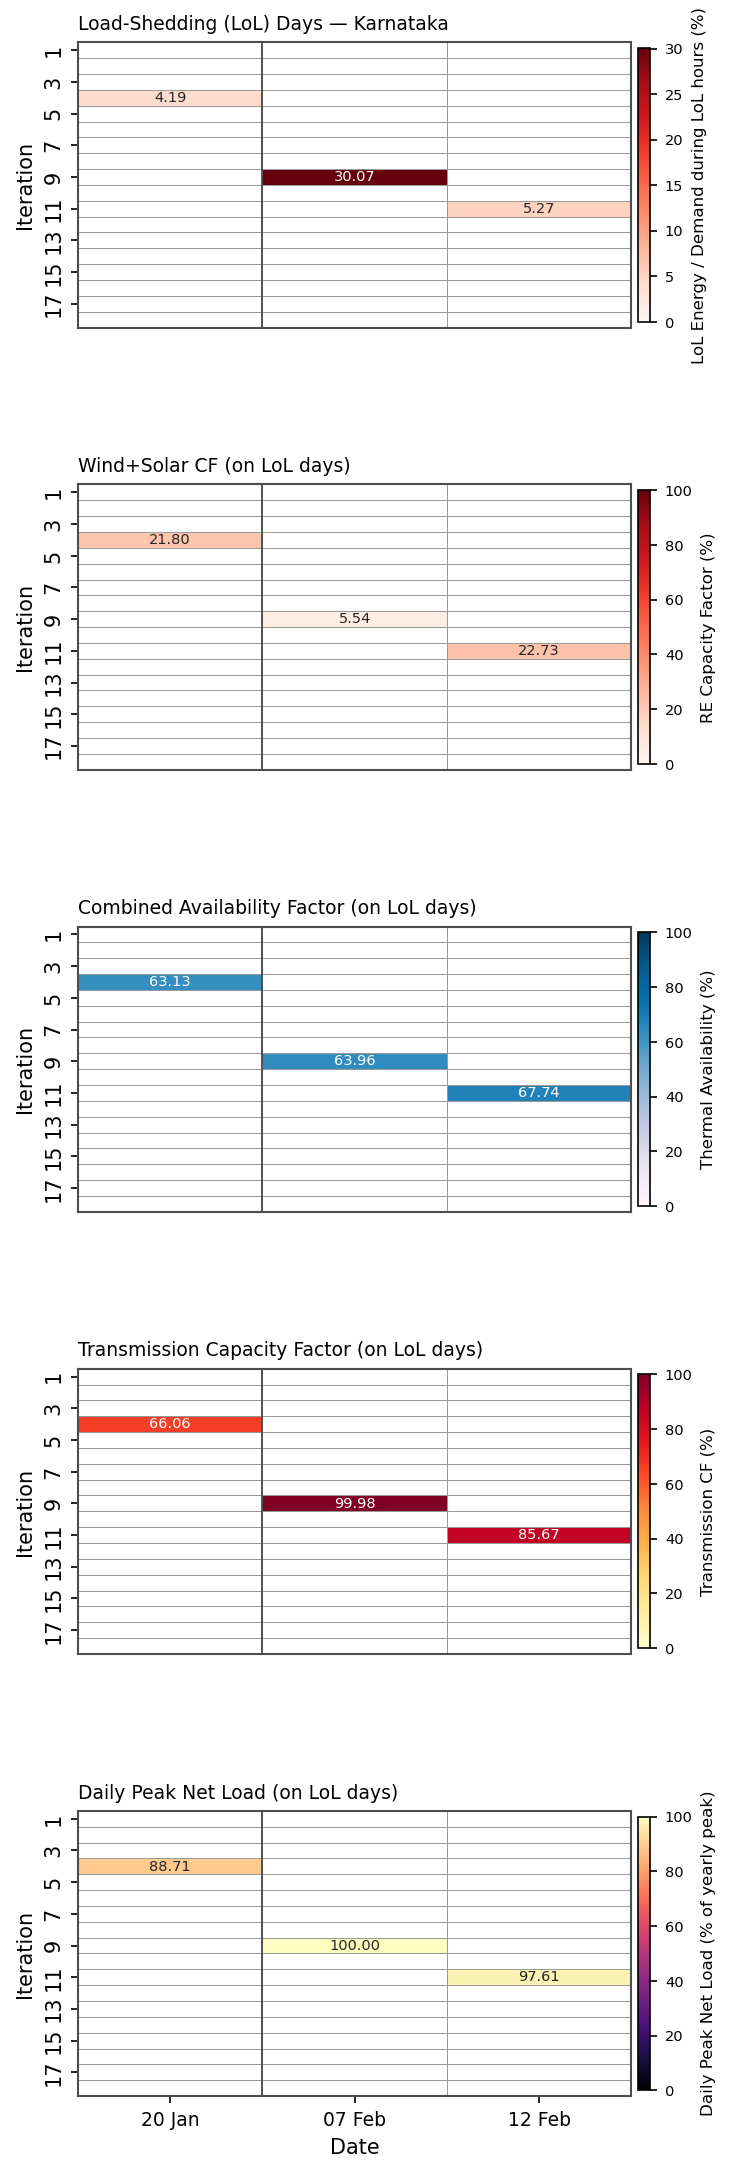

In [41]:
selected_zone = "Karnataka"   # ← change zone here
FY            = None          # e.g., 2040 for fiscal year Apr→Mar; or None to skip
plt.rcParams.update({"font.family": "Arial", "font.size": 10})

def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

def _iter_table(zone_df):
    it = (zone_df[['W','H','A']]
          .drop_duplicates()
          .sort_values(['W','H','A'])
          .reset_index(drop=True))
    it['iteration'] = np.arange(1, len(it)+1)
    return it

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1):
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')


def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No iterations found in plf_df for '{selected_zone}'.")

    # --- Daily LoL (zone) ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary 0/1)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(index=iters['iteration'], columns=lol_dates)
                 .fillna(0).astype('int8'))

    # === NEW: LoL % = (sum UE on LoL hours) / (sum static load on those SAME hours) × 100 ===
    # Filter to LoL HOURS only, then group by day
    load_zone = load[load['load_zone'] == selected_zone].copy()
    lol_hours = load_zone[load_zone['unserved_energy'] > 0].copy()  # only hours with LoL
    # daily sums in LoL hours only
    lol_ratio_day = (lol_hours.groupby(['W','H','A','date'], as_index=False)
                               .agg(ue=('unserved_energy','sum'),
                                    demand=('static_load','sum')))
    lol_ratio_day['lol_ratio_pct'] = np.where(
        lol_ratio_day['demand'] > 0, 100.0 * lol_ratio_day['ue'] / lol_ratio_day['demand'], np.nan
    )
    # attach iteration id, pivot to iter × date, align to LoL calendar
    LoL_ratio_pct = (iters.merge(lol_ratio_day[['W','H','A','date','lol_ratio_pct']], on=['W','H','A'], how='left')
                          .pivot_table(index='iteration', columns='date', values='lol_ratio_pct', aggfunc='sum')
                          .reindex(index=iters['iteration'], columns=lol_dates))
    # keep values only where LoL==1
    LoL_ratio_pct = LoL_ratio_pct.where(LoL==1)

    # --- RE daily CF (Wind+Solar) on LoL days, as % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, as % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, as % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]
    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(index=iters['iteration'], columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    cols_dt = pd.to_datetime(lol_dates)
    # NOTE: return now includes LoL_ratio_pct (2nd item)
    return iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt


def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    # Unpack with LoL_ratio_pct as second output (only change here)
    iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # Fonts
    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    # Side colorbar (to RIGHT of each subplot)
    def _right_cbar(ax, mappable, label, width_pct=0.022, pad_pct=0.012):
        cax = ax.inset_axes([1.0 + pad_pct, 0.02, width_pct, 0.96])
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    # Month boundaries (for separators)
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # Date tick labels (day + month) — bottom subplot only
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # Figure space (leave room on right for sidebars)
    n_iters = LoL_ratio_pct.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(13, 2.8 + 0.75*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    # Grey gridlines for heatmaps
    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # -------- (1) LoL panel: show % with colorbar and (optional) numbers ----------
    annot_lol = _should_annot(LoL_ratio_pct)
    vmax_lol  = float(np.nanmax(LoL_ratio_pct.values)) if np.isfinite(np.nanmax(LoL_ratio_pct.values)) else 0.0
    hm_lol = sns.heatmap(
        LoL_ratio_pct, ax=ax_lol, cmap="Reds", vmin=0, vmax=vmax_lol if vmax_lol>0 else 1,
        mask=LoL_ratio_pct.isna(), annot=annot_lol, fmt=".2f",
        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs
    )
    _right_cbar(ax_lol, hm_lol.collections[0], "LoL Energy / Demand during LoL hours (%)")
    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}", loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # 2) Wind+Solar CF (%)
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # 3) Thermal CAF (%)
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Thermal Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # 4) Transmission CF (%)
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%)")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # 5) Daily Peak Net Load (% of yearly peak)
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net Load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net Load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # --- Keep day–month ticks only on the LAST subplot; label only there ---
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")  # ensure no x-label on upper panels

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")  # x-label only on the bottom panel

    # Month separators on all panels
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

    # Box outlines (spines) around every subplot
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    # Layout
    plt.subplots_adjust(left=0.08, right=0.90, top=0.96, bottom=0.12, hspace=0.55)
    plt.show()

plot_lol_story_sidebars(
    selected_zone=selected_zone,
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # set True to force numbers in every cell (can crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

/tmp/ipykernel_4143588/2168019167.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

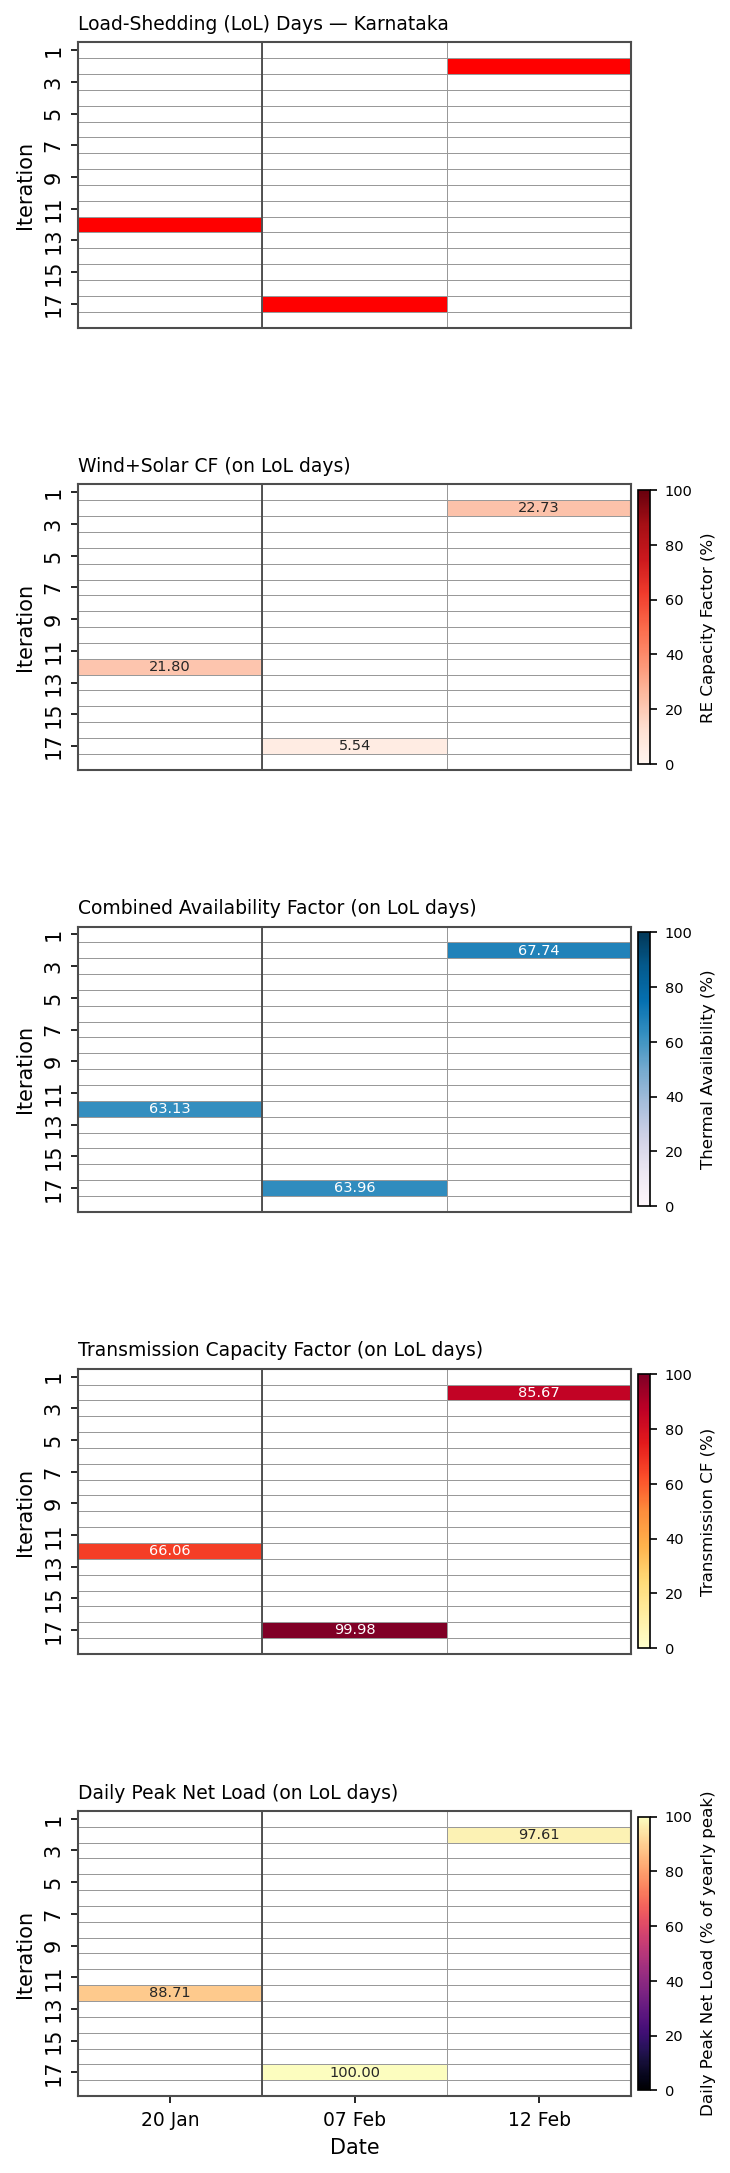

In [42]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# --------------------
# Config
# --------------------
selected_zone = "Karnataka"   # ← change zone here
FY            = None          # e.g., 2040 for fiscal year Apr→Mar; or None to skip
plt.rcParams.update({"font.family": "Arial", "font.size": 10})

# --------------------
# Helpers (unchanged except iteration logic)
# --------------------
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1) WITHOUT using dispatch:
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')

# ---- NEW: strict iteration mapper (iteration i ≡ W=i, H=i, A=i) ----
def _iter_table_strict(zone_df):
    """
    Keep only combos where W==H==A; set iteration := int(W).
    This makes the plots mean “iteration i == W=i, H=i, A=i”.
    """
    it = zone_df[['W','H','A']].drop_duplicates().copy()

    # robust numeric parse (handles '1' or 'W1' etc.)
    def _to_num(x):
        if pd.isna(x): return np.nan
        s = str(x)
        # try direct int
        try:
            return int(s)
        except Exception:
            m = re.search(r'\d+', s)
            return int(m.group()) if m else np.nan

    it['Wn'] = it['W'].map(_to_num)
    it['Hn'] = it['H'].map(_to_num)
    it['An'] = it['A'].map(_to_num)

    # keep only rows where W==H==A and all numeric
    it = it[it['Wn'].notna() & (it['Wn'] == it['Hn']) & (it['Wn'] == it['An'])].copy()

    # iteration is that common integer
    it['iteration'] = it['Wn'].astype(int)

    # final tidy
    it = it[['W','H','A','iteration']].drop_duplicates().sort_values('iteration').reset_index(drop=True)
    if it.empty:
        raise ValueError("No (W,H,A) combos satisfy W==H==A for strict iteration mapping.")
    return it

# --------------------
# Build matrices (unchanged logic; uses strict iteration)
# --------------------
def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)

    # STRICT iteration mapping here:
    iters = _iter_table_strict(base)

    # --- Daily LoL (zone) ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(columns=lol_dates)
                 .fillna(0).astype('int8'))

    # --- RE daily CF (Wind+Solar) on LoL days, as % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, as % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, as % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    # Hourly RE total for net-load
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]
    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']
    # Annual (iteration) peak
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']
    # Daily peak
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()  # (n_iter x 1)
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    # Keep a datetime index for x‑axis formatting & separators
    cols_dt = pd.to_datetime(lol_dates)
    return iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt

# --------------------
# Plot (unchanged)
# --------------------
def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    def _right_cbar(ax, mappable, label, width_pct=0.022, pad_pct=0.012):
        cax = ax.inset_axes([1.0 + pad_pct, 0.02, width_pct, 0.96])
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    n_iters = LoL.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(13, 2.8 + 0.75*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # 1) LoL
    sns.heatmap(LoL, ax=ax_lol, cmap=ListedColormap(['white','red']),
                vmin=0, vmax=1, cbar=False, **line_kwargs)
    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}",
                     loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # 2) Wind+Solar CF (%)
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # 3) Thermal CAF (%)
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Thermal Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # 4) Transmission CF (%)
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%)")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # 5) Daily Peak Net Load (% of yearly peak)
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net Load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net Load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # X-axis: ticks only on the bottom panel
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")

    # Month separators
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

    # Box outlines
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    plt.subplots_adjust(left=0.08, right=0.90, top=0.96, bottom=0.12, hspace=0.55)
    plt.show()

# ================== RUN ==================
plot_lol_story_sidebars(
    selected_zone=selected_zone,
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # set True to force numbers in every cell (can crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

/tmp/ipykernel_4143588/2168019167.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

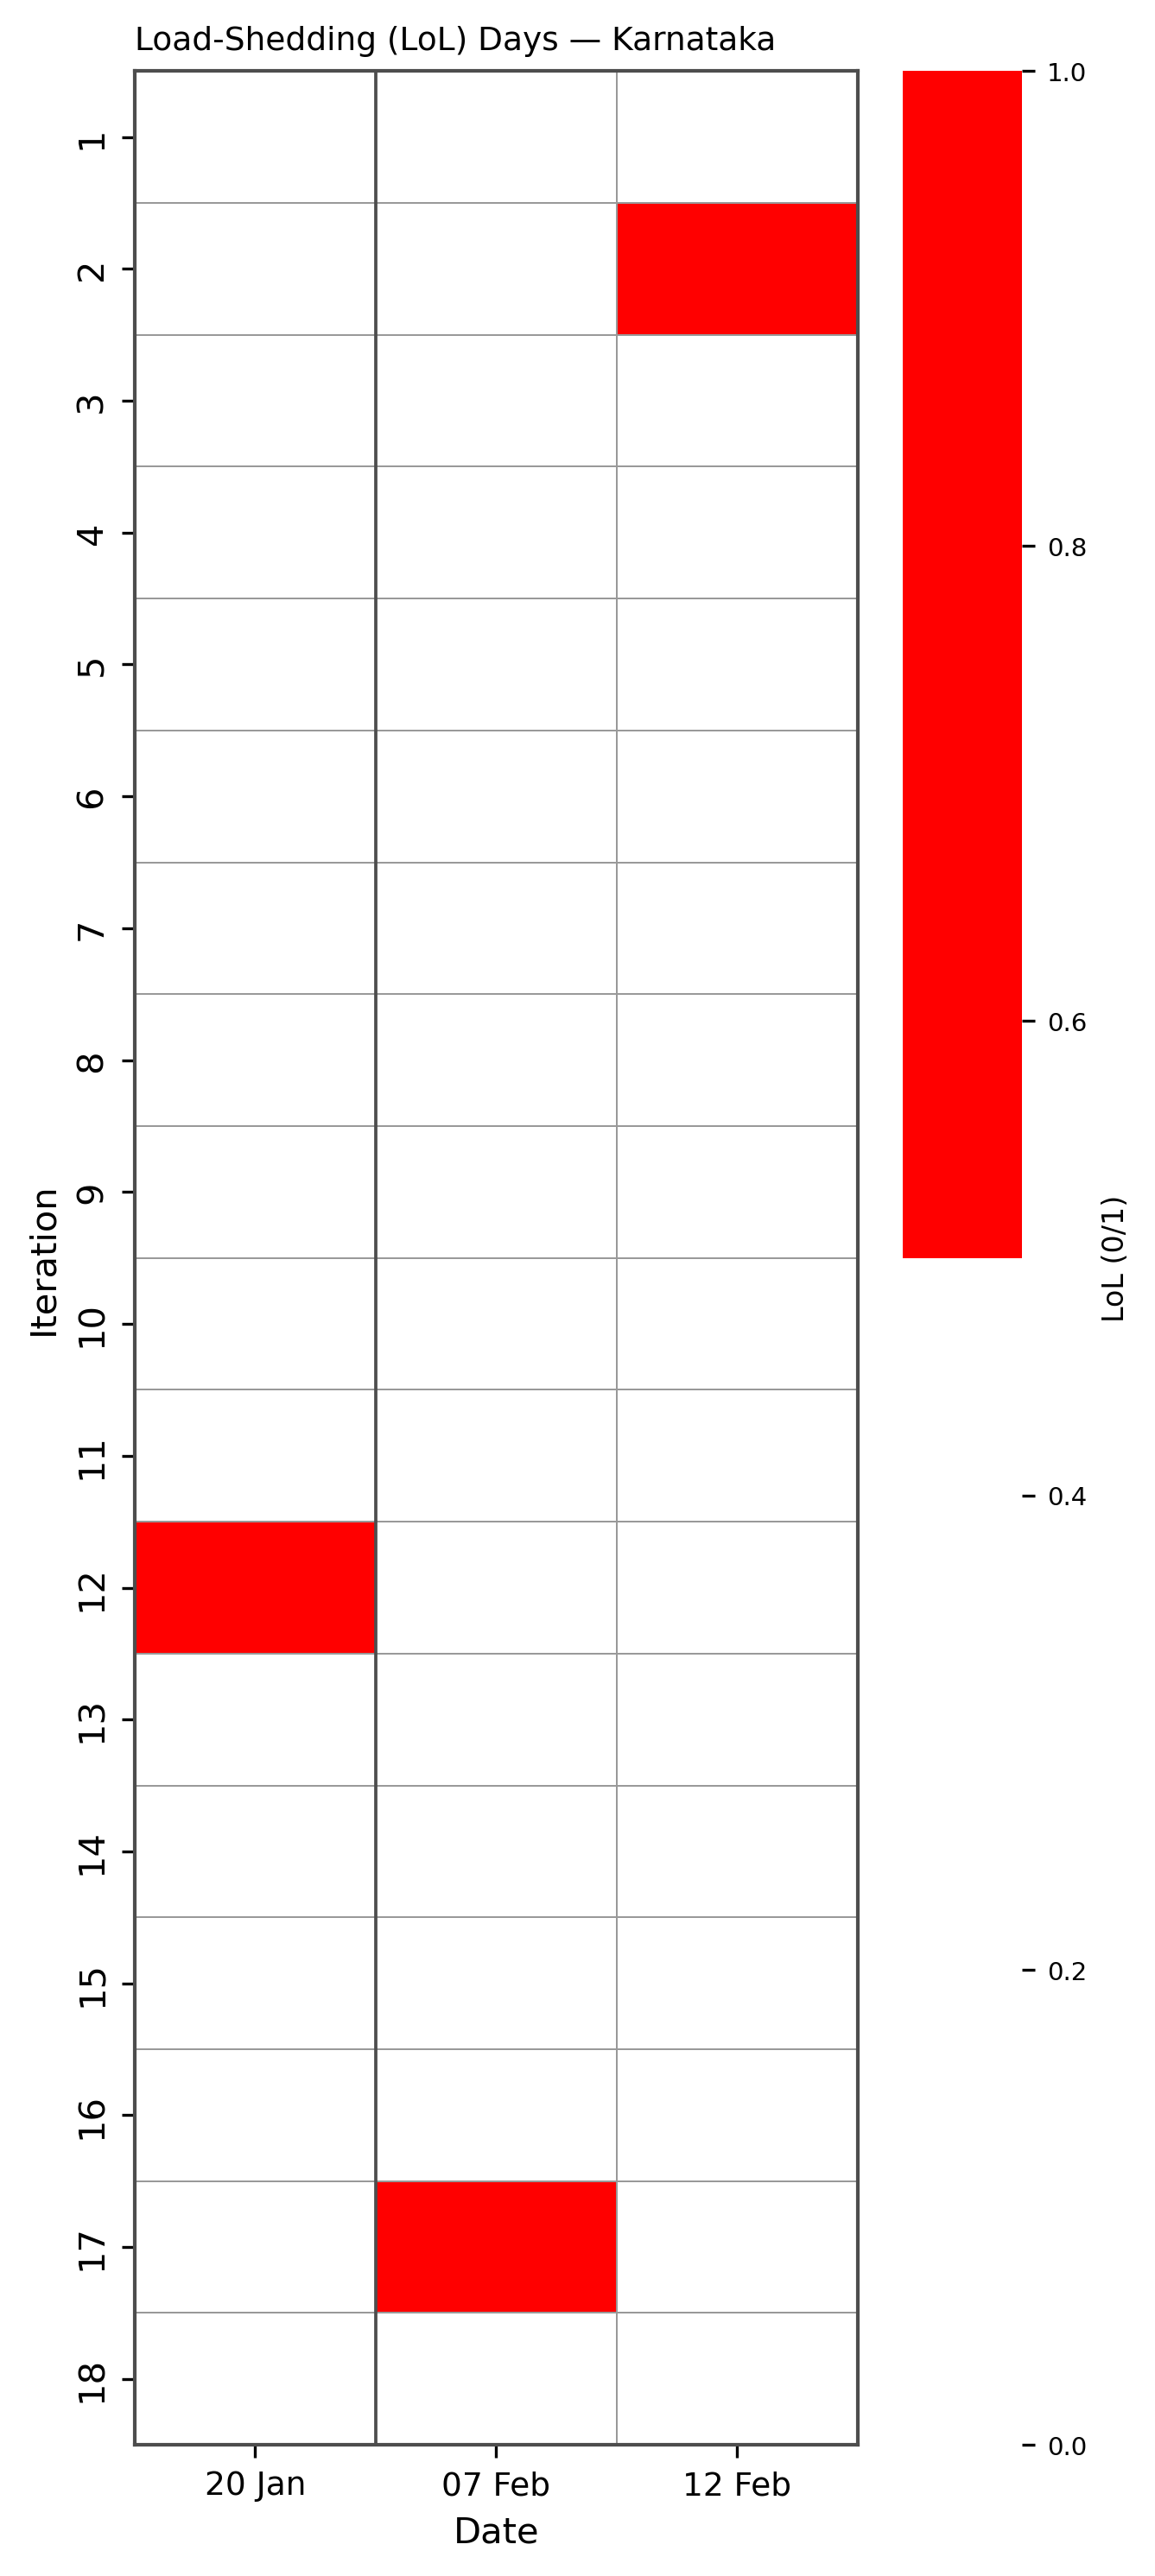

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt/Karnataka_01_LoL_days.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

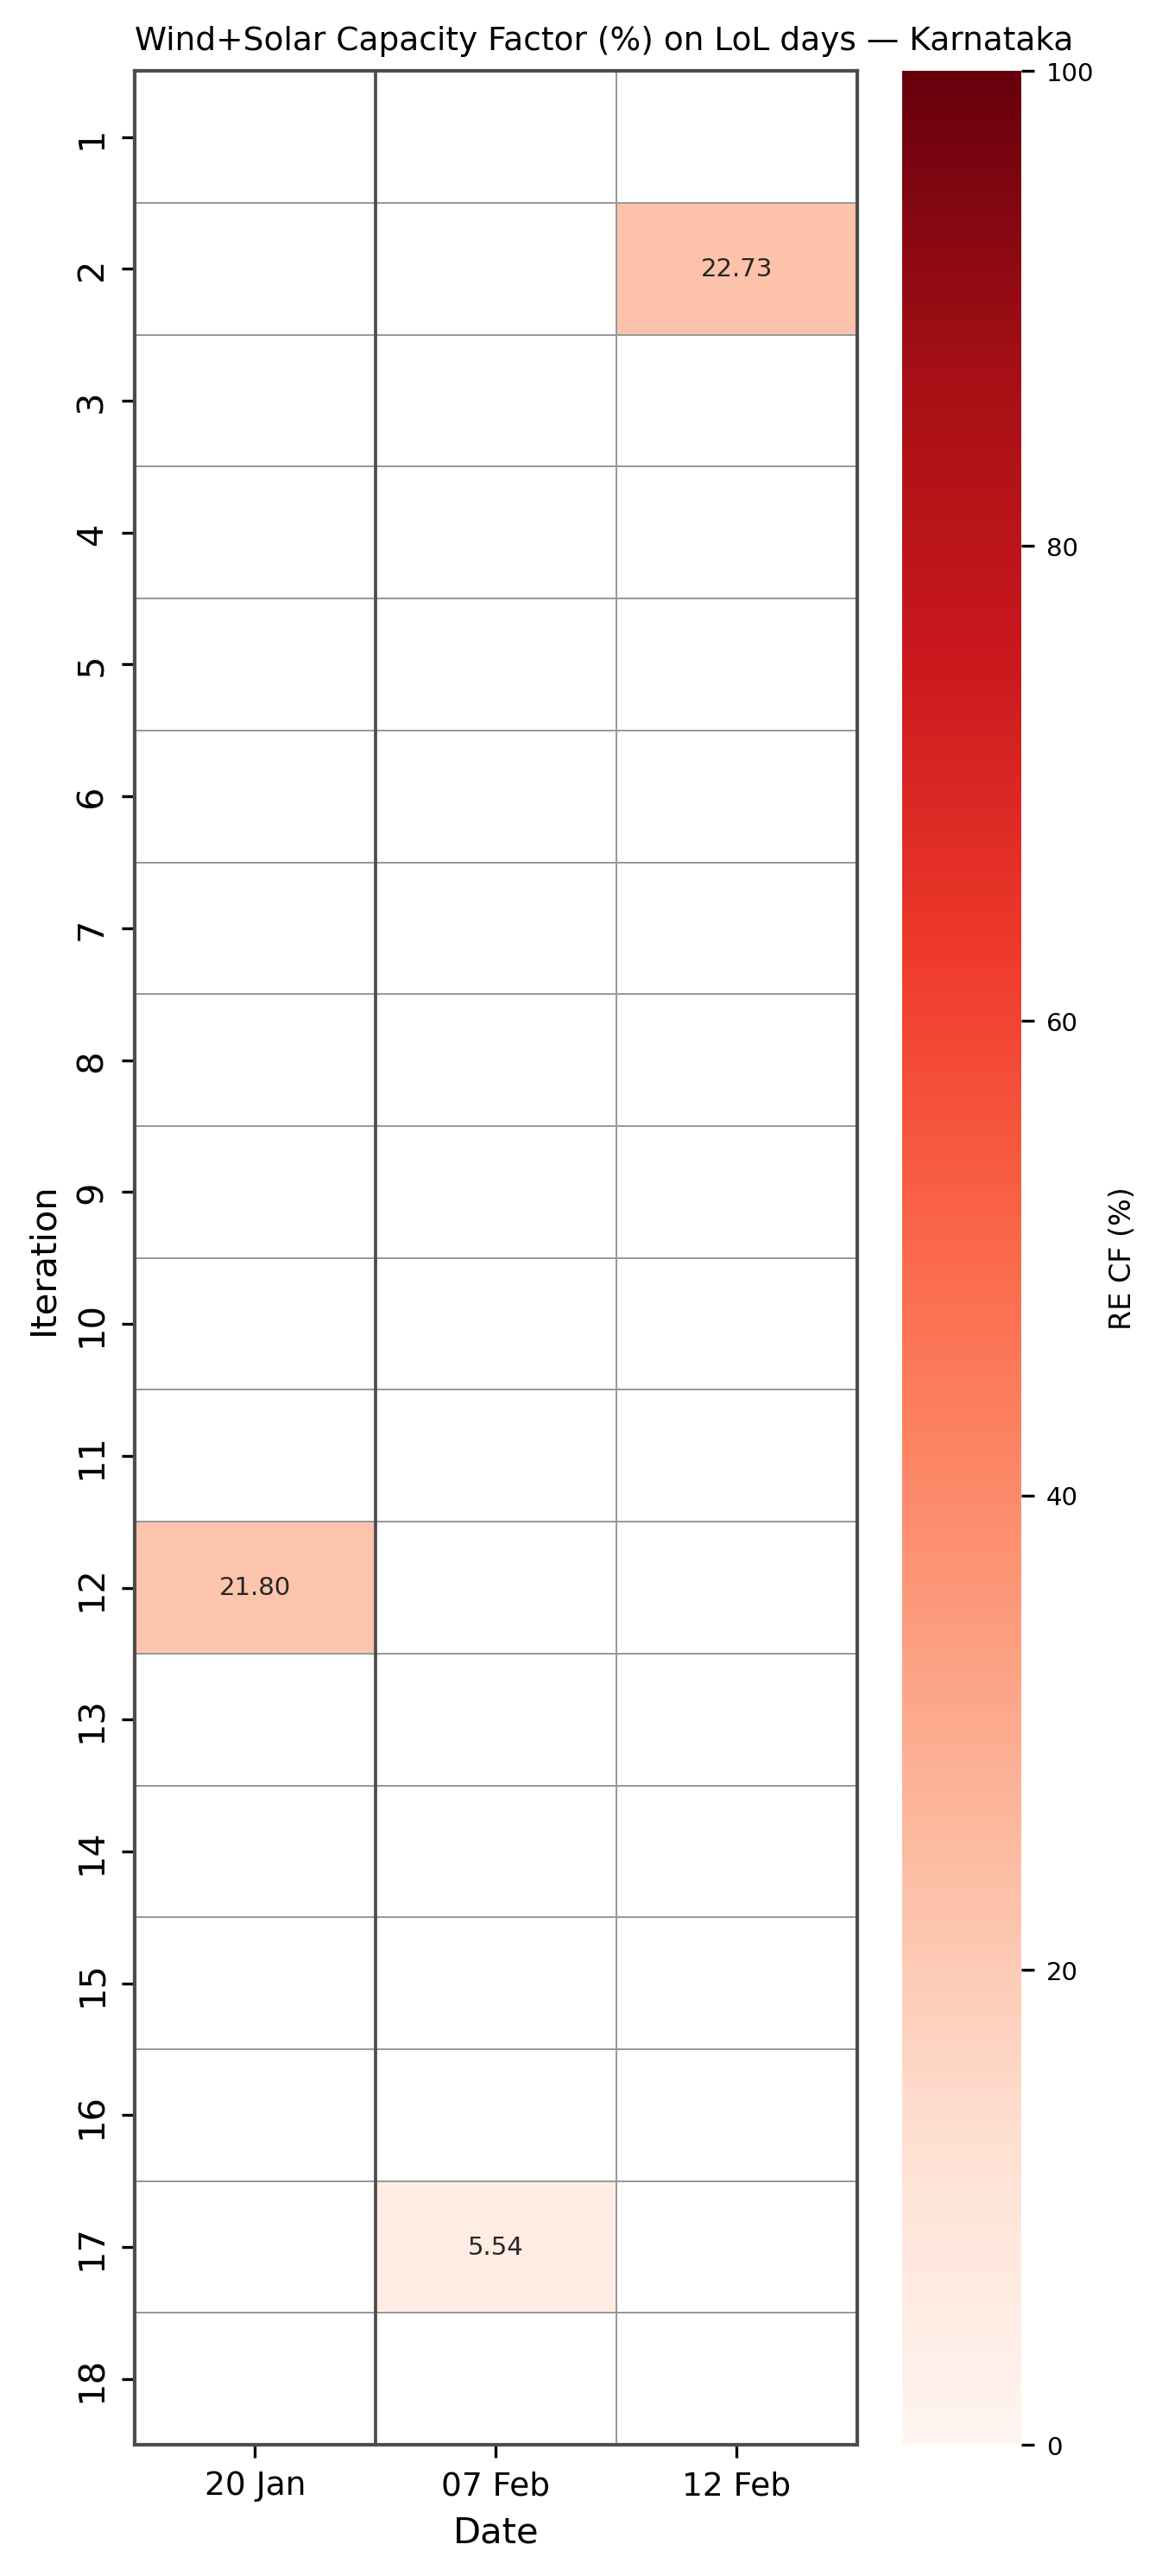

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt/Karnataka_02_RE_CF_pct.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

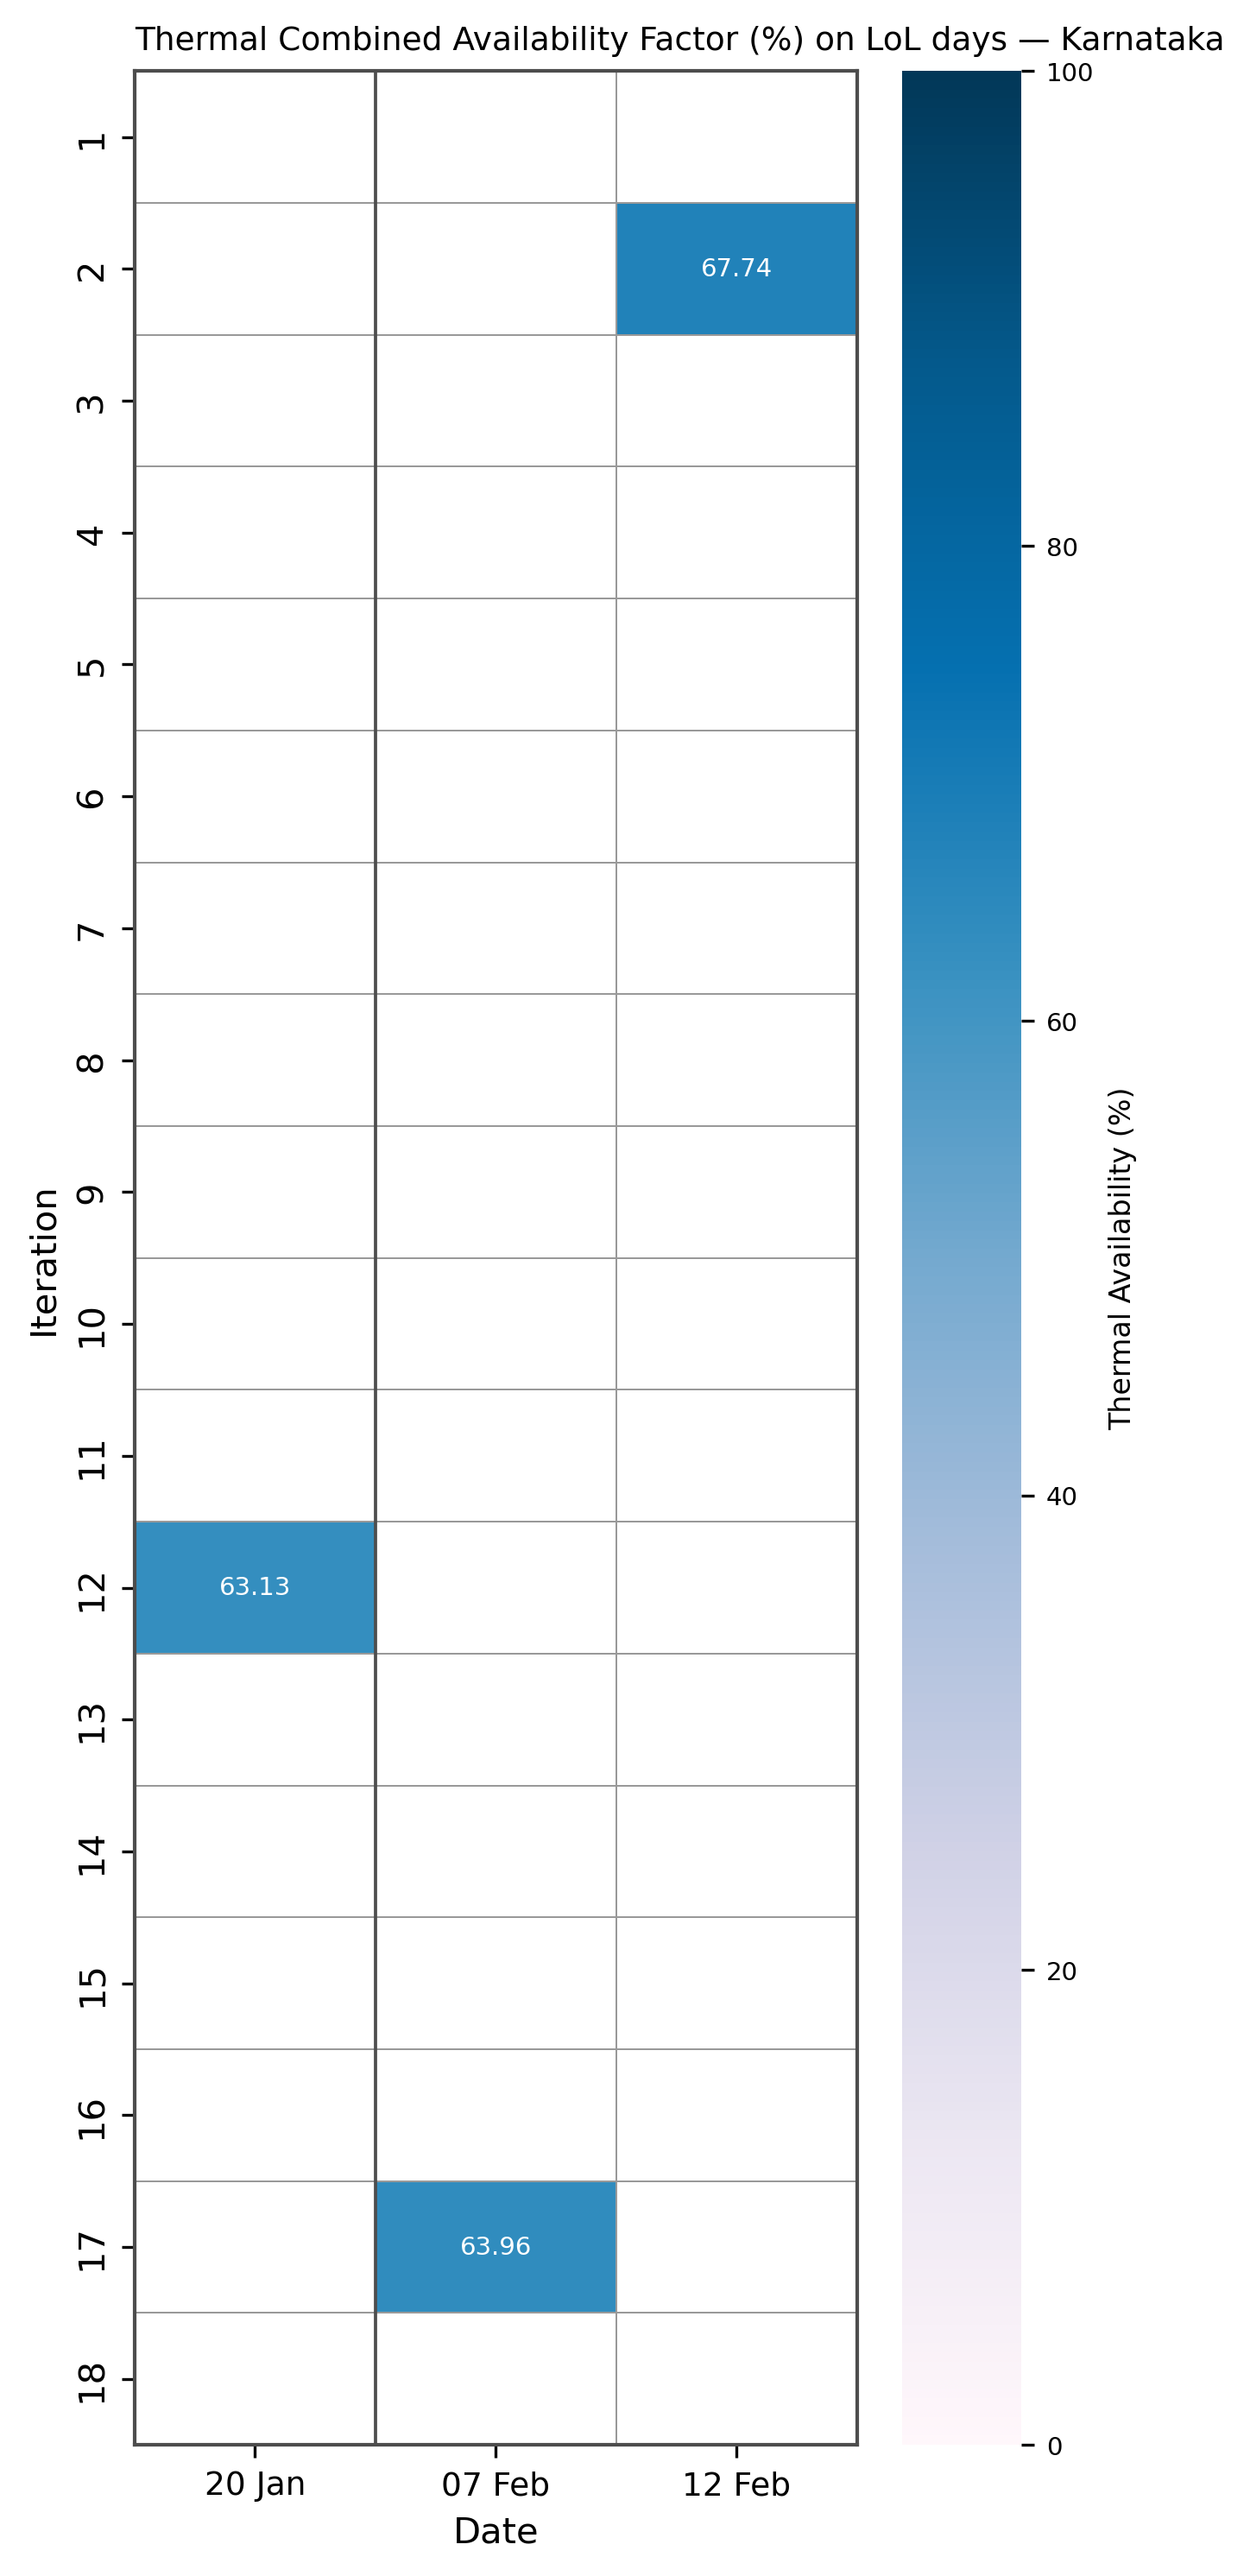

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt/Karnataka_03_Thermal_CAF_pct.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

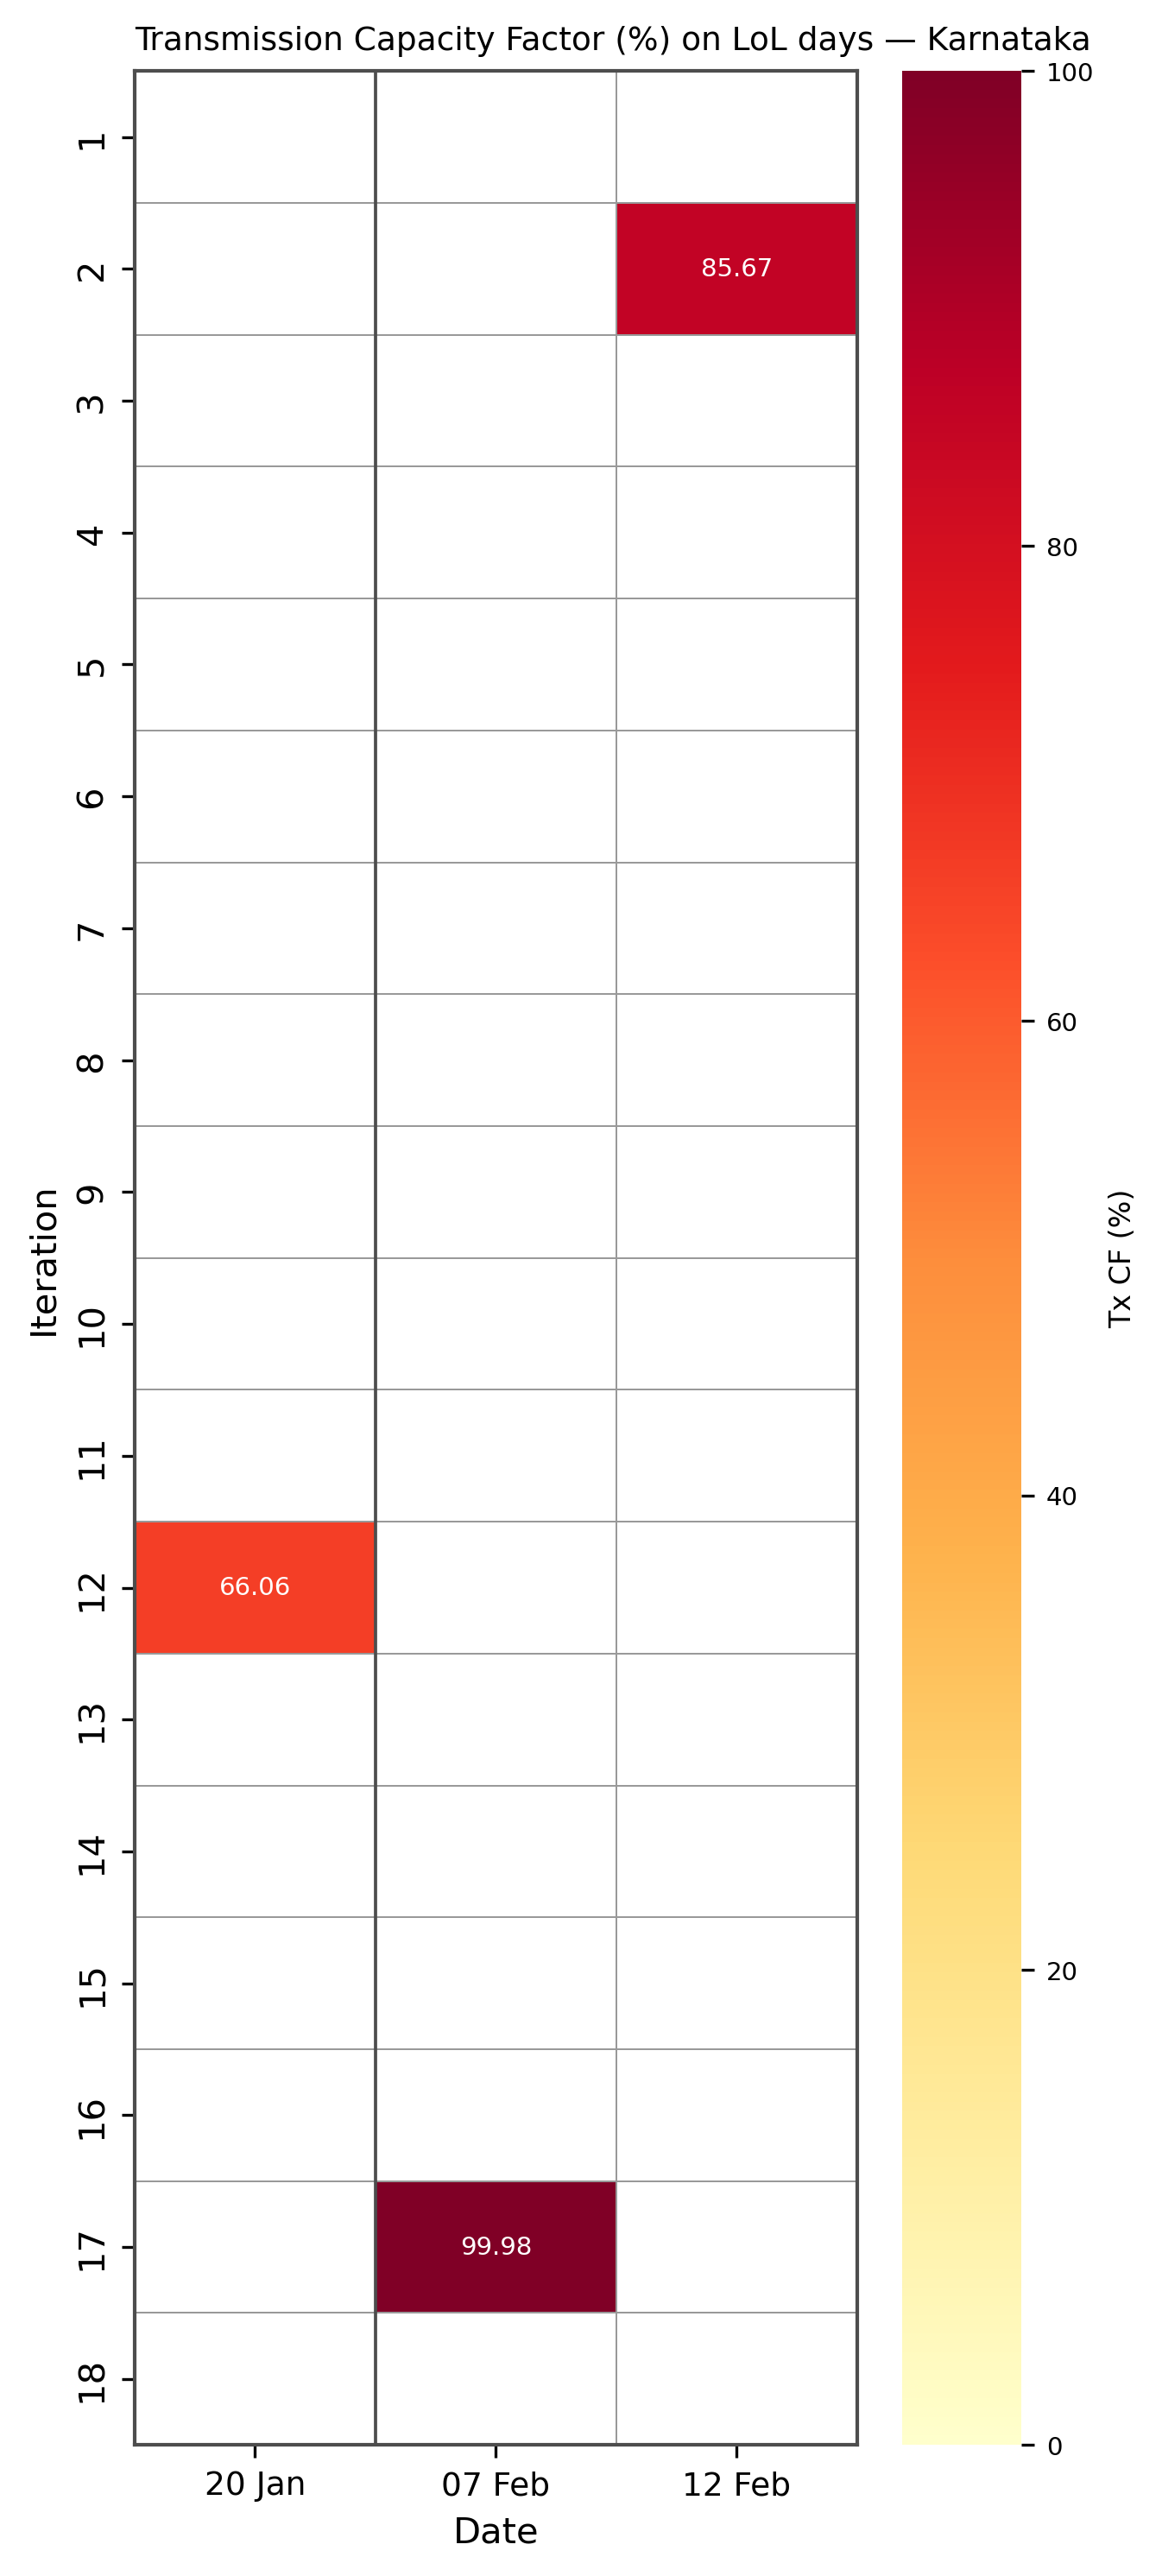

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt/Karnataka_04_Tx_CF_pct.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

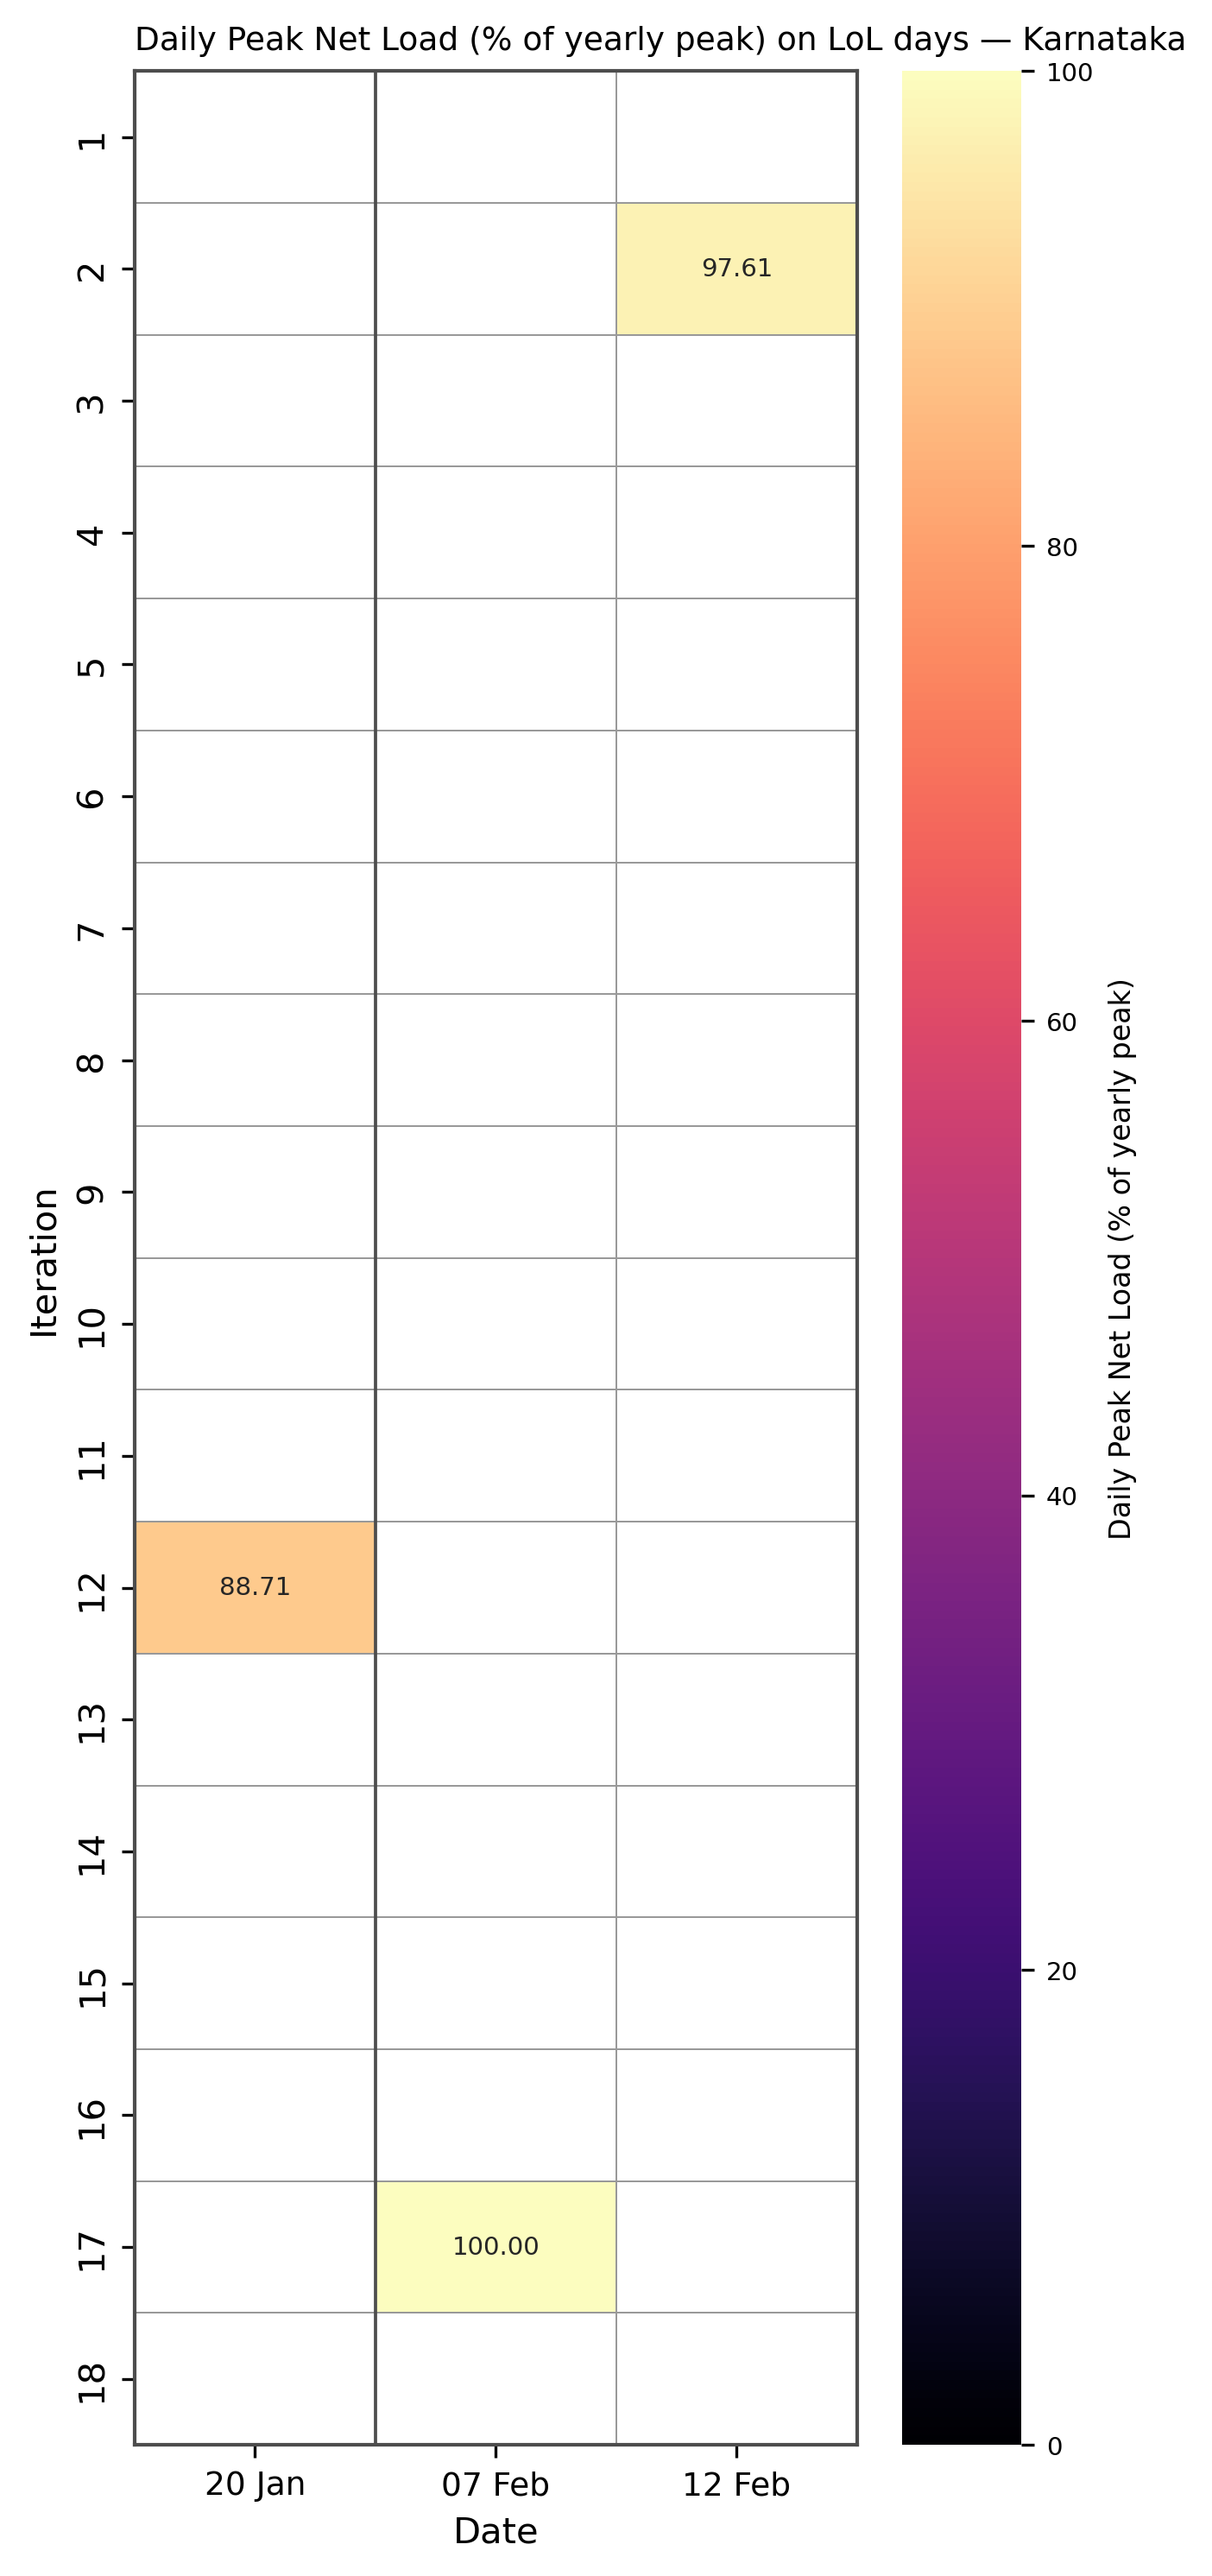

Saved: plots_for_ppt/Karnataka_05_Daily_Peak_NetLoad_pct.png


In [43]:
# ============================================
# Make the five story panels as SEPARATE PNGs
# ============================================
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({"font.family": "Arial", "font.size": 10})

def plot_lol_panels_separately(selected_zone,
                               plf_df,
                               df_load_,
                               df_dispatch_,
                               df_tx_zone,
                               fy=None,
                               outdir="plots_for_ppt",
                               always_annot=False,
                               annot_threshold_cells=700):
    """
    Requires your existing: build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy)
    Returns nothing; saves 5 PNGs (one per panel) with X-axis labels included.
    """
    # ---- get matrices & dates from your existing function ----
    iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    os.makedirs(outdir, exist_ok=True)

    # ---- x-axis tick formatting (day + month) ----
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # ---- month boundaries for vertical separators ----
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # ---- helper to draw one heatmap and save ----
    def _one(name, M, title, cmap, vmin, vmax, cbar_label, fmt=".2f", is_binary=False):
        # decide if we annotate values
        annotate = always_annot or ((M.shape[0] * M.shape[1]) <= annot_threshold_cells)
        mask = pd.isna(M) if not is_binary else (M.values == 0)  # for binary, hide 0s if we annotate

        # size scaled by number of days and iterations
        fig_w = min(34, 3 + 0.50 * M.shape[1])
        fig_h = max(4.0, 0.55 * M.shape[0] + 2.0)

        fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=300)

        line_kwargs = dict(linewidths=0.4, linecolor="0.6")
        hm = sns.heatmap(
            M, ax=ax,
            cmap=cmap, vmin=vmin, vmax=vmax,
            mask=mask if not is_binary else None,
            cbar=True, fmt=fmt,
            annot=annotate and not is_binary,  # numbers for non-binary panels only
            annot_kws={'fontsize': 7},
            **line_kwargs
        )

        # colorbar formatting
        cb = hm.collections[0].colorbar
        cb.set_label(cbar_label, rotation=90, fontsize=8)
        cb.ax.tick_params(labelsize=7)

        # titles, labels
        ax.set_title(f"{title} — {selected_zone}", loc='left', fontsize=9)
        ax.set_ylabel("Iteration")
        ax.set_xlabel("Date")
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)

        # month separators
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

        # box outlines (spines)
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_linewidth(1.0)
            s.set_color('0.3')

        # save
        fname = os.path.join(outdir, f"{selected_zone.replace(' ', '_')}_{name}.png")
        plt.savefig(fname, bbox_inches='tight', dpi=300)
        plt.show()
        print(f"Saved: {fname}")

    # --------- 1) LoL (binary 0/1) ----------
    # If you prefer a colorbar with 0/1, keep vmin=0,vmax=1; we don't annotate the cells for clarity
    _one(
        name="01_LoL_days",
        M=LoL.astype(float),                  # heatmap expects float
        title="Load-Shedding (LoL) Days",
        cmap=ListedColormap(['white', 'red']),
        vmin=0, vmax=1,
        cbar_label="LoL (0/1)",
        fmt=".0f",
        is_binary=True
    )

    # --------- 2) Wind+Solar CF (%) ----------
    _one(
        name="02_RE_CF_pct",
        M=RE_CF_pct, title="Wind+Solar Capacity Factor (%) on LoL days",
        cmap="Reds", vmin=0, vmax=100,
        cbar_label="RE CF (%)",
        fmt=".2f"
    )

    # --------- 3) Thermal CAF (%) ----------
    _one(
        name="03_Thermal_CAF_pct",
        M=CAF_pct, title="Thermal Combined Availability Factor (%) on LoL days",
        cmap="PuBu", vmin=0, vmax=100,
        cbar_label="Thermal Availability (%)",
        fmt=".2f"
    )

    # --------- 4) Transmission CF (%) ----------
    _one(
        name="04_Tx_CF_pct",
        M=TX_pct, title="Transmission Capacity Factor (%) on LoL days",
        cmap="YlOrRd", vmin=0, vmax=100,
        cbar_label="Tx CF (%)",
        fmt=".2f"
    )

    # --------- 5) Daily Peak Net Load (% of yearly peak) ----------
    _one(
        name="05_Daily_Peak_NetLoad_pct",
        M=PEAK_pct, title="Daily Peak Net Load (% of yearly peak) on LoL days",
        cmap="magma", vmin=0, vmax=100,
        cbar_label="Daily Peak Net Load (% of yearly peak)",
        fmt=".2f"
    )

# ==================
# EXAMPLE CALL
# ==================
# Assumes you already defined build_lol_only_mats(...) exactly as in your current notebook.
# Just run this call to produce five separate high‑res PNGs with x‑axis labels:
plot_lol_panels_separately(
    selected_zone=selected_zone,                 # e.g., "Karnataka"
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone, # your zone-level tx dataframe
    fy=FY,
    outdir="plots_for_ppt",                      # folder will be created if not present
    always_annot=False,                          # set True if you want numbers in every cell
    annot_threshold_cells=700                    # annotate only if matrix is not too large
)

In [44]:

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Keep fonts modest
plt.rcParams.update({"font.family": "Arial", "font.size": 8})

def plot_lol_panels_small(
    selected_zone,
    plf_df,
    df_load_,
    df_dispatch_,
    df_tx_zone,
    fy=None,
    outdir="plots_for_ppt_small",
    always_annot=False,          # keep False for clean small plots
    annot_threshold_cells=450,   # annotate only if matrix is small
    FIG_W_IN=5.0,
    FIG_H_IN=2.6,
    DPI=260
):
    """
    Uses your existing: build_lol_only_mats(...)
    Writes 5 compact PNGs with x-axis labels, ready for a single slide.
    """
    # ---- matrices & dates from your existing function ----
    iters, LoL, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    os.makedirs(outdir, exist_ok=True)

    # ---- x-axis tick formatting (day + short month) ----
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    # fewer labels to keep small plots readable
    max_labels = 10
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # ---- month separators ----
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    def _one(name, M, title, cmap, vmin, vmax, cbar_label, fmt=".2f", is_binary=False):
        # annotate only if small
        annotate = always_annot or ((M.shape[0] * M.shape[1]) <= annot_threshold_cells)
        mask = pd.isna(M) if not is_binary else None

        fig, ax = plt.subplots(1, 1, figsize=(FIG_W_IN, FIG_H_IN), dpi=DPI)
        line_kwargs = dict(linewidths=0.35, linecolor="0.6")

        hm = sns.heatmap(
            M, ax=ax,
            cmap=cmap, vmin=vmin, vmax=vmax,
            mask=mask,
            cbar=True, cbar_kws={"shrink":0.80, "pad":0.02},
            annot=annotate and not is_binary,
            fmt=fmt, annot_kws={'fontsize': 6},
            **line_kwargs
        )

        # colorbar label small
        cb = hm.collections[0].colorbar
        cb.set_label(cbar_label, rotation=90, fontsize=7)
        cb.ax.tick_params(labelsize=7)

        # tidy axes
        ax.set_title(f"{title} — {selected_zone}", loc='left', fontsize=8)
        ax.set_ylabel("Iteration", fontsize=8)
        ax.set_xlabel("Date", fontsize=8)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=7)
        ax.tick_params(axis='y', labelsize=7)

        # month separators
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.8)

        # box spines on
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_linewidth(0.9)
            s.set_color('0.3')

        plt.tight_layout()
        fname = os.path.join(outdir, f"{selected_zone.replace(' ', '_')}_{name}.png")
        plt.savefig(fname, bbox_inches='tight', dpi=DPI)
        plt.close(fig)
        print(f"Saved: {fname}")

    # -------- 1) LoL (binary 0/1) ----------
    _one(
        name="01_LoL_days",
        M=LoL.astype(float),
        title="Load-Shedding (LoL) Days",
        cmap=ListedColormap(['white','red']),
        vmin=0, vmax=1,
        cbar_label="LoL (0/1)",
        fmt=".0f",
        is_binary=True
    )

    # -------- 2) Wind+Solar CF (%) ----------
    _one(
        name="02_RE_CF_pct",
        M=RE_CF_pct,
        title="Wind+Solar Capacity Factor (%) on LoL days",
        cmap="Reds", vmin=0, vmax=100,
        cbar_label="RE CF (%)",
        fmt=".2f"
    )

    # -------- 3) Thermal CAF (%) ----------
    _one(
        name="03_Thermal_CAF_pct",
        M=CAF_pct,
        title="Thermal Combined Availability Factor (%) on LoL days",
        cmap="PuBu", vmin=0, vmax=100,
        cbar_label="Thermal Availability (%)",
        fmt=".2f"
    )

    # -------- 4) Transmission CF (%) ----------
    _one(
        name="04_Tx_CF_pct",
        M=TX_pct,
        title="Transmission Capacity Factor (%) on LoL days",
        cmap="YlOrRd", vmin=0, vmax=100,
        cbar_label="Tx CF (%)",
        fmt=".2f"
    )

    # -------- 5) Daily Peak Net Load (% of yearly peak) ----------
    _one(
        name="05_Daily_Peak_NetLoad_pct",
        M=PEAK_pct,
        title="Daily Peak Net Load (% of yearly peak) on LoL days",
        cmap="magma", vmin=0, vmax=100,
        cbar_label="Daily Peak Net Load (% of yearly peak)",
        fmt=".2f"
    )

# ==================
# Example call (uses your existing build_lol_only_mats)
# ==================
plot_lol_panels_small(
    selected_zone=selected_zone,                 # e.g., "Karnataka"
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    outdir="plots_for_ppt_small",                # small images saved here
    always_annot=False,                          # keep cells clean for small figs
    annot_threshold_cells=450,                   # annotate only if matrix is small
    FIG_W_IN=5.0, FIG_H_IN=2.6, DPI=260         # <-- tweak these to make even smaller/larger
)

/tmp/ipykernel_4143588/2168019167.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

Saved: plots_for_ppt_small/Karnataka_01_LoL_days.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt_small/Karnataka_02_RE_CF_pct.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt_small/Karnataka_03_Thermal_CAF_pct.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt_small/Karnataka_04_Tx_CF_pct.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved: plots_for_ppt_small/Karnataka_05_Daily_Peak_NetLoad_pct.png


# Undergeneration and overgeneration heatmap

In [31]:
df_overgen = df_dispatch_.copy()
df_overgen = df_overgen[['timestamp','load_zone','curtailment_mw']]
df_overgen = df_overgen.groupby(['timestamp']).agg({'curtailment_mw': 'mean'}).reset_index(drop = False)

df_load_shedding = df_load_.copy()
df_load_shedding = df_load_shedding[['timestamp','load_zone','unserved_energy']]
df_load_shedding = df_load_shedding.groupby(['timestamp']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df_overgen_final = pd.merge(df_overgen, df_load_shedding, on = 'timestamp', how = 'outer')
df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

In [32]:
# df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

# # Extract month and hour
# df_overgen_final['month'] = df_overgen_final['timestamp'].dt.month
# df_overgen_final['hour']  = df_overgen_final['timestamp'].dt.hour + 1  # to get 1–24

# # Build pivot table: sum of residuals by hour (rows) and month (columns)
# pivot_table = df_overgen_final.pivot_table(
#     values='residual',
#     index='hour',
#     columns='month',
#     aggfunc='sum'
# )


# # Determine max absolute residual for symmetric color scaling
# max_abs = np.abs(pivot_table.values).max()

# # Plot heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(
#     pivot_table,
#     cmap='RdBu_r',    # reversed so negatives = red, positives = blue
#     center=0,         # zero maps to white
#     vmin=-max_abs,    # symmetric around zero
#     vmax= max_abs,
#     annot=False,
#     fmt=".1f"
# )

# # Labels and titles
# plt.xlabel('Month', fontsize=14)
# plt.ylabel('Hour of the Day', fontsize=14)
# plt.title('Heatmap of Residual (Curtailment − Unserved Energy)', fontsize=16)

# # Set month abbreviations on x-axis
# plt.xticks(
#     ticks=np.arange(0.5, 12.5),
#     labels=[calendar.month_abbr[i] for i in range(1, 13)],
#     rotation=45
# )
# plt.yticks(fontsize = 10)

# plt.tight_layout()
# plt.show()

nan nan


ValueError: cannot convert float NaN to integer

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

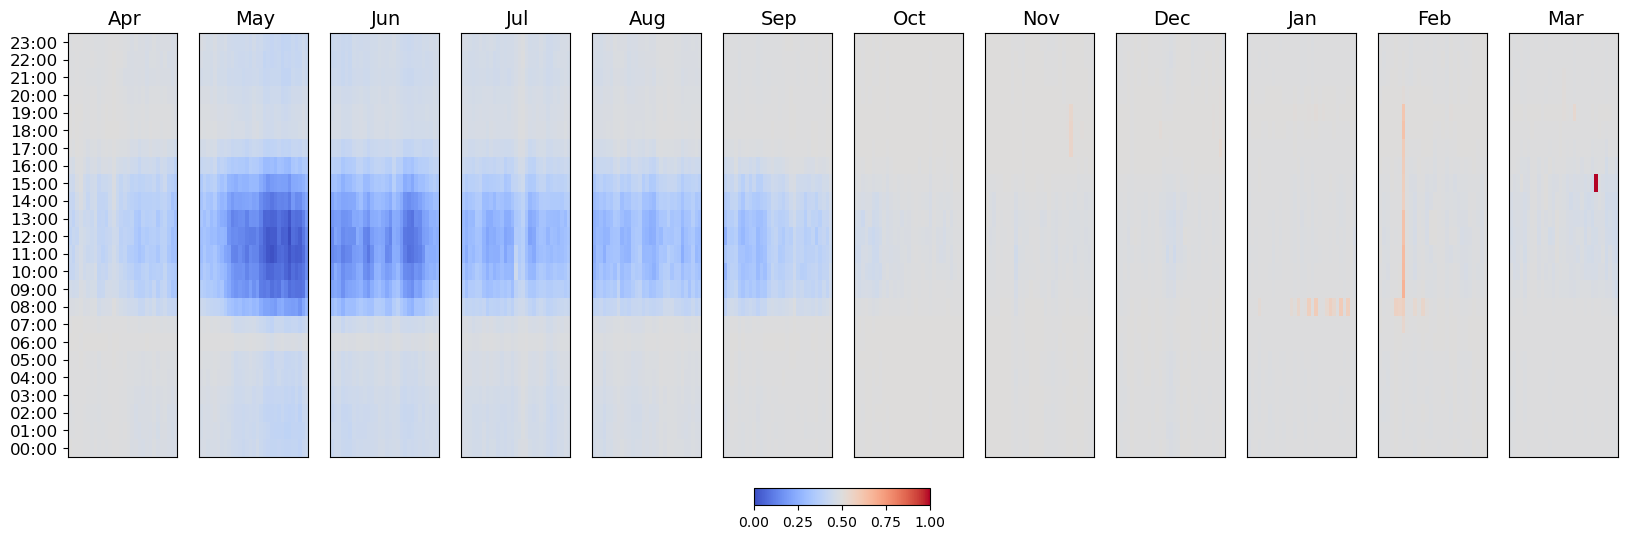

In [33]:
def _expected_unserved_energy(ax_, EUE_, EOE_): 

    units = 1e3

    N_years = 18
    N_hours = 24
    N_days  = 365

    month_days_     = np.array([0, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31])
    months_         = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
    cum_month_days_ = np.cumsum(month_days_)
    
    EUE_ = np.stack([EUE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EOE_ = np.stack([EOE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EUE_ = (EOE_ - EUE_)/units
    print(EUE_.min(), EUE_.max())

    idx_under_ = EUE_ > 0
    idx_over_  = EUE_ <= 0
    norm_EUE_ = np.zeros(EUE_.shape)

    norm_EUE_[idx_under_] = EUE_[idx_under_]/EUE_[idx_under_].max()
    norm_EUE_[idx_over_]  = -EUE_[idx_over_]/EUE_[idx_over_].min()

    hours_ = np.arange(datetime(2036, 1, 1, 0), datetime(2036, 1, 2, 0), timedelta(days = 1/24)).astype(datetime)
    hours_ = pd.to_datetime(hours_).strftime('%H:%M')

    _cmap = sns.color_palette("coolwarm", as_cmap=True)

    for i in range(12):
        ax_[i].imshow(norm_EUE_[cum_month_days_[i]:cum_month_days_[i + 1], :].T, 
                      origin        = 'lower', 
                      vmin          = -1.,
                      vmax          = 1,
                      aspect        = 'auto', 
                      cmap          = _cmap,
                      interpolation = 'None')
        
        ax_[i].set_xticks([month_days_[i + 1]/2], [months_[i]], fontsize = 14)
        ax_[i].tick_params(axis = "x", length = 0)
        ax_[i].set_yticks([], [])
        ax_[i].xaxis.tick_top()

    ax_[0].set_yticks(np.linspace(0, 23, 24), hours_, fontsize = 12)

    cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                        cax = ax_[5].inset_axes([-215, -3.25, 50., 1.], transform = ax_[-1].transData), 
                        orientation = 'horizontal')

    cbar.set_ticks([0, 1], labels = [f'{-int(EUE_.max())} (GWh)', f'{-int(EUE_.min())} (GWh)'], size = 10)
    
    #cbar.ax.tick_params(length = 0)
    cbar.ax.set_title('Curtailment/Unserved Energy', rotation = 0, size = 12)
    

Shed_    = df_overgen_final['curtailment_mw'].to_numpy()
Curtail_ = df_overgen_final['unserved_energy'].to_numpy()

fig_, ax_ = plt.subplots(figsize = (20, 5.5), 
                         nrows = 1,
                         ncols = 12)

_expected_unserved_energy(ax_, Shed_, Curtail_)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.pdf', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show() 

In [ ]:

plf_threshold = 0.025    # your existing low PLF cut
k_consec      = 2        # drought = >=k consecutive low-PLF days

# -----------------------------
# 1) Build a clean daily master
# -----------------------------
# Base: from plf_df
base = plf_df.copy()
base['date'] = pd.to_datetime(base['date']).dt.normalize()
for c in ['load_zone','W','H','A']:
    base[c] = base[c].astype(str)

# Daily net load (peak & sum) from netload_df
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    nl[c] = nl[c].astype(str)

daily_netload = (
    nl.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
      .agg(daily_peak_netload_mw='max', daily_netload_mwh='sum')   # 1h steps → sum(MW)=MWh
)

# Daily unserved energy & flag from df_load_
ls = df_load_.copy()
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, 'h')

ls['date'] = ls['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    ls[c] = ls[c].astype(str)

ls_daily = (
    ls.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy':'load_shedding_mwh'})
)
ls_daily['load_shedding_flag'] = (ls_daily['load_shedding_mwh'] > 0).astype('int8')

# Merge all into one daily table
daily = (base[['load_zone','W','H','A','date','plf','low_plf_flag','net_load','load_shedding']]
         .merge(daily_netload, on=['load_zone','W','H','A','date'], how='left')
         .merge(ls_daily,     on=['load_zone','W','H','A','date'], how='left'))

# Fill safe defaults
daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']] = \
    daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']].fillna(0)
daily['load_shedding_flag'] = daily['load_shedding_flag'].fillna(0).astype('int8')

# -----------------------------
# 2) Drought definition: >=k consecutive low-PLF days (per zone, W,H,A)
# -----------------------------
daily = daily.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)

def consec_flag(s, k):
    # rolling count of low-PLF days; mark 1 if current and previous k-1 are low
    return (s.rolling(window=k, min_periods=k).sum() >= k).astype('int8')

daily['drought_k'] = (
    daily.groupby(['load_zone','W','H','A'])['low_plf_flag']
         .transform(lambda x: consec_flag(x, k_consec))
)

# -----------------------------
# 3) Expected EUE (per zone, W,H,A) & ratios
# -----------------------------
# Expected EUE over the analysis window
expected_eue = (daily.groupby(['load_zone','W','H','A'], as_index=False)['load_shedding_mwh']
                      .sum()
                      .rename(columns={'load_shedding_mwh':'expected_eue_mwh'}))

daily = daily.merge(expected_eue, on=['load_zone','W','H','A'], how='left')
daily['expected_eue_mwh'] = daily['expected_eue_mwh'].fillna(0)

# Ratio: daily EUE as share of expected EUE
daily['load_shedding_eue'] = np.where(
    daily['expected_eue_mwh'] > 0,
    daily['load_shedding_mwh'] / daily['expected_eue_mwh'],
    np.nan
)

# -----------------------------
# 4) Ratio to “top net load” reference
# -----------------------------
# Define per-combo max of the top-5 daily peaks (your earlier convention)
top5_max = (daily.sort_values(['load_zone','W','H','A','daily_peak_netload_mw'], ascending=[True,True,True,True,False])
                 .groupby(['load_zone','W','H','A'], as_index=False).head(5)
                 .groupby(['load_zone','W','H','A'], as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'}))

daily = daily.merge(top5_max, on=['load_zone','W','H','A'], how='left')
daily['load_shedding_top_net_load'] = np.where(
    daily['top_netload_max_mw'] > 0,
    daily['load_shedding_mwh'] / daily['top_netload_max_mw'],
    np.nan
)


# A) Enrichment: share of top net-load days that are drought vs baseline drought rate
top_net = daily[daily['net_load'] == 1]
baseline_drought_rate = daily['drought_k'].mean()
enriched_share = top_net['drought_k'].mean() if not top_net.empty else np.nan

# B) Net-load uplift on drought days
uplift = (daily.groupby('drought_k')['daily_peak_netload_mw'].mean()
                .rename({0:'non_drought_mean_mw', 1:'drought_mean_mw'}))
uplift_diff = uplift.get('drought_mean_mw', np.nan) - uplift.get('non_drought_mean_mw', np.nan)

# C) Loss-of-load risk ratio
p_ls_drought    = daily.loc[daily['drought_k']==1, 'load_shedding_flag'].mean() if (daily['drought_k']==1).any() else np.nan
p_ls_non        = daily.loc[daily['drought_k']==0, 'load_shedding_flag'].mean() if (daily['drought_k']==0).any() else np.nan
risk_ratio_ls   = (p_ls_drought / p_ls_non) if (p_ls_drought==p_ls_drought and p_ls_non and p_ls_non>0) else np.nan

# D) Share of EUE occurring during droughts
share_eue_drought = (daily.loc[daily['drought_k']==1, 'load_shedding_mwh'].sum() /
                     daily['load_shedding_mwh'].sum()) if daily['load_shedding_mwh'].sum()>0 else np.nan


print(f"Baseline drought rate (all days): {baseline_drought_rate:.2%}")
print(f"Share of TOP net-load days in drought: {enriched_share:.2%}")
print(f"Net-load uplift (drought − non): {uplift_diff:.1f} MW")
print(f"Loss-of-load risk ratio (drought vs non): {risk_ratio_ls:.2f}")
print(f"Share of EUE in drought days: {share_eue_drought:.2%}")




Baseline drought rate (all days): 1.76%
Share of TOP net-load days in drought: 1.88%
Net-load uplift (drought − non): -11429.3 MW
Loss-of-load risk ratio (drought vs non): 0.00
Share of EUE in drought days: 0.00%


In [ ]:

k_consec = 2   # drought = >= k consecutive low-PLF days

# =====================
# 0) DAILY MASTER (per load_zone, W, H, A)
# =====================
# Start from plf_df (already has: plf, low_plf_flag, net_load, load_shedding)
daily = plf_df.copy()
daily['date'] = pd.to_datetime(daily['date']).dt.normalize()
for c in ['load_zone','W','H','A']:
    daily[c] = daily[c].astype(str)

# Daily net load (peak + energy) from netload_df
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    nl[c] = nl[c].astype(str)

daily_netload = (
    nl.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
      .agg(daily_peak_netload_mw='max', daily_netload_mwh='sum')  # 1h steps → sum(MW)=MWh
)

# Daily unserved energy from df_load_
ls = df_load_.copy()
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, 'h')

ls['date'] = ls['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    ls[c] = ls[c].astype(str)

ls_daily = (
    ls.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy':'load_shedding_mwh'})
)
ls_daily['load_shedding_flag'] = (ls_daily['load_shedding_mwh'] > 0).astype('int8')

# Merge into one daily table (per zone, W, H, A, date)
daily = (daily
         .merge(daily_netload, on=['load_zone','W','H','A','date'], how='left')
         .merge(ls_daily,     on=['load_zone','W','H','A','date'], how='left'))

# Fill safe defaults
daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']] = \
    daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']].fillna(0)
daily['load_shedding_flag'] = daily['load_shedding_flag'].fillna(0).astype('int8')

# =====================
# 1) DROUGHT FLAG (>= k consecutive low-PLF days) per combo
# =====================
daily = daily.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)

def consec_flag(s, k):
    # marks 1 when the current day and previous k-1 days are low-PLF
    return (s.rolling(window=k, min_periods=k).sum() >= k).astype('int8')

daily['drought_k'] = (
    daily.groupby(['load_zone','W','H','A'])['low_plf_flag']
         .transform(lambda x: consec_flag(x, k_consec))
)

# =====================
# 2) EXPECTED EUE per combo + daily ratio columns
# =====================
# Expected EUE over the (filtered) window per combo
expected_eue = (daily.groupby(['load_zone','W','H','A'], as_index=False)['load_shedding_mwh']
                      .sum()
                      .rename(columns={'load_shedding_mwh':'expected_eue_mwh'}))

daily = daily.merge(expected_eue, on=['load_zone','W','H','A'], how='left')
daily['expected_eue_mwh'] = daily['expected_eue_mwh'].fillna(0)

# Ratio: daily EUE as share of expected EUE
daily['load_shedding_eue'] = np.where(
    daily['expected_eue_mwh'] > 0,
    daily['load_shedding_mwh'] / daily['expected_eue_mwh'],
    np.nan
)

# Max of TOP-5 daily peak net load per combo (denominator for your 3rd column)
top5_max = (daily.sort_values(['load_zone','W','H','A','daily_peak_netload_mw'],
                              ascending=[True,True,True,True,False])
                 .groupby(['load_zone','W','H','A'], as_index=False).head(5)
                 .groupby(['load_zone','W','H','A'], as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'}))

daily = daily.merge(top5_max, on=['load_zone','W','H','A'], how='left')

# Ratio: daily EUE relative to top net load (MW)
daily['load_shedding_top_net_load'] = np.where(
    daily['top_netload_max_mw'] > 0,
    daily['load_shedding_mwh'] / daily['top_netload_max_mw'],
    np.nan
)

# =====================
# 3) PER-(load_zone, W, H, A) SUMMARY (research-style metrics)
# =====================
def summarize_combo(g):
    n_days = len(g)
    # baseline drought frequency
    baseline = g['drought_k'].mean()
    # share of TOP net-load days (net_load=1) that are drought days
    top = g[g['net_load']==1]
    enriched = top['drought_k'].mean() if len(top) else np.nan
    # net-load uplift during drought
    means = g.groupby('drought_k')['daily_peak_netload_mw'].mean()
    uplift = means.get(1, np.nan) - means.get(0, np.nan)
    # loss-of-load risk ratio
    p_d = g.loc[g['drought_k']==1, 'load_shedding_flag'].mean() if (g['drought_k']==1).any() else np.nan
    p_n = g.loc[g['drought_k']==0, 'load_shedding_flag'].mean() if (g['drought_k']==0).any() else np.nan
    rr  = (p_d / p_n) if (p_n and p_n>0) else np.nan
    # share of EUE during drought days
    eue_total = g['load_shedding_mwh'].sum()
    share_eue = (g.loc[g['drought_k']==1, 'load_shedding_mwh'].sum() / eue_total) if eue_total>0 else np.nan
    # denominators (helpful context)
    expected_eue = g['expected_eue_mwh'].iloc[0] if 'expected_eue_mwh' in g else np.nan
    top5_max = g['top_netload_max_mw'].iloc[0] if 'top_netload_max_mw' in g else np.nan

    return pd.Series({
        'n_days': n_days,
        'baseline_drought_rate': baseline,
        'enriched_share_top_netload': enriched,
        'netload_uplift_mw': uplift,
        'loss_shedding_risk_ratio': rr,
        'share_EUE_in_drought': share_eue,
        'expected_eue_mwh': expected_eue,
        'top_netload_max_mw': top5_max,
    })

summary_by_combo = (daily
    .groupby(['load_zone','W','H','A'], as_index=False)
    .apply(lambda g: summarize_combo(g))
    .reset_index(drop=True)
)

# =====================
# OUTPUTS
# =====================
# daily: per-day analysis with drought_k, expected_eue_mwh, load_shedding_eue,
#        top_netload_max_mw, load_shedding_top_net_load (all per load_zone,W,H,A)
# summary_by_combo: one row per (load_zone, W, H, A) with research metrics


/tmp/ipykernel_1796817/1530091938.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_combo = (daily


#RA Dashboard

/tmp/ipykernel_1807008/310270382.py:134: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_combo = (daily
/tmp/ipykernel_1807008/310270382.py:159: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_zone = (summary_by_combo


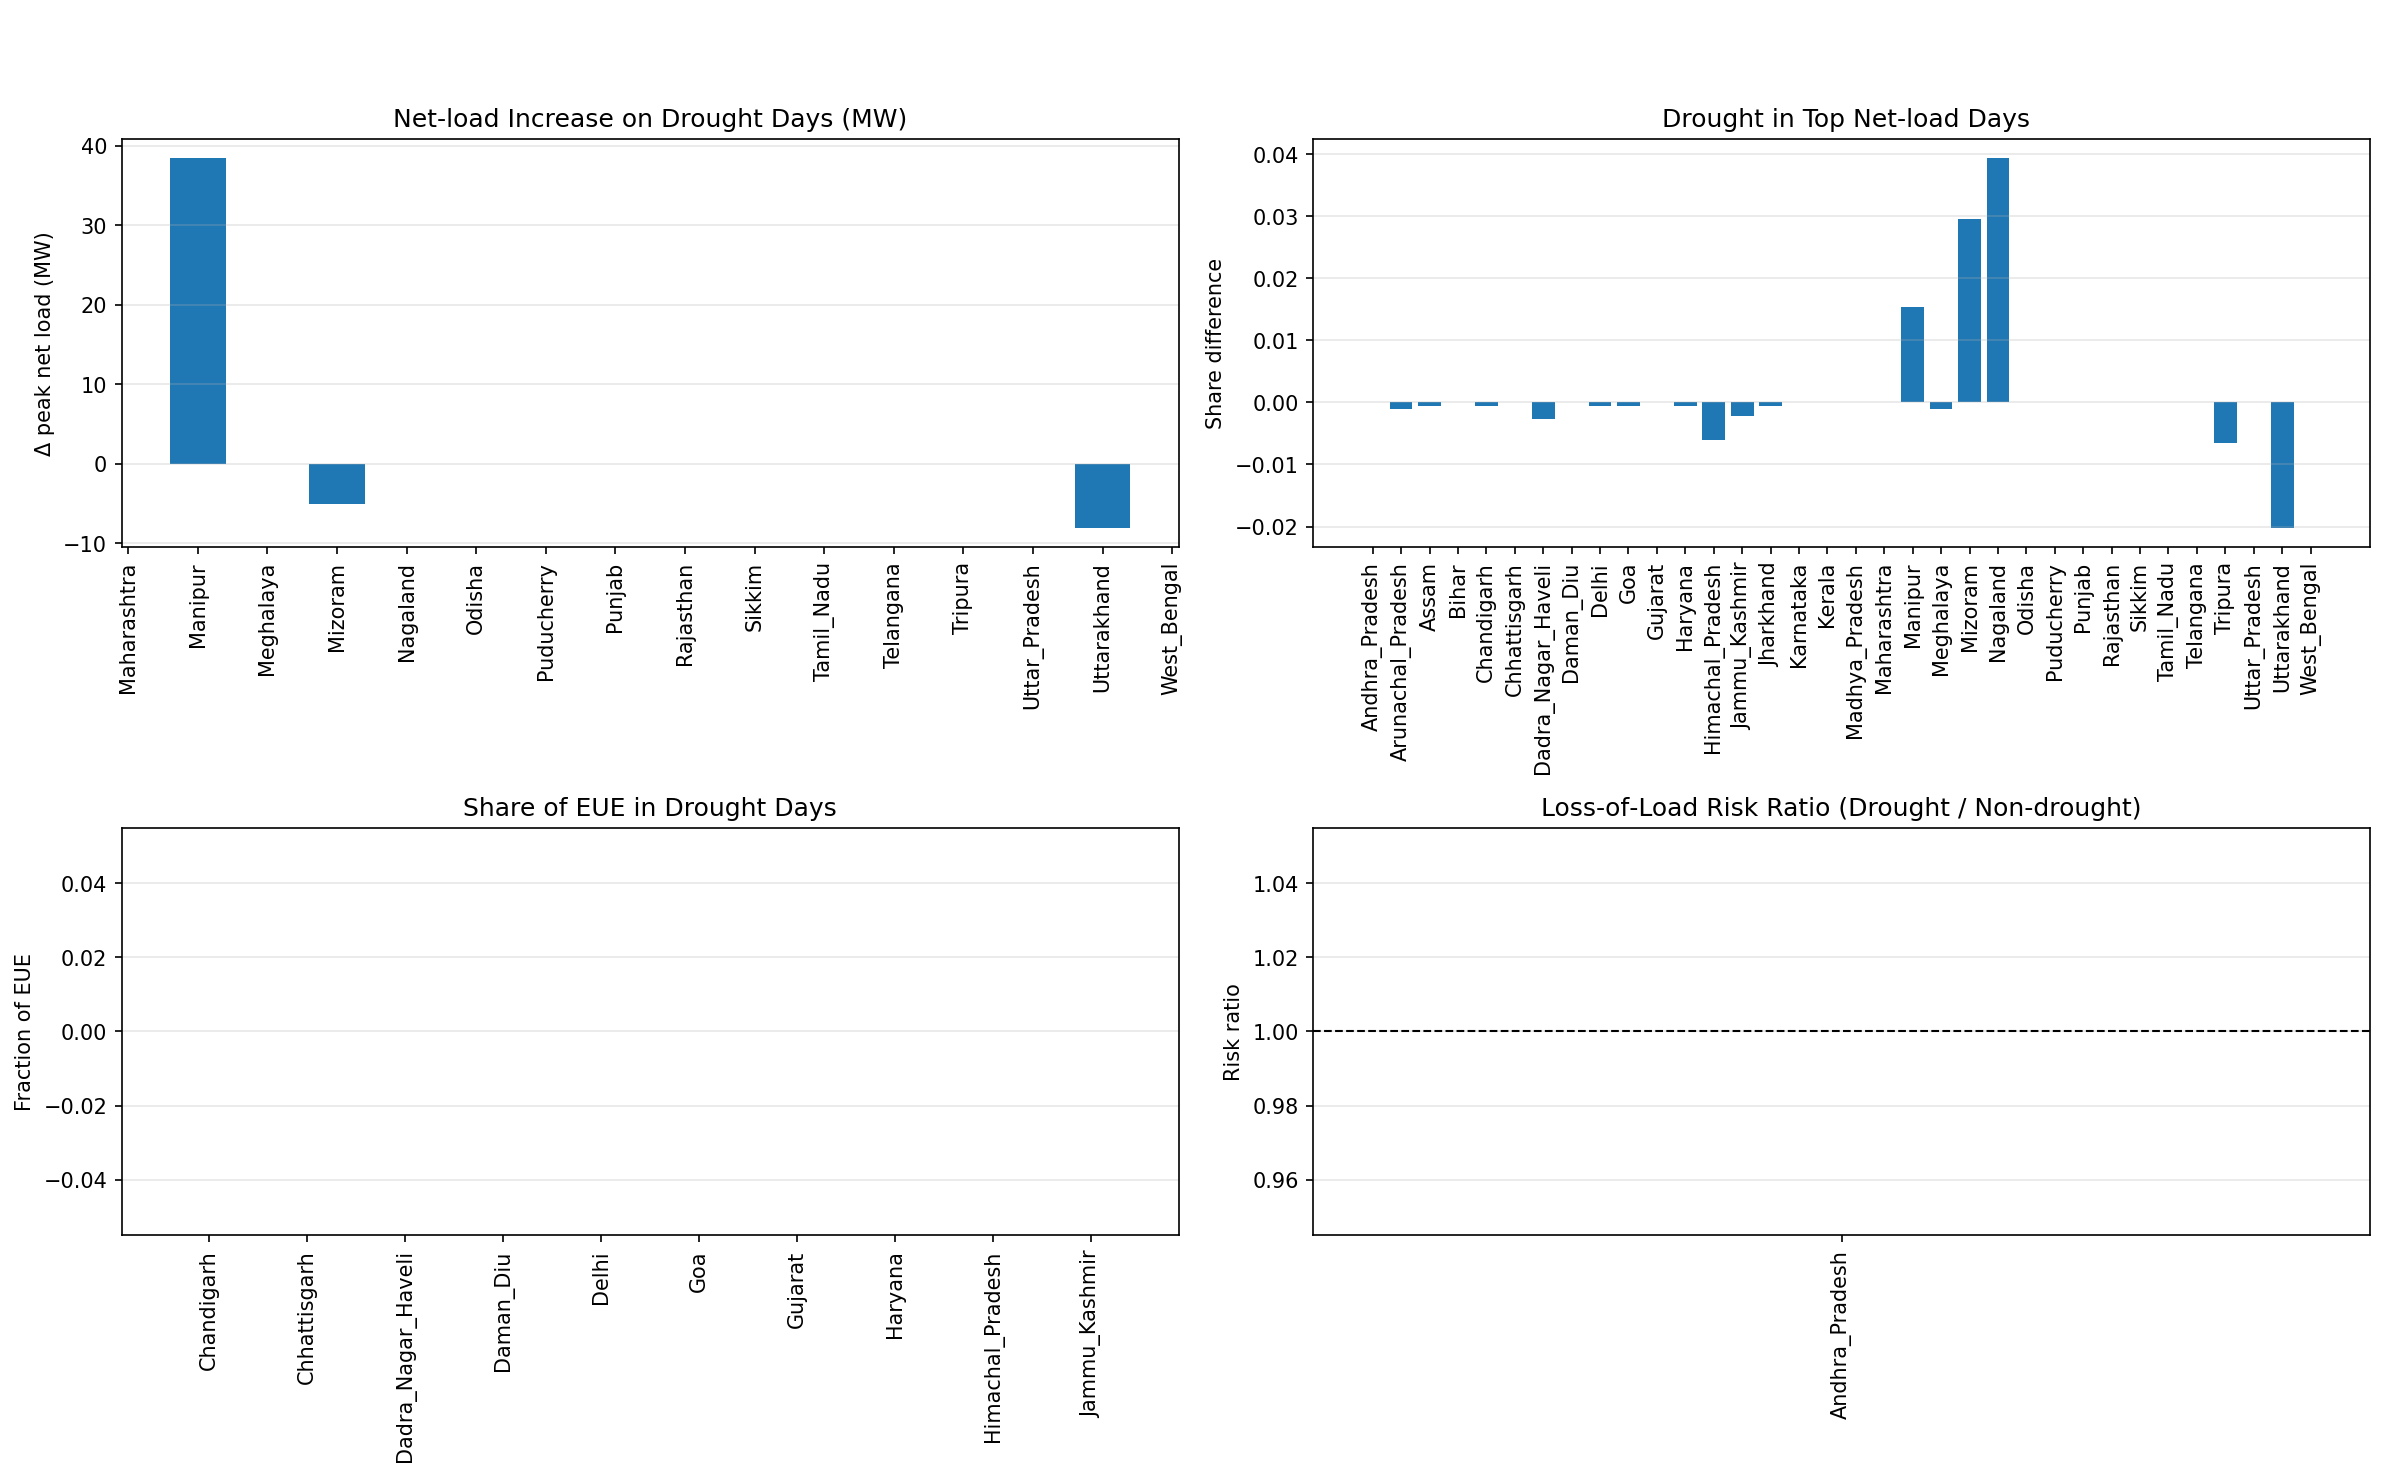

,load_zone,netload_uplift_mw,loss_shedding_risk_ratio,enriched_share_top_netload,baseline_drought_rate,share_EUE_in_drought
19,Manipur,38.501167,NaN,0.08,0.064658,NaN
21,Mizoram,-5.095593,NaN,0.52,0.490411,NaN
32,Uttarakhand,-8.114489,NaN,0.00,0.020274,NaN
0,Andhra_Pradesh,NaN,NaN,0.00,0.000000,NaN
1,Arunachal_Pradesh,NaN,NaN,0.00,0.001096,NaN
2,Assam,NaN,NaN,0.00,0.000548,NaN
3,Bihar,NaN,NaN,0.00,0.000000,NaN
4,Chandigarh,NaN,NaN,0.00,0.000548,0.0
5,Chhattisgarh,NaN,NaN,0.00,0.000000,NaN
6,Dadra_Nagar_Haveli,NaN,NaN,0.00,0.002740,0.0


In [ ]:

K_CONSEC_DROUGHT = 2     # drought = >=k consecutive low-PLF days
TOPK_NETLOAD     = 5     # "top net-load" days per (zone, W, H, A)
PLF_THRESHOLD    = 0.025 # used only if low_plf_flag missing
SAVE_PREFIX      = None  # e.g., "outputs/ra_dashboard" to save CSVs & PNG

# =========================
# 0) DAILY MASTER (per load_zone, W, H, A, date)
# =========================
def build_daily_master(plf_df, netload_df, df_load_):
    d = plf_df.copy()
    d['date'] = pd.to_datetime(d['date']).dt.normalize()
    for c in ['load_zone','W','H','A']:
        d[c] = d[c].astype(str)

    # Ensure low_plf_flag exists (fallback on PLF threshold)
    if 'low_plf_flag' not in d.columns:
        d['low_plf_flag'] = (d['plf'] < PLF_THRESHOLD).astype('int8')

    # --- Net load (peak & energy per day)
    nl = netload_df.copy()
    nl['timestamp'] = pd.to_datetime(nl['timestamp'])
    nl['date'] = nl['timestamp'].dt.normalize()
    for c in ['load_zone','W','H','A']:
        nl[c] = nl[c].astype(str)

    daily_netload = (
        nl.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
          .agg(daily_peak_netload_mw='max', daily_netload_mwh='sum') # 1h steps → sum(MW)=MWh
    )

    # --- Unserved energy per day
    ls = df_load_.copy()
    if 'timestamp' not in ls.columns:
        tp = ls['timepoint'].astype(str)
        d0 = pd.to_datetime(tp.str[:8], format='%Y%m%d')
        h0 = tp.str[8:].astype(int)  # 1..24
        ls['timestamp'] = d0 + pd.to_timedelta(h0 - 1, 'h')
    ls['date'] = ls['timestamp'].dt.normalize()
    for c in ['load_zone','W','H','A']:
        ls[c] = ls[c].astype(str)

    ls_daily = (
        ls.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
          .sum()
          .rename(columns={'unserved_energy':'load_shedding_mwh'})
    )
    ls_daily['load_shedding_flag'] = (ls_daily['load_shedding_mwh'] > 0).astype('int8')

    # --- Merge all
    daily = (d[['load_zone','W','H','A','date','plf','low_plf_flag']]
             .merge(daily_netload, on=['load_zone','W','H','A','date'], how='left')
             .merge(ls_daily,     on=['load_zone','W','H','A','date'], how='left'))

    daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']] = \
        daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']].fillna(0)
    daily['load_shedding_flag'] = daily['load_shedding_flag'].fillna(0).astype('int8')

    # --- Drought flag: >=K consecutive low-PLF days (per combo)
    daily = daily.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)

    def consec_flag(s, k):
        return (s.rolling(window=k, min_periods=k).sum() >= k).astype('int8')

    daily['drought_k'] = (
        daily.groupby(['load_zone','W','H','A'])['low_plf_flag']
             .transform(lambda x: consec_flag(x, K_CONSEC_DROUGHT))
    )

    # --- Expected EUE per combo (over this window)
    expected_eue = (daily.groupby(['load_zone','W','H','A'], as_index=False)['load_shedding_mwh']
                          .sum()
                          .rename(columns={'load_shedding_mwh':'expected_eue_mwh'}))
    daily = daily.merge(expected_eue, on=['load_zone','W','H','A'], how='left')

    # --- Top-K net-load days per combo (by daily peak MW)
    daily['rank_peak'] = (
        daily.groupby(['load_zone','W','H','A'])['daily_peak_netload_mw']
             .rank(ascending=False, method='first')
    )
    daily['top_netload_flag'] = (daily['rank_peak'] <= TOPK_NETLOAD).astype('int8')

    # --- Max of the Top-K peaks per combo (denominator for one RA metric)
    topk_max = (daily[daily['top_netload_flag']==1]
                .groupby(['load_zone','W','H','A'], as_index=False)['daily_peak_netload_mw']
                .max()
                .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'}))
    daily = daily.merge(topk_max, on=['load_zone','W','H','A'], how='left')

    # --- Ratios used downstream (leave NaN when denom==0)
    daily['load_shedding_eue'] = np.where(
        daily['expected_eue_mwh'] > 0,
        daily['load_shedding_mwh'] / daily['expected_eue_mwh'],
        np.nan
    )
    daily['load_shedding_top_net_load'] = np.where(
        daily['top_netload_max_mw'] > 0,
        daily['load_shedding_mwh'] / daily['top_netload_max_mw'],
        np.nan
    )
    return daily

daily = build_daily_master(plf_df, netload_df, df_load_)

# =========================
# 1) SUMMARY BY (load_zone, W, H, A)
# =========================
def summarize_combo(df):
    g = df
    n_days = len(g)
    # baseline drought frequency & enriched share on Top-K net-load days
    baseline = g['drought_k'].mean()
    enriched = g.loc[g['top_netload_flag']==1, 'drought_k'].mean() if (g['top_netload_flag']==1).any() else np.nan
    # net-load uplift (drought − non)
    means = g.groupby('drought_k')['daily_peak_netload_mw'].mean()
    uplift = means.get(1, np.nan) - means.get(0, np.nan)
    # loss-of-load risk ratio
    p_d = g.loc[g['drought_k']==1, 'load_shedding_flag'].mean() if (g['drought_k']==1).any() else np.nan
    p_n = g.loc[g['drought_k']==0, 'load_shedding_flag'].mean() if (g['drought_k']==0).any() else np.nan
    rr  = (p_d / p_n) if (p_n and p_n > 0) else np.nan
    # EUE share in drought
    eue_total = g['load_shedding_mwh'].sum()
    share_eue = (g.loc[g['drought_k']==1, 'load_shedding_mwh'].sum() / eue_total) if eue_total > 0 else np.nan
    return pd.Series({
        'n_days': n_days,
        'baseline_drought_rate': baseline,
        'enriched_share_top_netload': enriched,
        'netload_uplift_mw': uplift,
        'loss_shedding_risk_ratio': rr,
        'share_EUE_in_drought': share_eue,
        'expected_eue_mwh': g['expected_eue_mwh'].iloc[0],
        'top_netload_max_mw': g['top_netload_max_mw'].iloc[0],
    })

summary_by_combo = (daily
    .groupby(['load_zone','W','H','A'], as_index=False)
    .apply(summarize_combo)
    .reset_index(drop=True)
)

# =========================
# 2) SUMMARY BY ZONE (weighted by #days in each combo)
# =========================
def weighted_zone_summary(df):
    w = df['n_days']
    def wmean(x):
        return np.average(x, weights=w) if w.sum() > 0 else np.nan
    return pd.Series({
        'combos':              len(df),
        'days_total':          int(df['n_days'].sum()),
        'baseline_drought_rate':      wmean(df['baseline_drought_rate']),
        'enriched_share_top_netload': wmean(df['enriched_share_top_netload']),
        'netload_uplift_mw':          wmean(df['netload_uplift_mw']),
        'loss_shedding_risk_ratio':   wmean(df['loss_shedding_risk_ratio']),
        'share_EUE_in_drought':       wmean(df['share_EUE_in_drought']),
        'expected_eue_mwh_total':     df['expected_eue_mwh'].sum(),
        'top_netload_max_mw_avg':     wmean(df['top_netload_max_mw']),
    })

summary_by_zone = (summary_by_combo
    .groupby('load_zone', as_index=False)
    .apply(weighted_zone_summary)
    .reset_index(drop=True)
    .sort_values('load_zone')
)

# (optional) save CSVs
if SAVE_PREFIX:
    summary_by_combo.to_csv(f"{SAVE_PREFIX}_summary_by_combo.csv", index=False)
    summary_by_zone.to_csv(f"{SAVE_PREFIX}_summary_by_zone.csv", index=False)

# =========================
# 3) DASHBOARD PLOT (2×2) by zone
# =========================
def plot_ra_dashboard(summary_by_zone, title="Resource Adequacy Dashboard", savepath=None):
    z = summary_by_zone.copy()
    zones = z['load_zone'].tolist()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
    ax = axes.ravel()

    # A: Net-load uplift (MW)
    ax[0].bar(zones, z['netload_uplift_mw'])
    ax[0].set_title("Net‑load Increase on Drought Days (MW)")
    ax[0].set_ylabel("Δ peak net load (MW)")
    ax[0].tick_params(axis='x', rotation=90)
    ax[0].grid(axis='y', alpha=0.3)

    # B: Enrichment of drought among Top‑K net‑load days
    ax[1].bar(zones, z['enriched_share_top_netload'] - z['baseline_drought_rate'])
    ax[1].set_title(" Drought in Top Net‑load Days")
    ax[1].set_ylabel("Share difference")
    ax[1].tick_params(axis='x', rotation=90)
    ax[1].grid(axis='y', alpha=0.3)

    # C: Share of EUE that occurs in drought days
    ax[2].bar(zones, z['share_EUE_in_drought'])
    ax[2].set_title("Share of EUE in Drought Days")
    ax[2].set_ylabel("Fraction of EUE")
    ax[2].tick_params(axis='x', rotation=90)
    ax[2].grid(axis='y', alpha=0.3)

    # D: Loss‑of‑Load Risk Ratio (drought vs non‑drought)
    ax[3].bar(zones, z['loss_shedding_risk_ratio'])
    ax[3].axhline(1.0, color='k', lw=1, linestyle='--')
    ax[3].set_title("Loss‑of‑Load Risk Ratio (Drought / Non‑drought)")
    ax[3].set_ylabel("Risk ratio")
    ax[3].tick_params(axis='x', rotation=90)
    ax[3].grid(axis='y', alpha=0.3)

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if savepath:
        fig.savefig(savepath, bbox_inches='tight', dpi=200)
    plt.show()

# Draw it
plot_ra_dashboard(summary_by_zone, title=f" ",
                  savepath=f"{SAVE_PREFIX}_dashboard.png" if SAVE_PREFIX else None)

# Handy: inspect top/bottom zones quickly
(summary_by_zone[['load_zone','netload_uplift_mw','loss_shedding_risk_ratio',
                   'enriched_share_top_netload','baseline_drought_rate','share_EUE_in_drought']]
 .sort_values('netload_uplift_mw', ascending=False)
 .head(10))
